<a href="https://colab.research.google.com/github/MehediAhamed/vlmrun-cookbook/blob/ytdlp-library-import-fixed-Tv-Analysis/notebooks/03_case_study_tv_news.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div align="center">
<p align="center" style="width: 100%;">
    <img src="https://raw.githubusercontent.com/vlm-run/.github/refs/heads/main/profile/assets/vlm-black.svg" alt="VLM Run Logo" width="80" style="margin-bottom: -5px; color: #2e3138; vertical-align: middle; padding-right: 5px;"><br>
</p>
<p align="center"><a href="https://docs.vlm.run"><b>Website</b></a> | <a href="https://docs.vlm.run/"><b>API Docs</b></a> | <a href="https://docs.vlm.run/blog"><b>Blog</b></a> | <a href="https://discord.gg/AMApC2UzVY"><b>Discord</b></a>
</p>
<p align="center">
<a href="https://discord.gg/AMApC2UzVY"><img alt="Discord" src="https://img.shields.io/badge/discord-chat-purple?color=%235765F2&label=discord&logo=discord"></a>
<a href="https://twitter.com/vlmrun"><img alt="Twitter Follow" src="https://img.shields.io/twitter/follow/vlmrun.svg?style=social&logo=twitter"></a>
</p>
</div>

Welcome to **[VLM Run Cookbooks](https://github.com/vlm-run/vlmrun-cookbook)**, a comprehensive collection of examples and notebooks demonstrating the power of structured visual understanding using the [VLM Run Platform](https://app.vlm.run).

## Case Study: Understanding TV news

In this notebook, we'll walk through an example of understanding the content of TV news using VLM Run's specialized `media.tv-news` domain

### Environment Setup

To get started, install the VLM Run Python SDK and sign-up for an API key on the [VLM Run App](https://app.vlm.run).
- Store the VLM Run API key under the `VLMRUN_API_KEY` environment variable.

## Prerequisites

* Python 3.9+
* VLM Run API key (get one at [app.vlm.run](https://app.vlm.run))

## Setup

First, let's install the required packages:

In [1]:
! pip install vlmrun --upgrade --quiet
! pip install vlmrun-hub --upgrade --quiet
! pip install yt-dlp --upgrade --quiet
! pip install opencv-python numpy --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.4/88.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 788.2/788.2 kB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.3/180.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB

In [2]:
import os
import getpass

VLMRUN_BASE_URL = os.getenv("VLMRUN_BASE_URL", "https://api.vlm.run/v1")
VLMRUN_API_KEY = os.getenv("VLMRUN_API_KEY", None)
if VLMRUN_API_KEY is None:
    VLMRUN_API_KEY = getpass.getpass()

··········


Let's initialize the VLM Run Client

In [3]:
from vlmrun.client import VLMRun

vlm_client = VLMRun(base_url=VLMRUN_BASE_URL, api_key=VLMRUN_API_KEY)

## Understand news videos on YouTube

Now, let's mine tv news video from Youtube and use VLM Run Client to fetch structured data using the `media.tv-news` domain

In [4]:
from IPython.display import HTML, display

URL = "https://www.youtube.com/watch?v=JDRCLKIosHg"

_, yt_id = URL.split("?v=")
IFRAME_STR = f'<iframe width="560" height="315" src="https://www.youtube.com/embed/{yt_id}?rel=0&amp;controls=0&amp;showinfo=0" frameborder="0" allowfullscreen></iframe>'
display(HTML(IFRAME_STR))

print(URL)

/usr/local/lib/python3.12/dist-packages/IPython/core/display.py:724: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


https://www.youtube.com/watch?v=JDRCLKIosHg


In [5]:
import yt_dlp

def download_video(url: str) -> str:
    ydl_opts = {
        'format': 'best[ext=mp4]',
        'quiet': True,
        'no_warnings': True,
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        info = ydl.extract_info(url, download=True)
        video_path = ydl.prepare_filename(info)
        return video_path

In [6]:
# Download the youtube video
video_path = download_video(URL)
print(video_path)

Musk Offers $97.4 Billion for Control of OpenAI： WSJ [JDRCLKIosHg].mp4


Implement a generator that samples a frame every 5 seconds from the video

In [7]:
from typing import Iterator
import cv2
from PIL import Image
from datetime import timedelta

def frame_generator(video_path: str, interval_seconds: int = 5) -> Iterator[tuple[float, Image.Image]]:
    try:
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            raise ValueError("Could not open video file")

        fps = cap.get(cv2.CAP_PROP_FPS)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        duration = total_frames / fps

        total_intervals = int(duration) // interval_seconds
        current_interval = 0

        print(f"Video info: {duration:.1f}s, {fps:.1f}fps, {total_frames} frames")

        for second in range(0, int(duration), interval_seconds):
            cap.set(cv2.CAP_PROP_POS_MSEC, second * 1000)
            ret, frame = cap.read()

            if not ret:
                break

            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            pil_image = Image.fromarray(frame_rgb)

            yield second, pil_image

            current_interval += 1
            progress = (second / duration) * 100
            frames_remaining = total_intervals - current_interval

            print(f"Progress: {progress:.1f}% | Frame: {current_interval}/{total_intervals}")

    finally:
        cap.release()

### Let's define some utility functions for visualization

In [10]:
from IPython.display import display, HTML
from datetime import timedelta

def display_analysis(timestamp: float, frame: Image.Image, response: dict):
    time_str = str(timedelta(seconds=int(timestamp)))

    html = f"""
    <div style="
        border: 1px solid #333;
        padding: 16px;
        margin: 14px 0;
        border-radius: 10px;
        background-color: #121212;
        box-shadow: 0 4px 12px rgba(0,0,0,0.4);
    ">
        <h3 style="color: #4dabf7; margin-bottom: 12px;">
            ⏱ Timestamp: {time_str}
        </h3>

        <div style="display: flex; gap: 24px; align-items: start;">

            <!-- Image -->
            <div style="flex: 1;">
                <img src="data:image/jpeg;base64,{frame_to_base64(frame)}"
                     style="
                        max-width: 100%;
                        height: auto;
                        border-radius: 6px;
                        border: 1px solid #555;
                     ">
            </div>

            <!-- Metadata table -->
            <div style="flex: 1;">
                <table style="
                    width: 100%;
                    border-collapse: collapse;
                    background-color: #1e1e1e;
                    color: #eaeaea;
                    border-radius: 6px;
                    overflow: hidden;
                ">
                    <tr style="background-color: #2a2a2a;">
                        <th style="padding: 10px; text-align: left;">Field</th>
                        <th style="padding: 10px; text-align: left;">Content</th>
                    </tr>

                    <tr>
                        <td style="padding: 10px; border-bottom: 1px solid #333;"><b>Network</b></td>
                        <td style="padding: 10px; border-bottom: 1px solid #333;">{response['network']}</td>
                    </tr>

                    <tr style="background-color:#1a1a1a;">
                        <td style="padding: 10px; border-bottom: 1px solid #333;"><b>Chyron</b></td>
                        <td style="padding: 10px; border-bottom: 1px solid #333;">{response['chyron']}</td>
                    </tr>

                    <tr>
                        <td style="padding: 10px; border-bottom: 1px solid #333;"><b>Reporters</b></td>
                        <td style="padding: 10px; border-bottom: 1px solid #333;">
                            {', '.join(response['reporters']) if response['reporters'] else '<span style="color:#888;">None</span>'}
                        </td>
                    </tr>

                    <tr style="background-color:#1a1a1a;">
                        <td style="padding: 10px; vertical-align: top;"><b>Description</b></td>
                        <td style="padding: 10px;">{response['description']}</td>
                    </tr>
                </table>
            </div>
        </div>
    </div>
    """
    display(HTML(html))


def frame_to_base64(frame: Image.Image) -> str:
    import io, base64
    buffered = io.BytesIO()
    frame.save(buffered, format="JPEG")
    return base64.b64encode(buffered.getvalue()).decode()

Video info: 226.2s, 30.0fps, 6779 frames
Progress: 0.0% | Frame: 1/45


Field,Content
Network,Bloomberg
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,None
Description,"A split-screen news broadcast featuring two women. The woman on the left is in a studio with a 'Bloomberg' backdrop, while the woman on the right is shown against a blurred background that appears to be the Golden Gate Bridge. Both women are looking towards the camera."

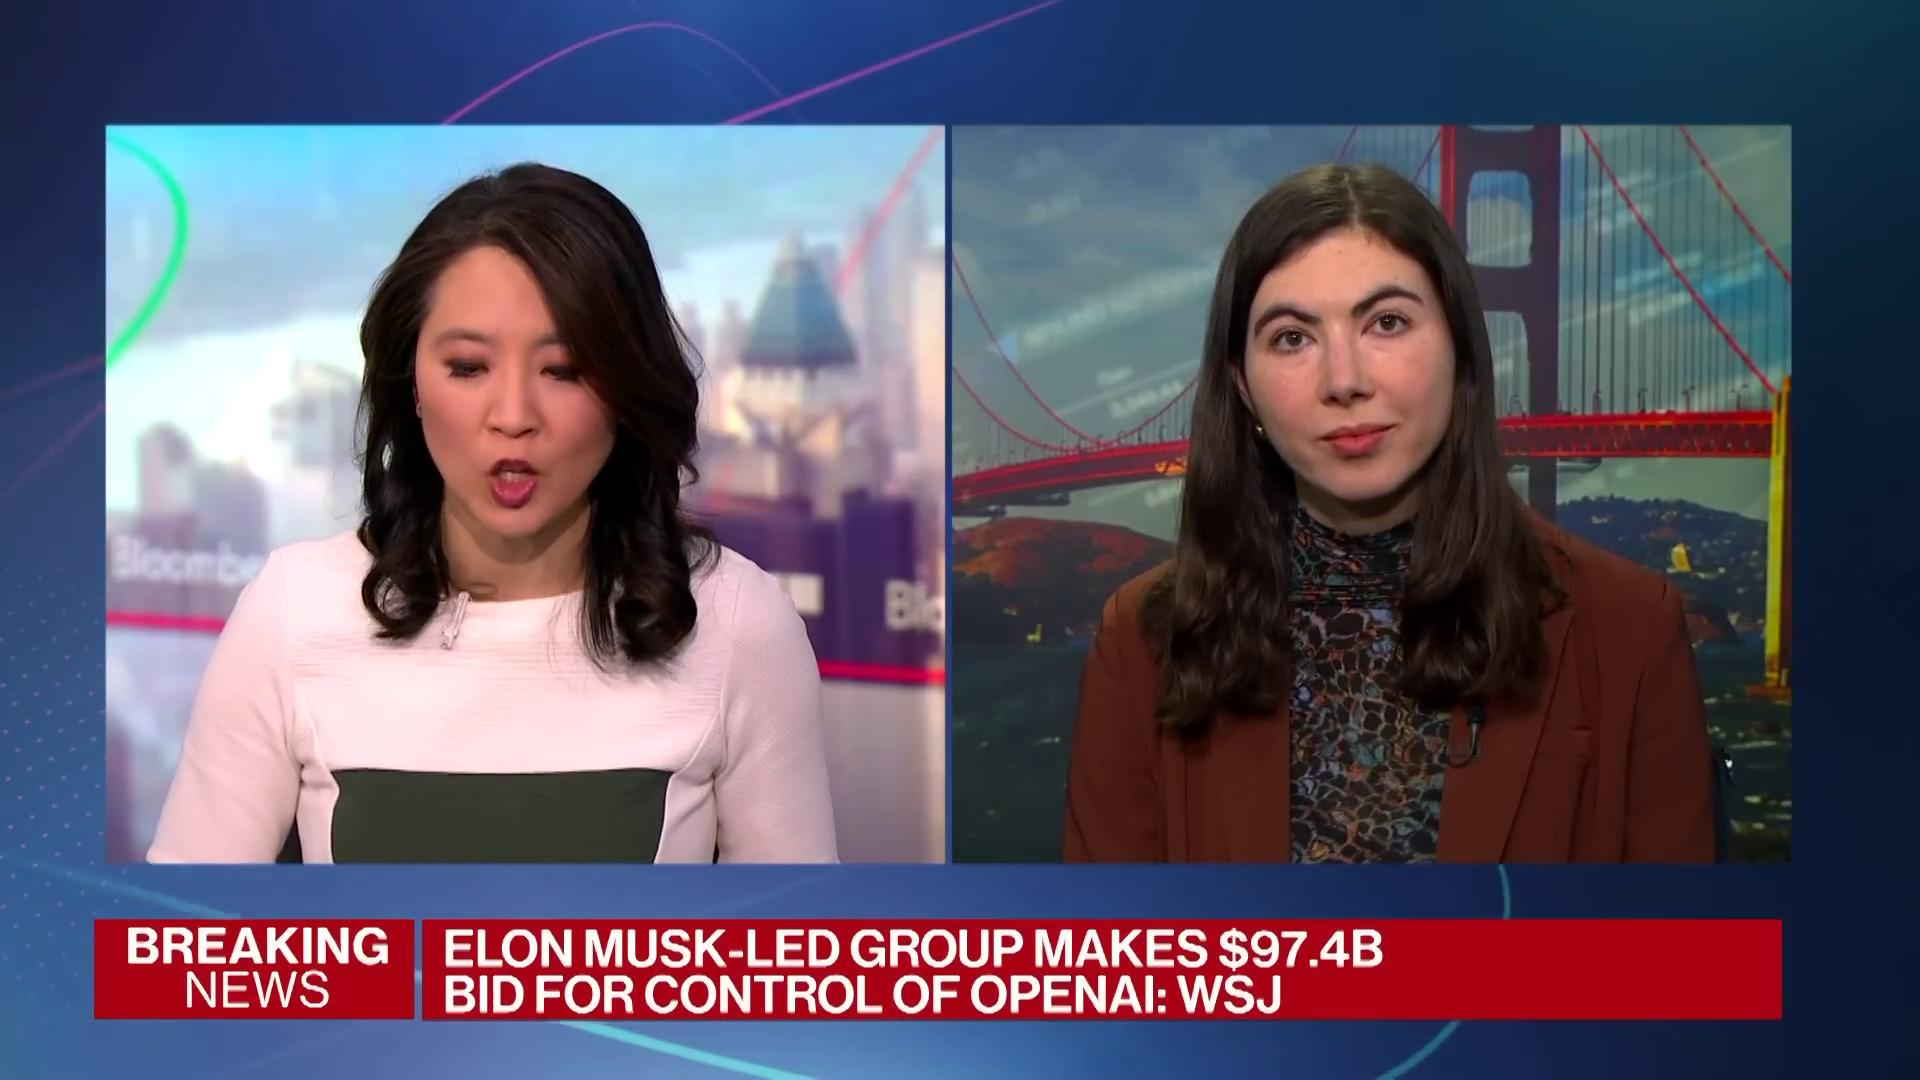

Progress: 2.2% | Frame: 2/45


Field,Content
Network,Bloomberg
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,None
Description,"The image shows a split-screen TV news broadcast featuring two women. The woman on the left has dark hair, is wearing a white and dark green top, and appears to be in a studio setting with a blurred background that includes the Bloomberg logo. The woman on the right has dark hair, is wearing a patterned top under a brown jacket, and is speaking. Her background shows a blurred image of the Golden Gate Bridge and city skyline. A red news ticker at the bottom displays breaking news."

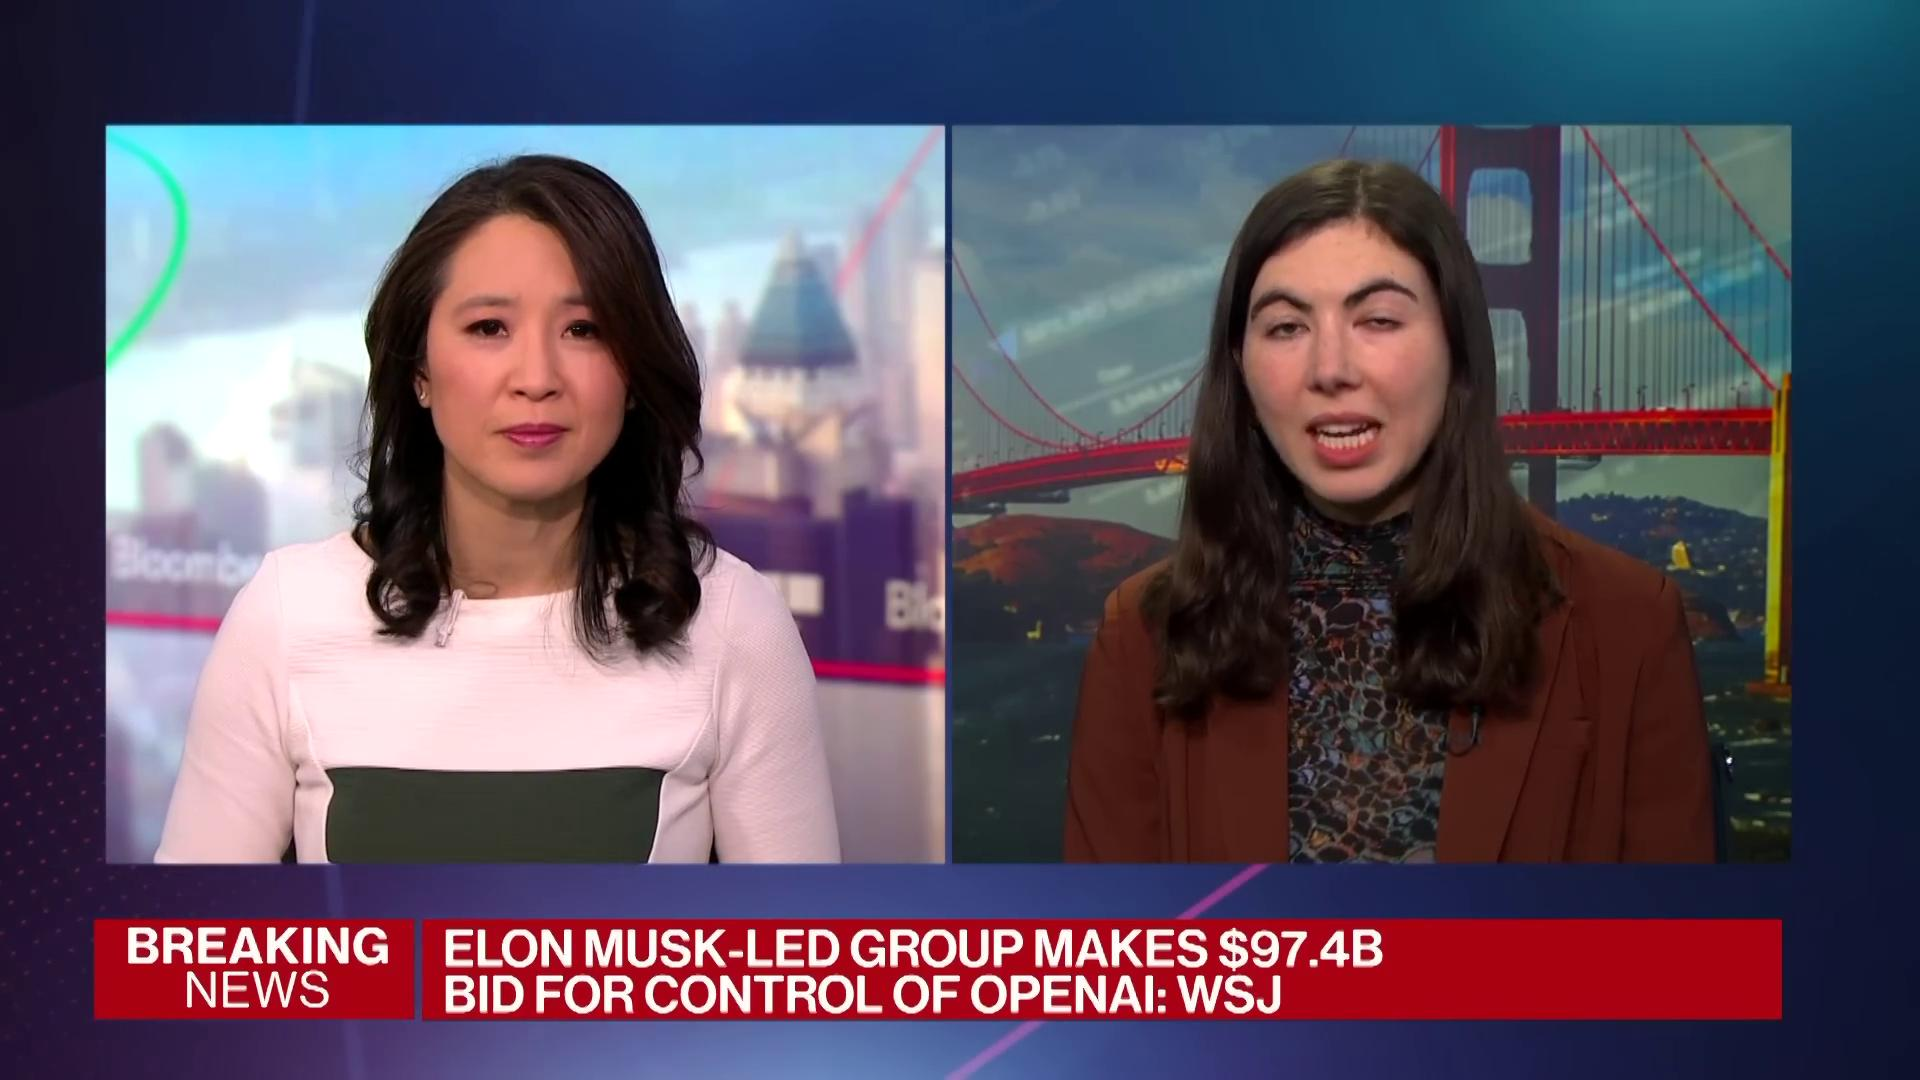

Progress: 4.4% | Frame: 3/45


Field,Content
Network,None
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,None
Description,"A female reporter with dark hair is speaking, wearing a patterned top and a brown jacket. Behind her is a graphical backdrop featuring the Golden Gate Bridge, with faint financial data and charts overlaid on the image. A blue, possibly abstract, design element is visible in the top left corner."

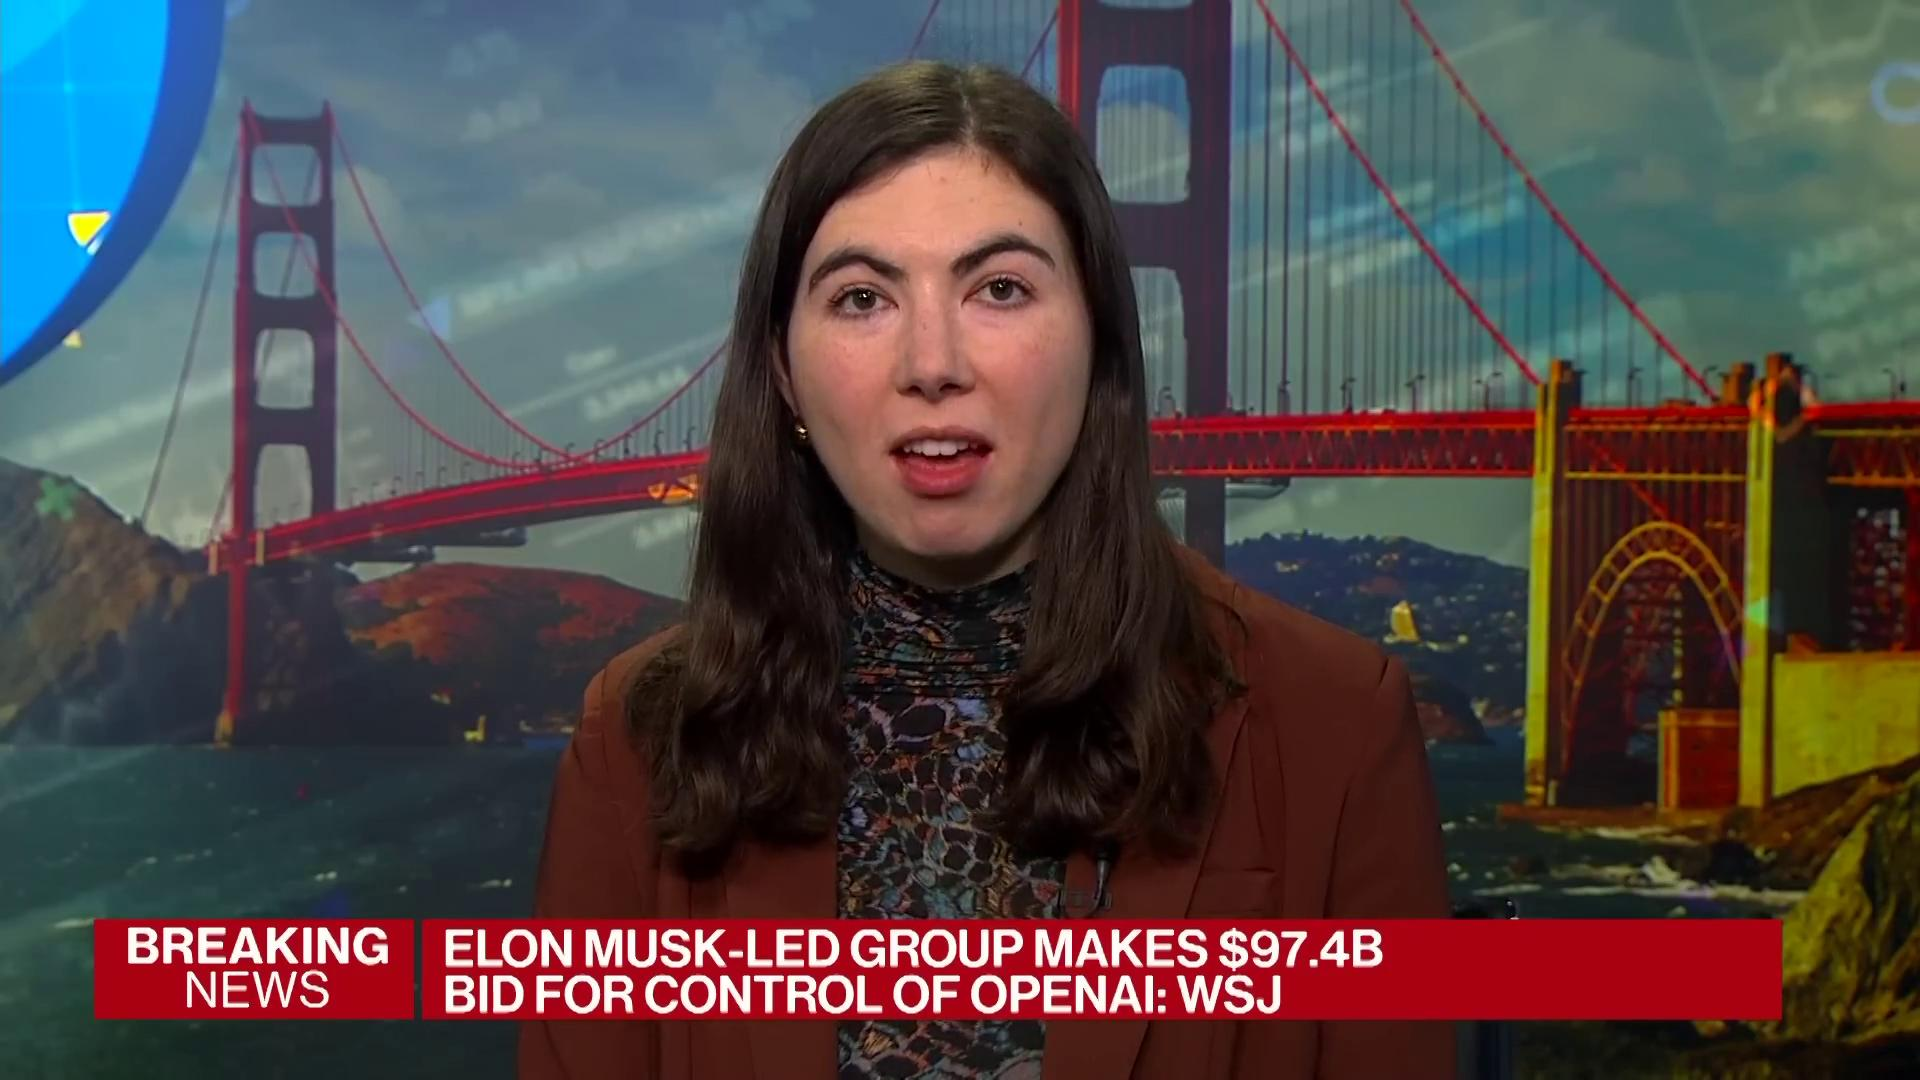

Progress: 6.6% | Frame: 4/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,Sarah Frier
Description,"A female reporter, Sarah Frier, is speaking on what appears to be a news broadcast. The background features a graphical representation of the Golden Gate Bridge and some abstract financial data elements. A 'LIVE' indicator is visible in the top left corner."

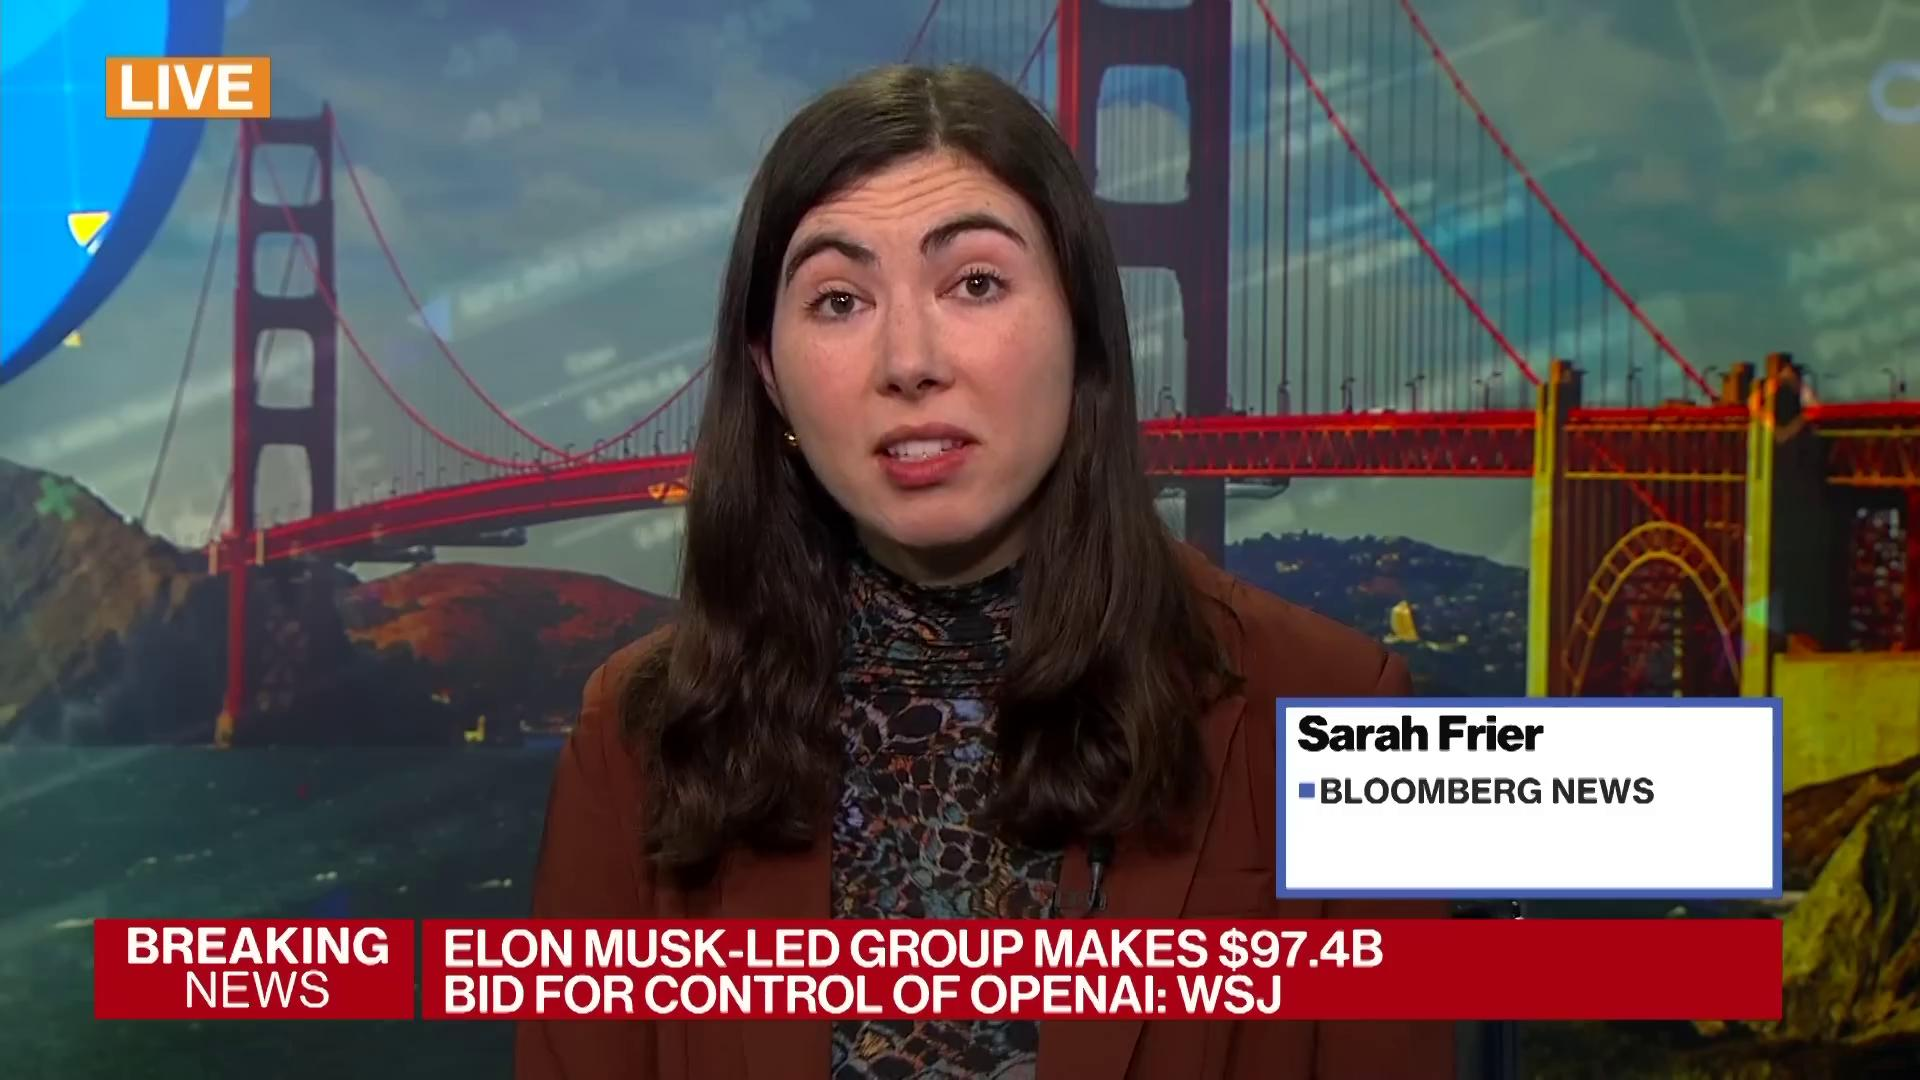

Progress: 8.8% | Frame: 5/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS
Reporters,Sarah Frier
Description,A female reporter is speaking in front of a background featuring the Golden Gate Bridge with financial data overlays. The broadcast is live and displaying a 'Breaking News' alert.

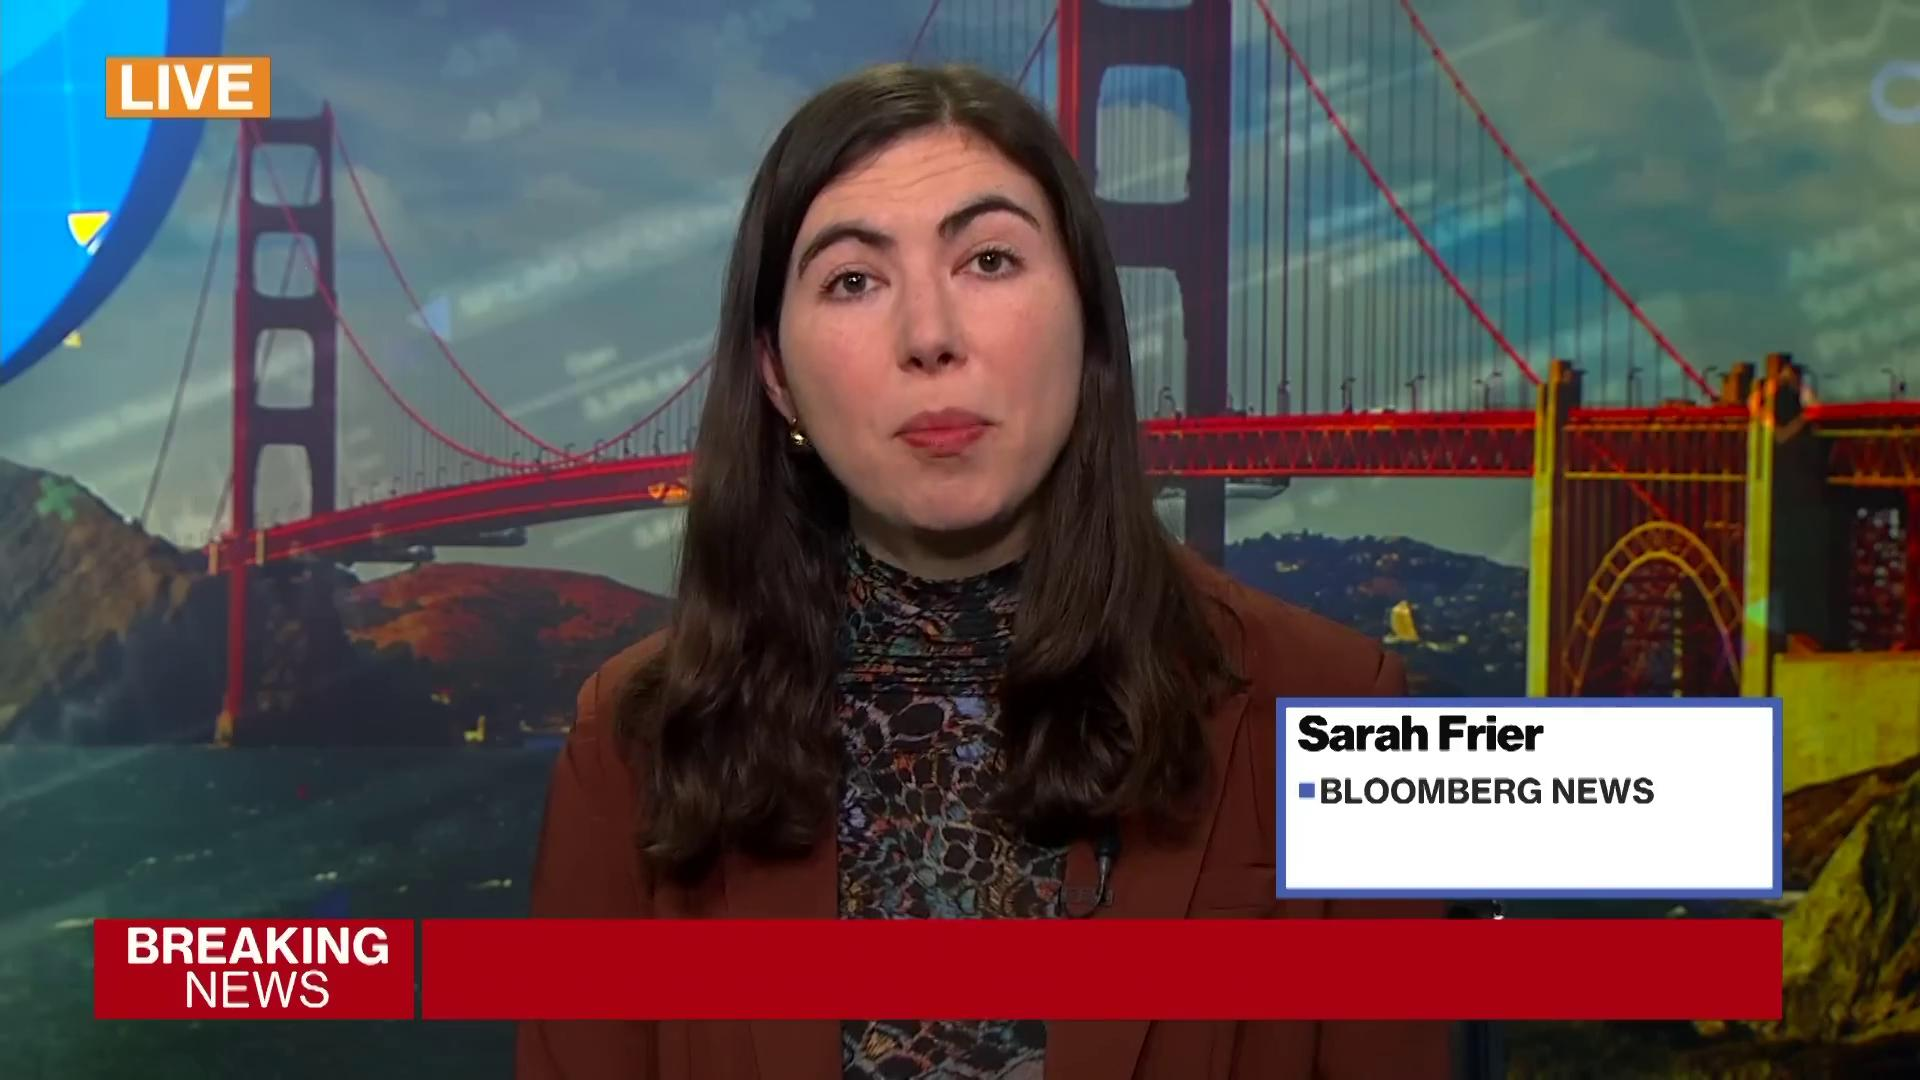

Progress: 11.1% | Frame: 6/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A woman with long dark hair is speaking, facing forward, with her eyes closed, against a background featuring the Golden Gate Bridge. There's an overlay of financial data graphs in the background. A ""LIVE"" indicator is in the top left corner."

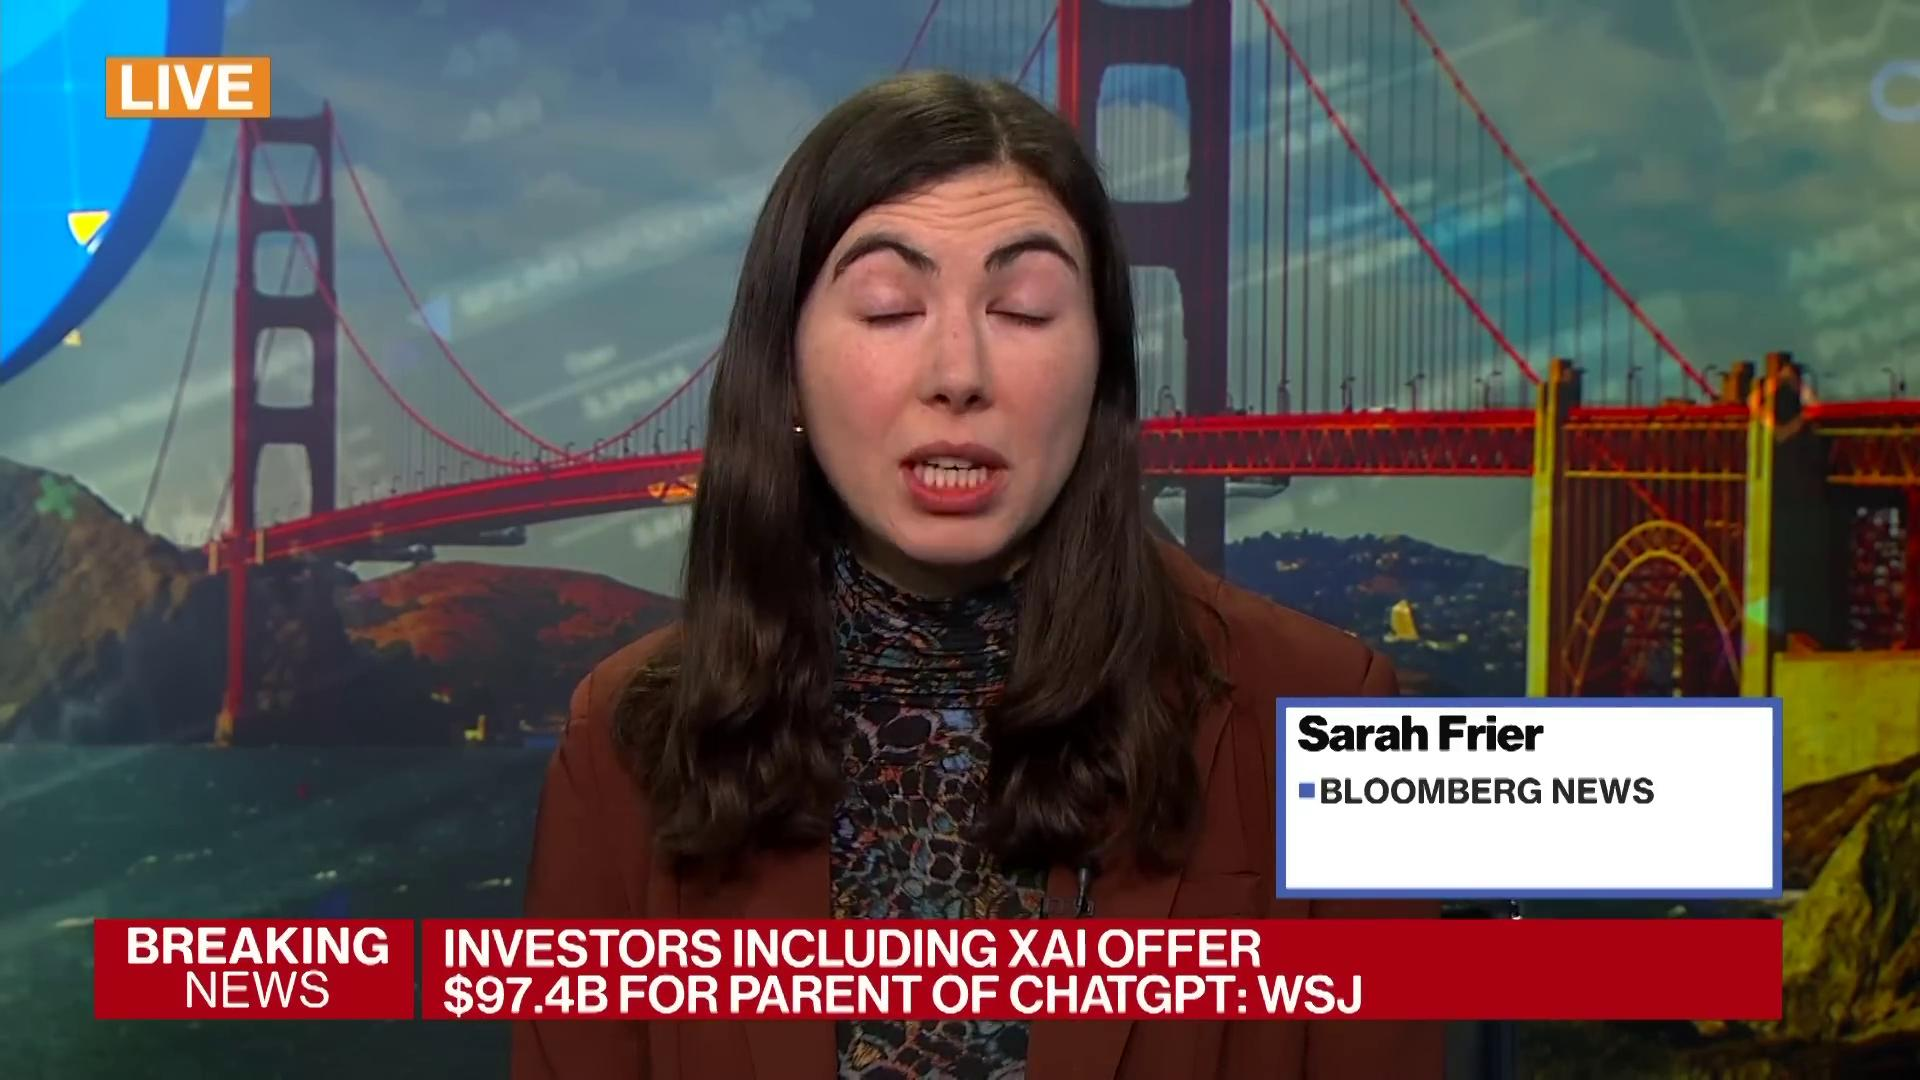

Progress: 13.3% | Frame: 7/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS: INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A woman, identified as Sarah Frier, is reporting live. She is wearing a brown jacket over a patterned top. Behind her is a graphic showing the Golden Gate Bridge, indicating a possible San Francisco or tech-related news context, with some financial data overlays. A 'LIVE' indicator is in the top left corner."

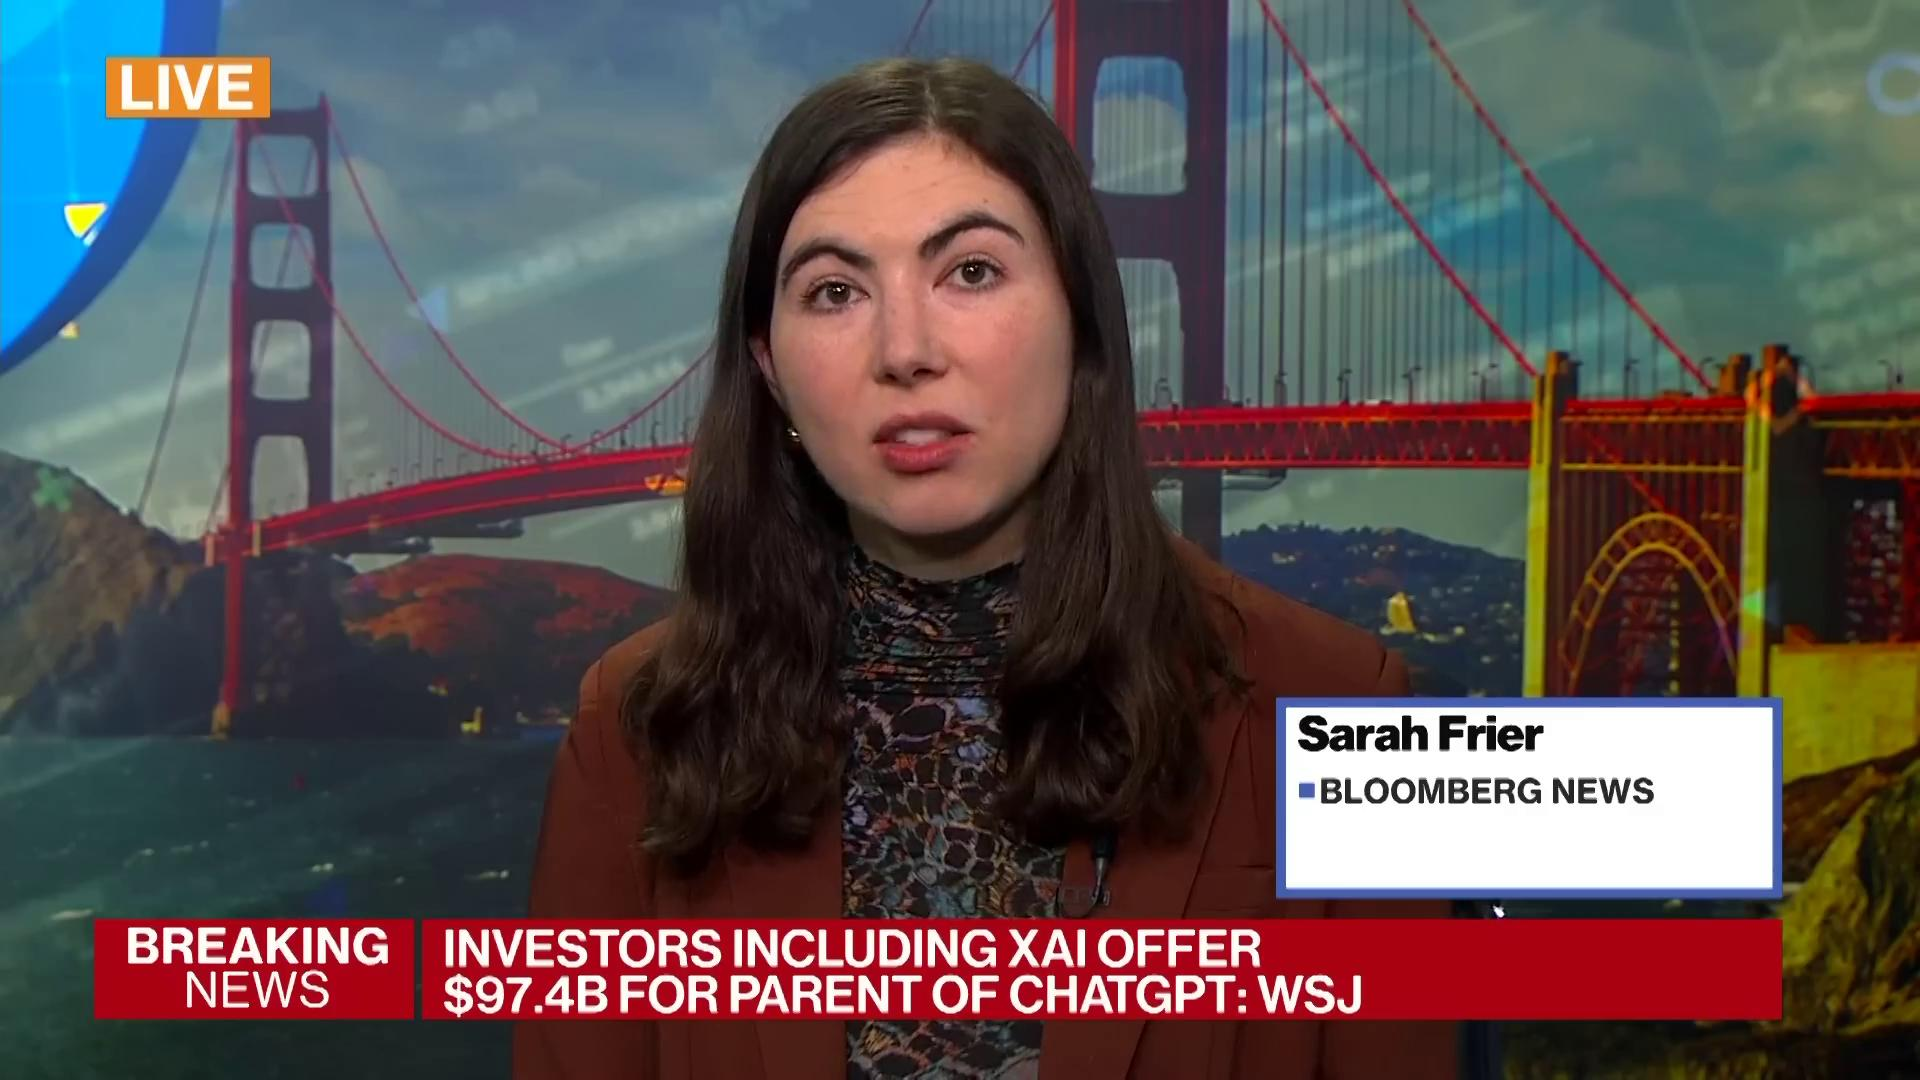

Progress: 15.5% | Frame: 8/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A woman with long dark hair and a brown jacket over a patterned top is speaking, with a graphic of the Golden Gate Bridge in the background. A 'LIVE' indicator is in the top left corner."

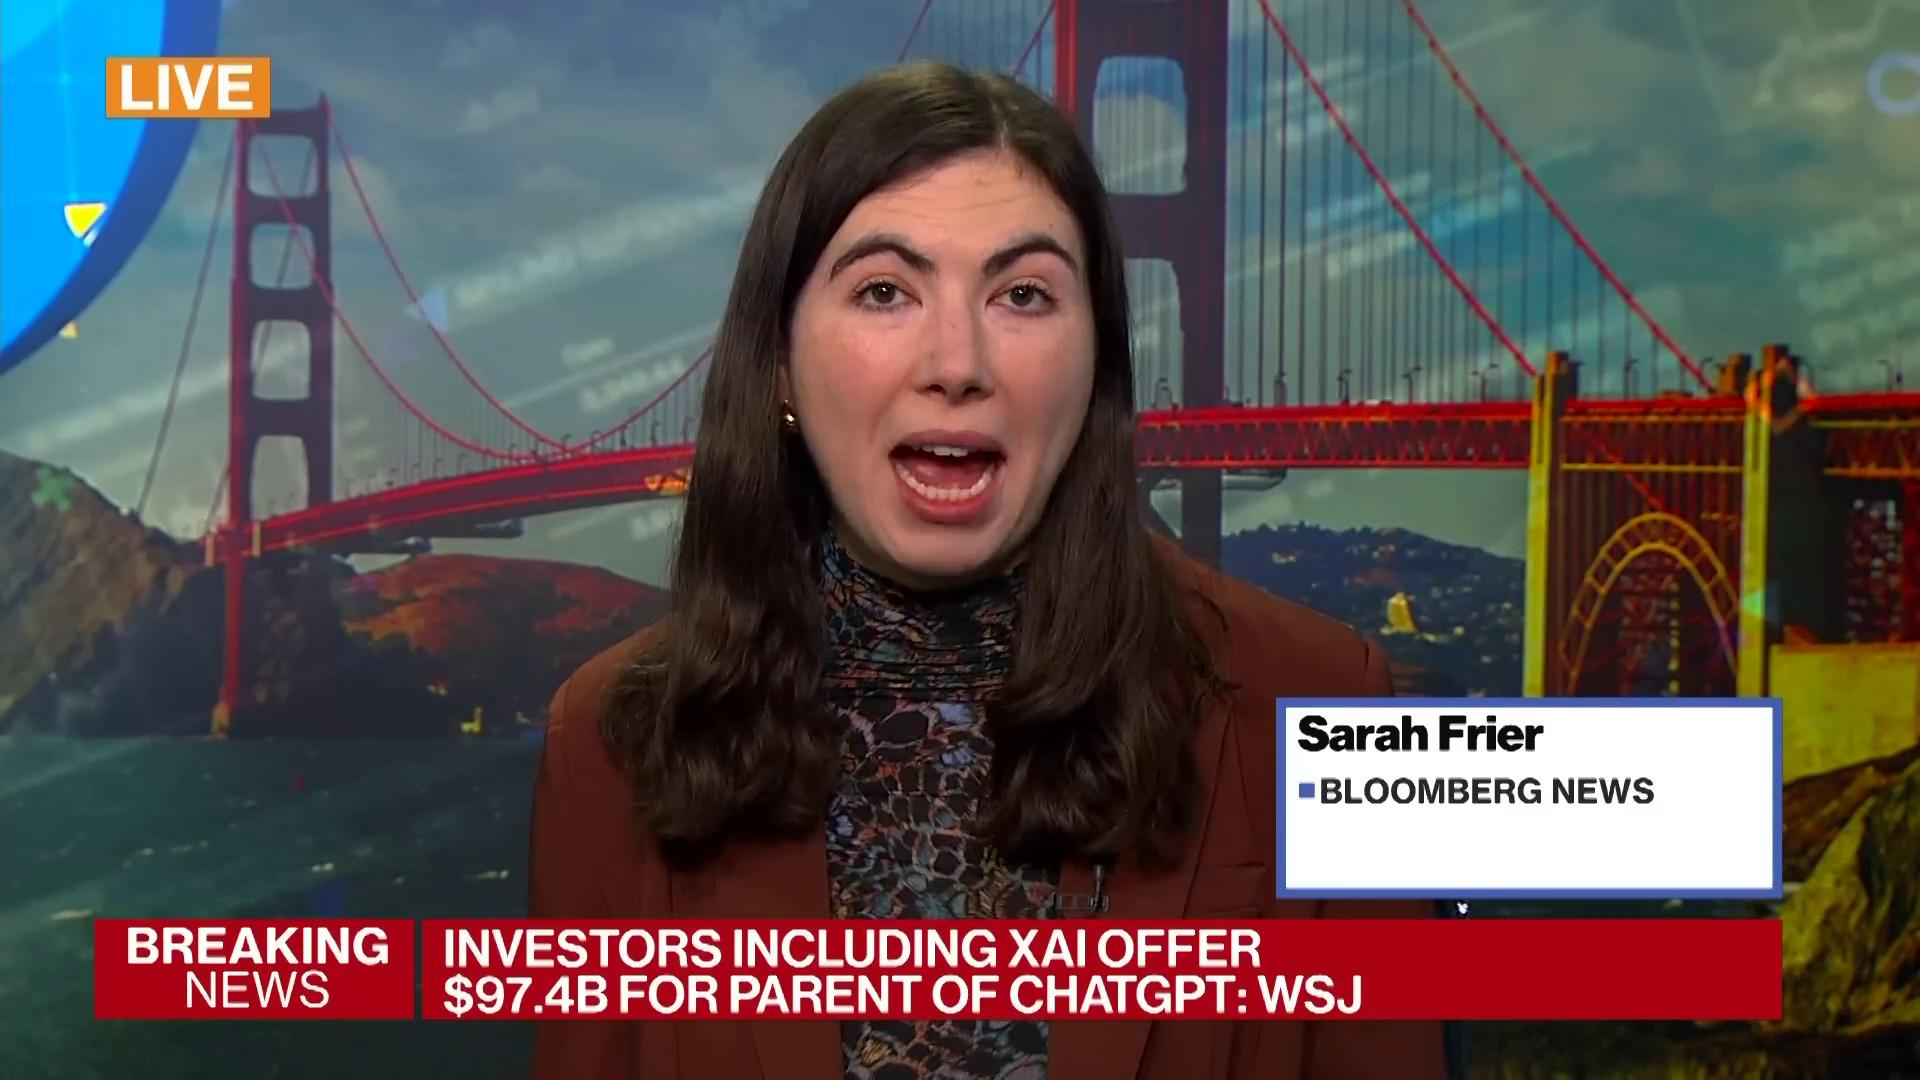

Progress: 17.7% | Frame: 9/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS: INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A female reporter is speaking on a news broadcast. Behind her is a graphic depicting the Golden Gate Bridge, overlaid with financial data. A 'LIVE' indicator is visible in the top left corner."

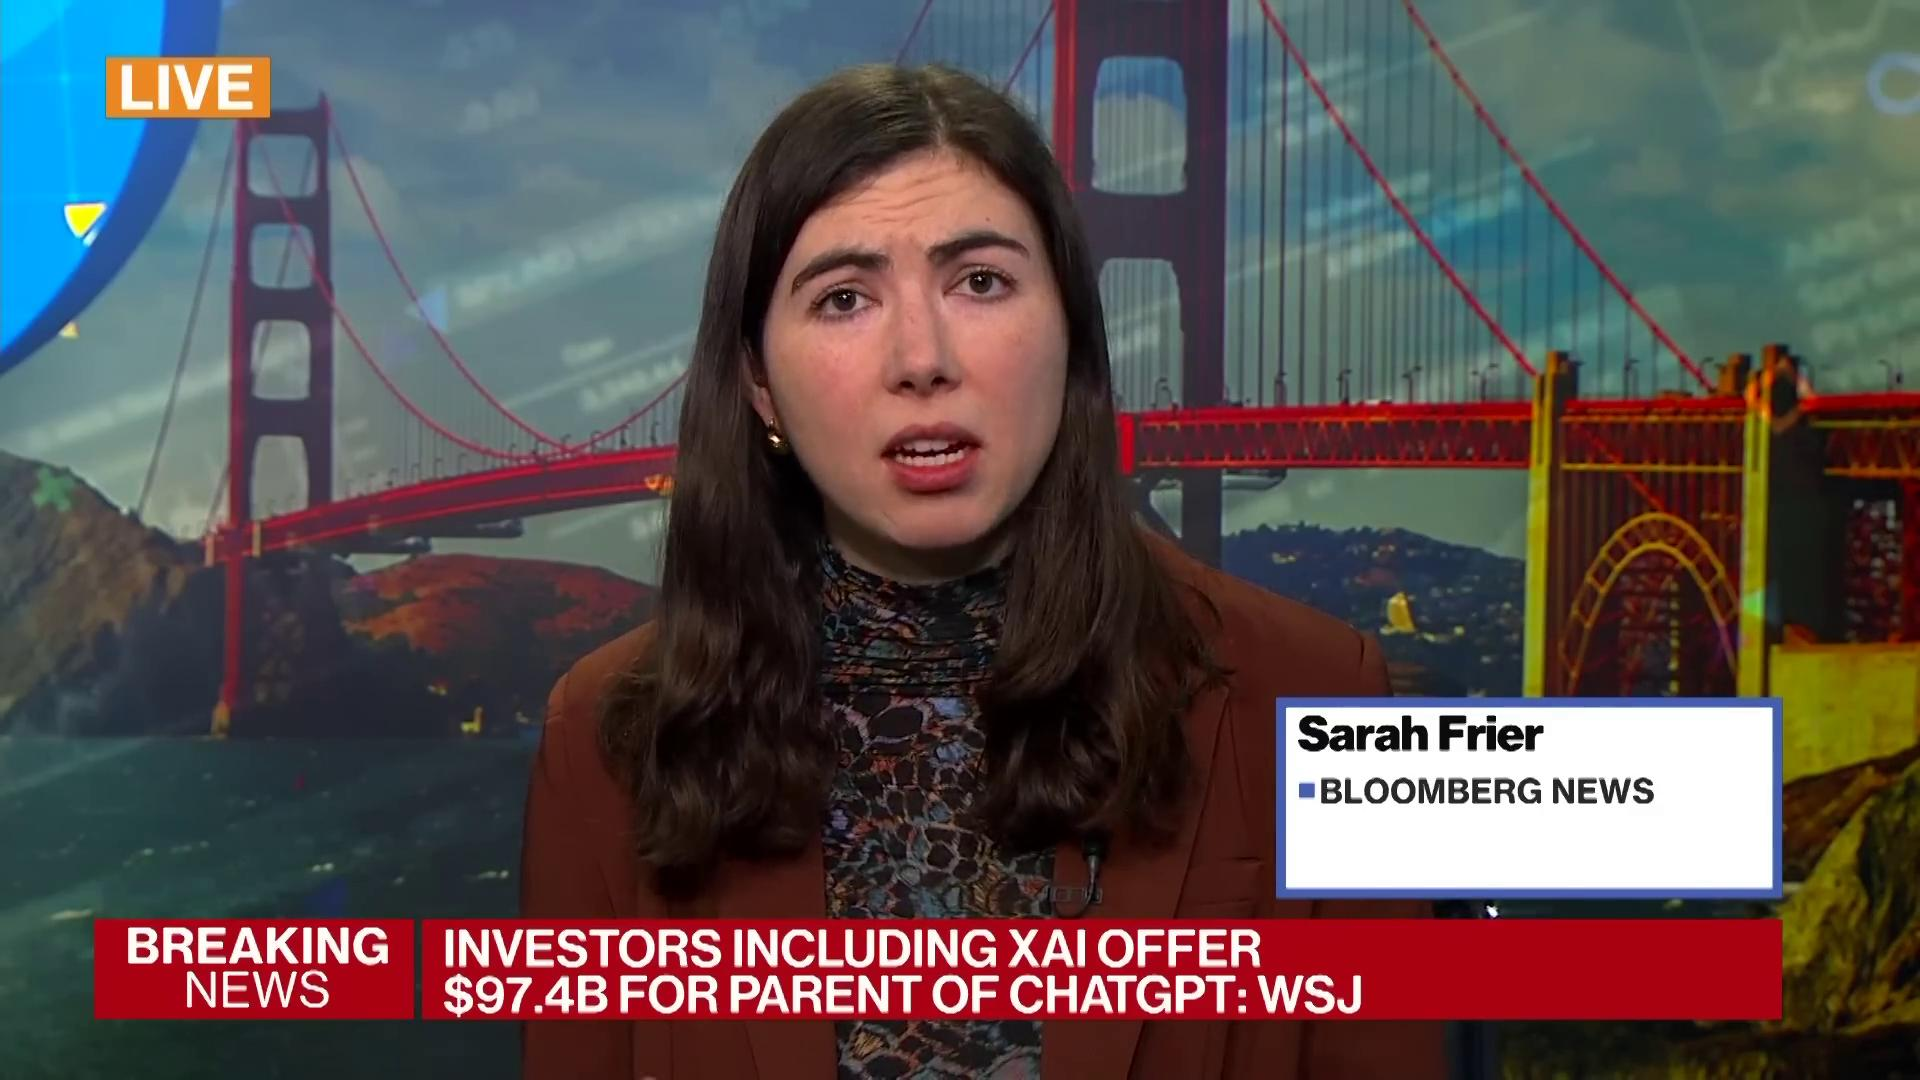

Progress: 19.9% | Frame: 10/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,Sarah Frier
Description,"A live news broadcast featuring a woman, identified as Sarah Frier, speaking against a backdrop of the Golden Gate Bridge. The screen includes a 'LIVE' indicator and a news ticker at the bottom."

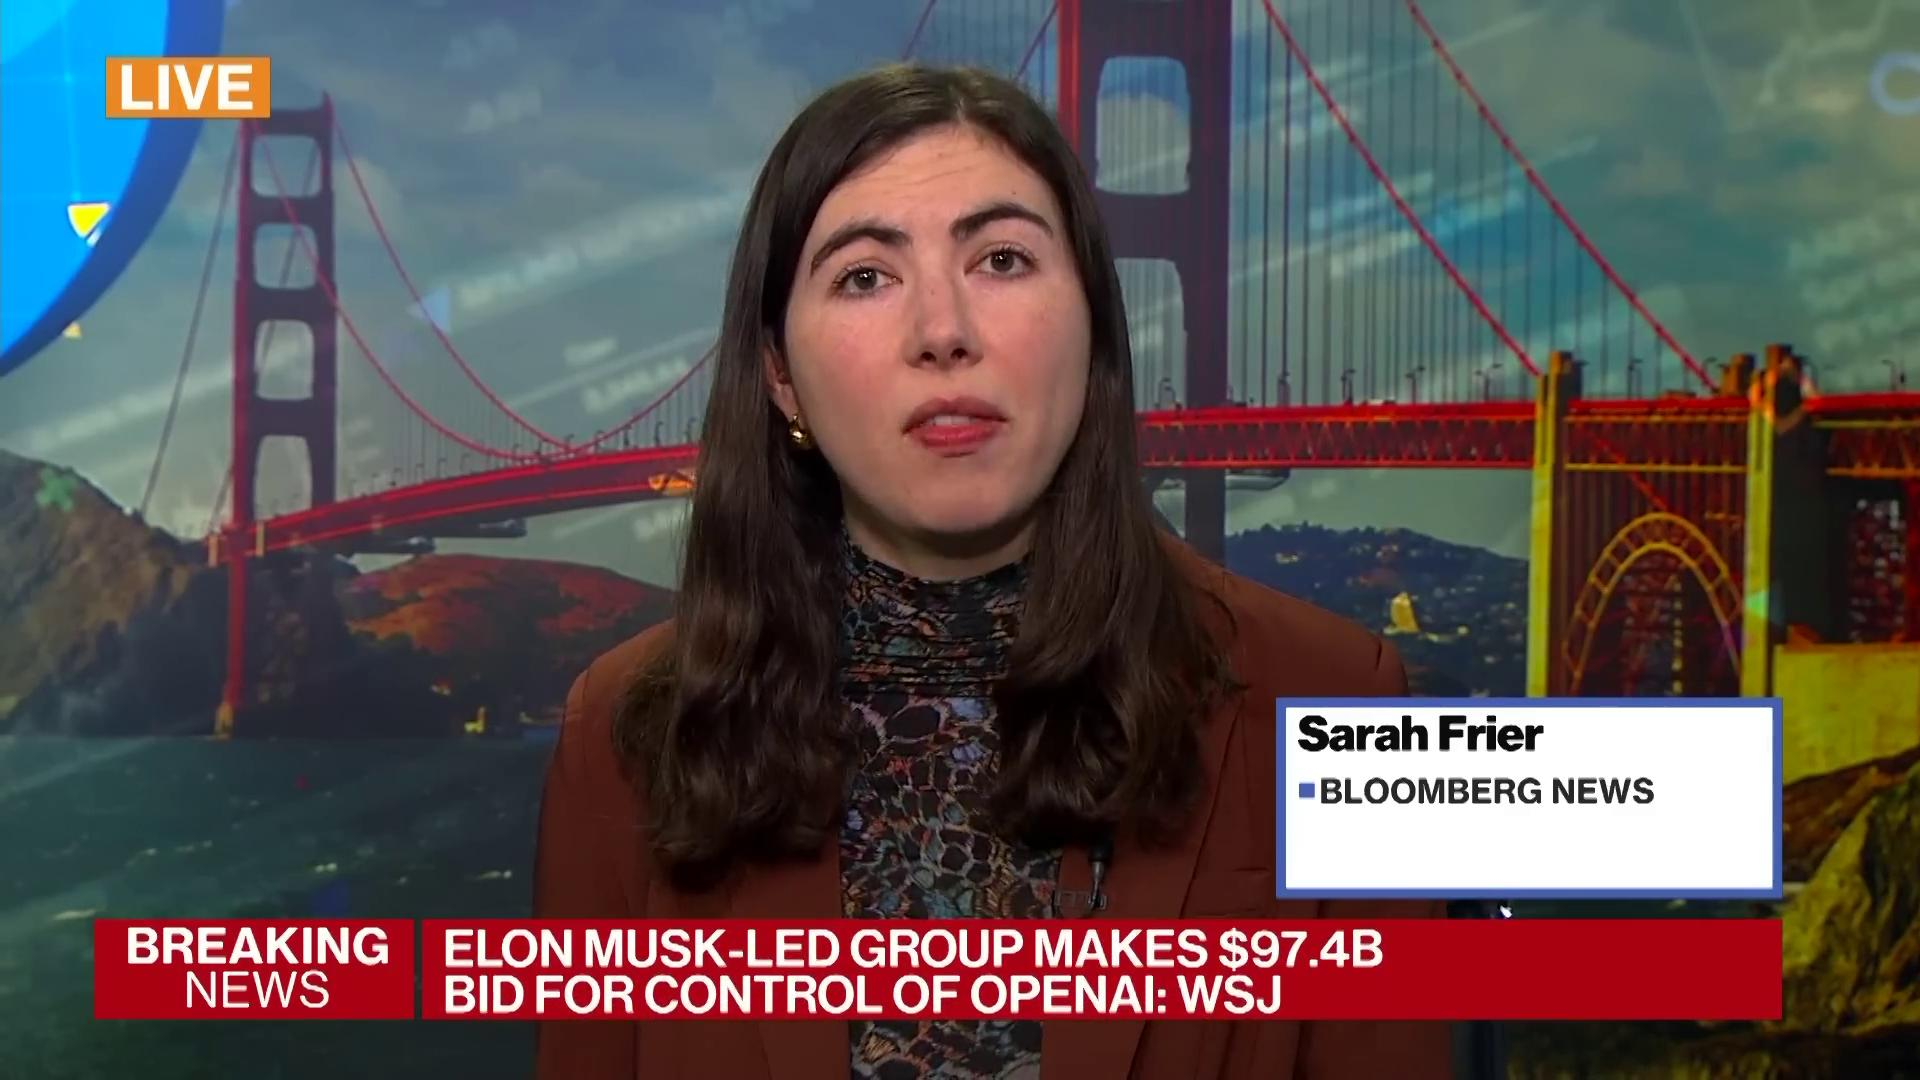

Progress: 22.1% | Frame: 11/45


Field,Content
Network,None
Chyron,BREAKING NEWS | ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,None
Description,"A split screen image showing Elon Musk on the left and Sam Altman on the right. Both men are looking to the right. Elon Musk is seen from the side, wearing a dark suit and white shirt, with a serious expression. Sam Altman is also seen from the side, wearing a suit and white shirt, with his mouth slightly open as if speaking. A red banner at the bottom displays breaking news text."

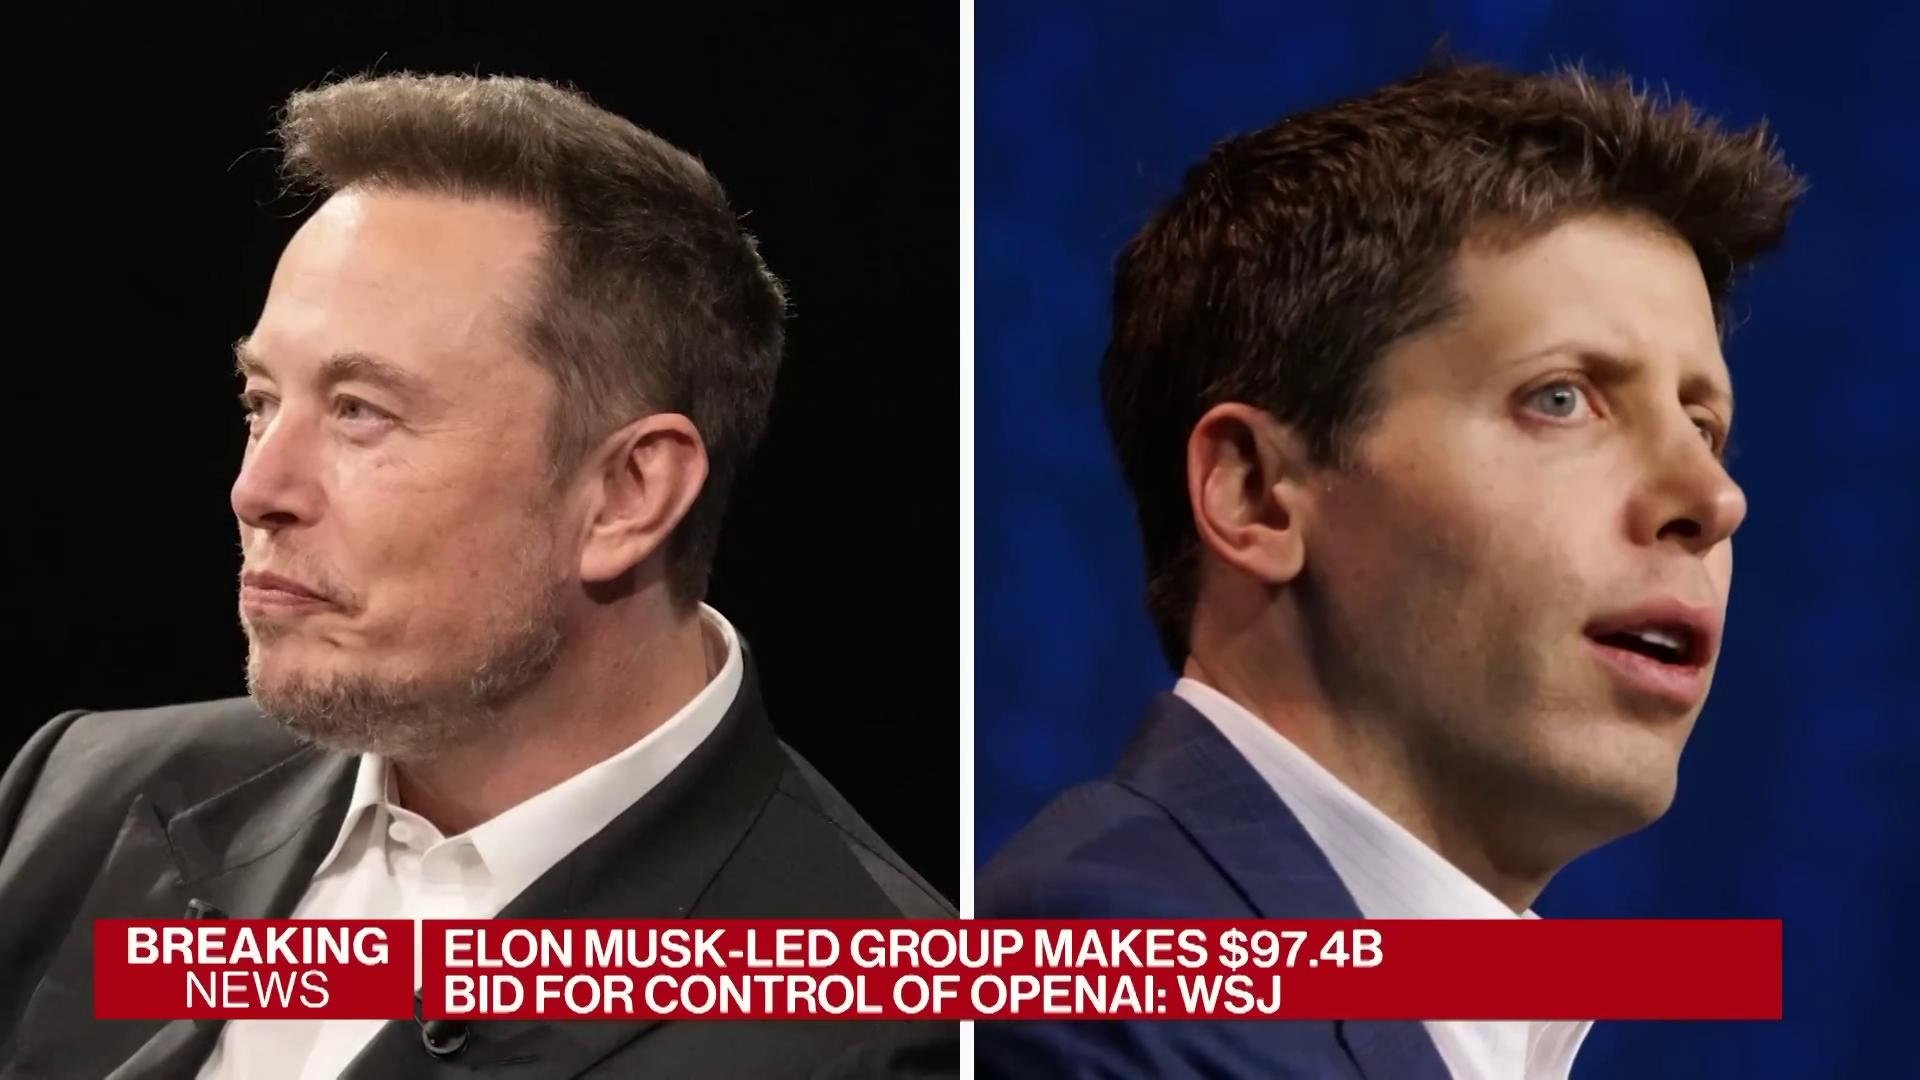

Progress: 24.3% | Frame: 12/45


Field,Content
Network,None
Chyron,BREAKING NEWS | ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,None
Description,"A split-screen view featuring Elon Musk speaking into a microphone on the left, and another man sitting on a couch on the right. Musk is wearing a dark suit and white shirt, with a blurred background showing text like ""CULT"". The man on the right is wearing a dark blue sweater, sitting against a brick wall with a plant in the background."

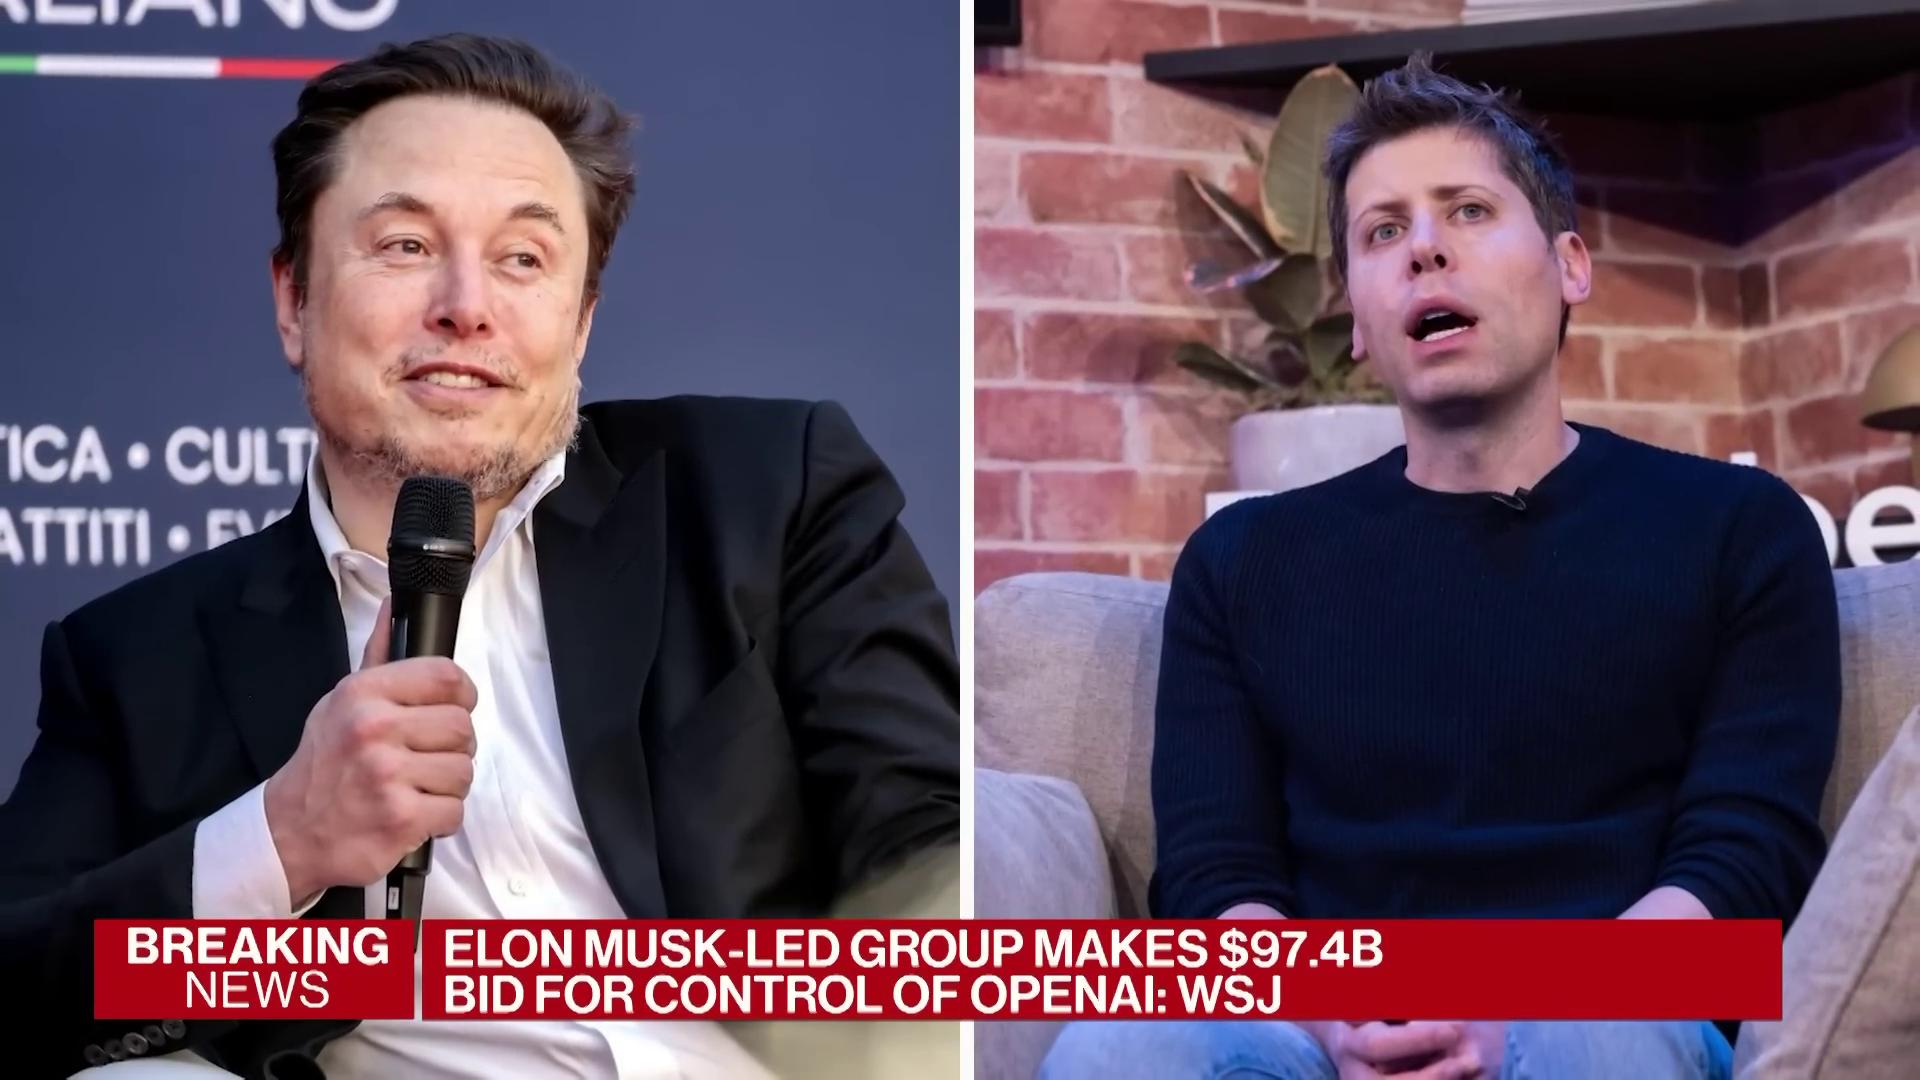

Progress: 26.5% | Frame: 13/45


Field,Content
Network,None
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,None
Description,"Two men are shown in a split screen. On the left is Elon Musk, looking slightly upwards and to the right. On the right is Sam Altman, gesturing with his right hand. Both appear to be engaged in a discussion or presentation."

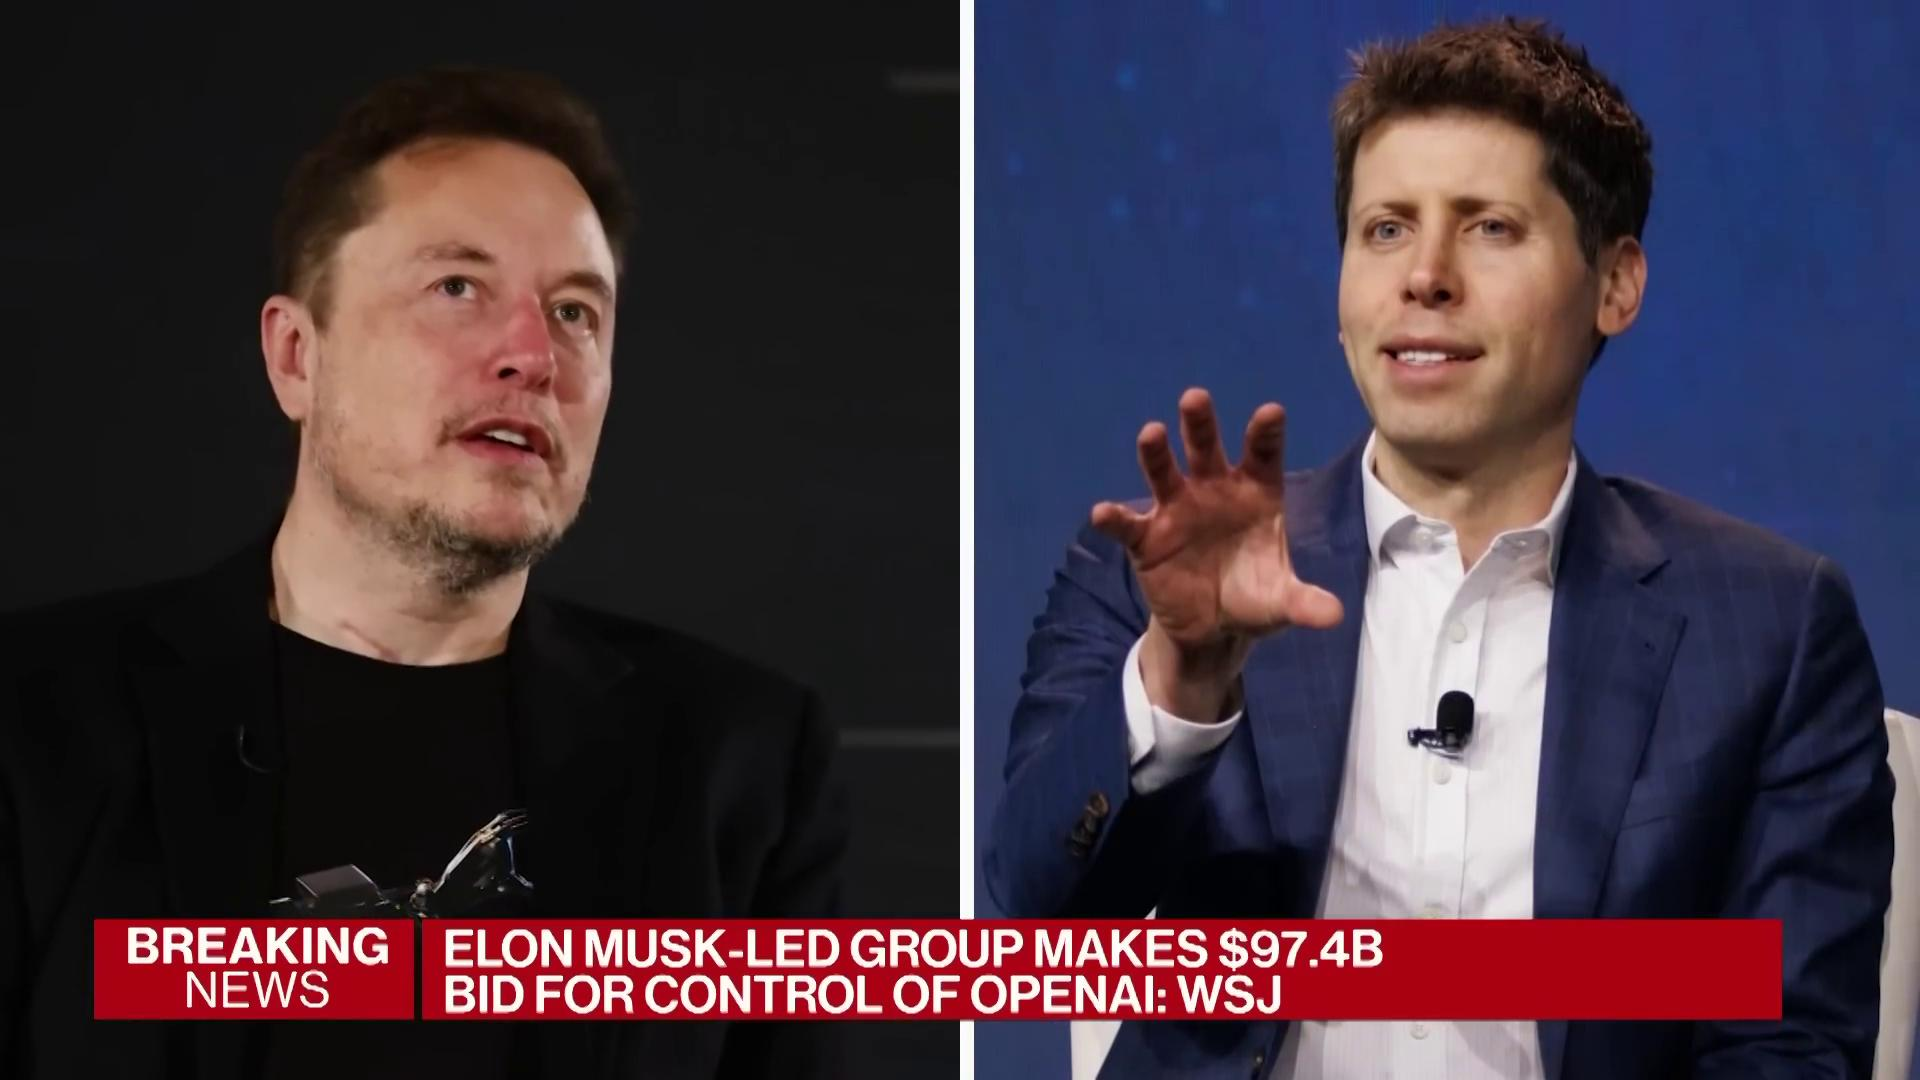

Progress: 28.7% | Frame: 14/45


Field,Content
Network,WSJ
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,None
Description,"A split screen showing two men. On the left is Elon Musk, looking serious or contemplative. On the right is a different man, smiling faintly, with a brick wall in the background. A red 'BREAKING NEWS' banner is visible at the bottom of the screen."

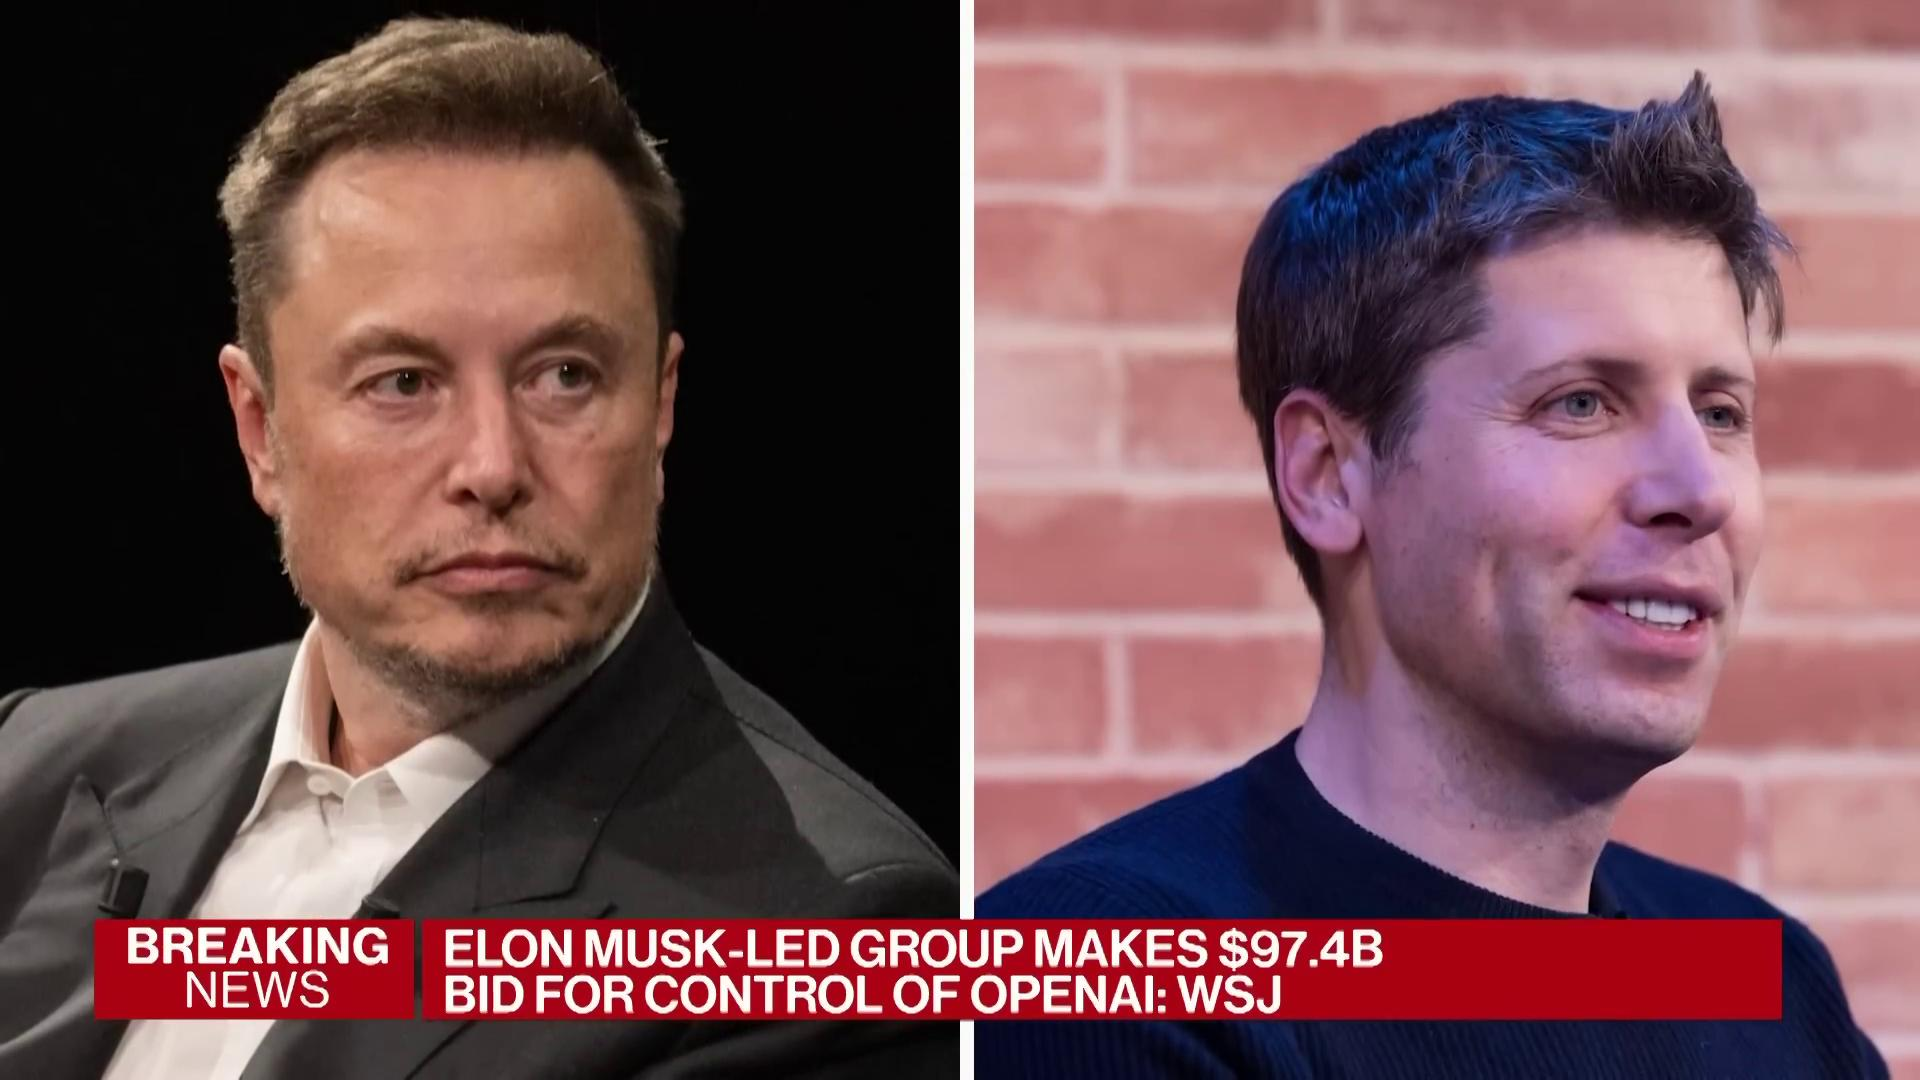

Progress: 30.9% | Frame: 15/45


Field,Content
Network,None
Chyron,BREAKING NEWS | ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,None
Description,"A split screen showing two men; the man on the left is Elon Musk, and the man on the right is Sam Altman, likely in a news context. A red chyron is displayed at the bottom of the screen."

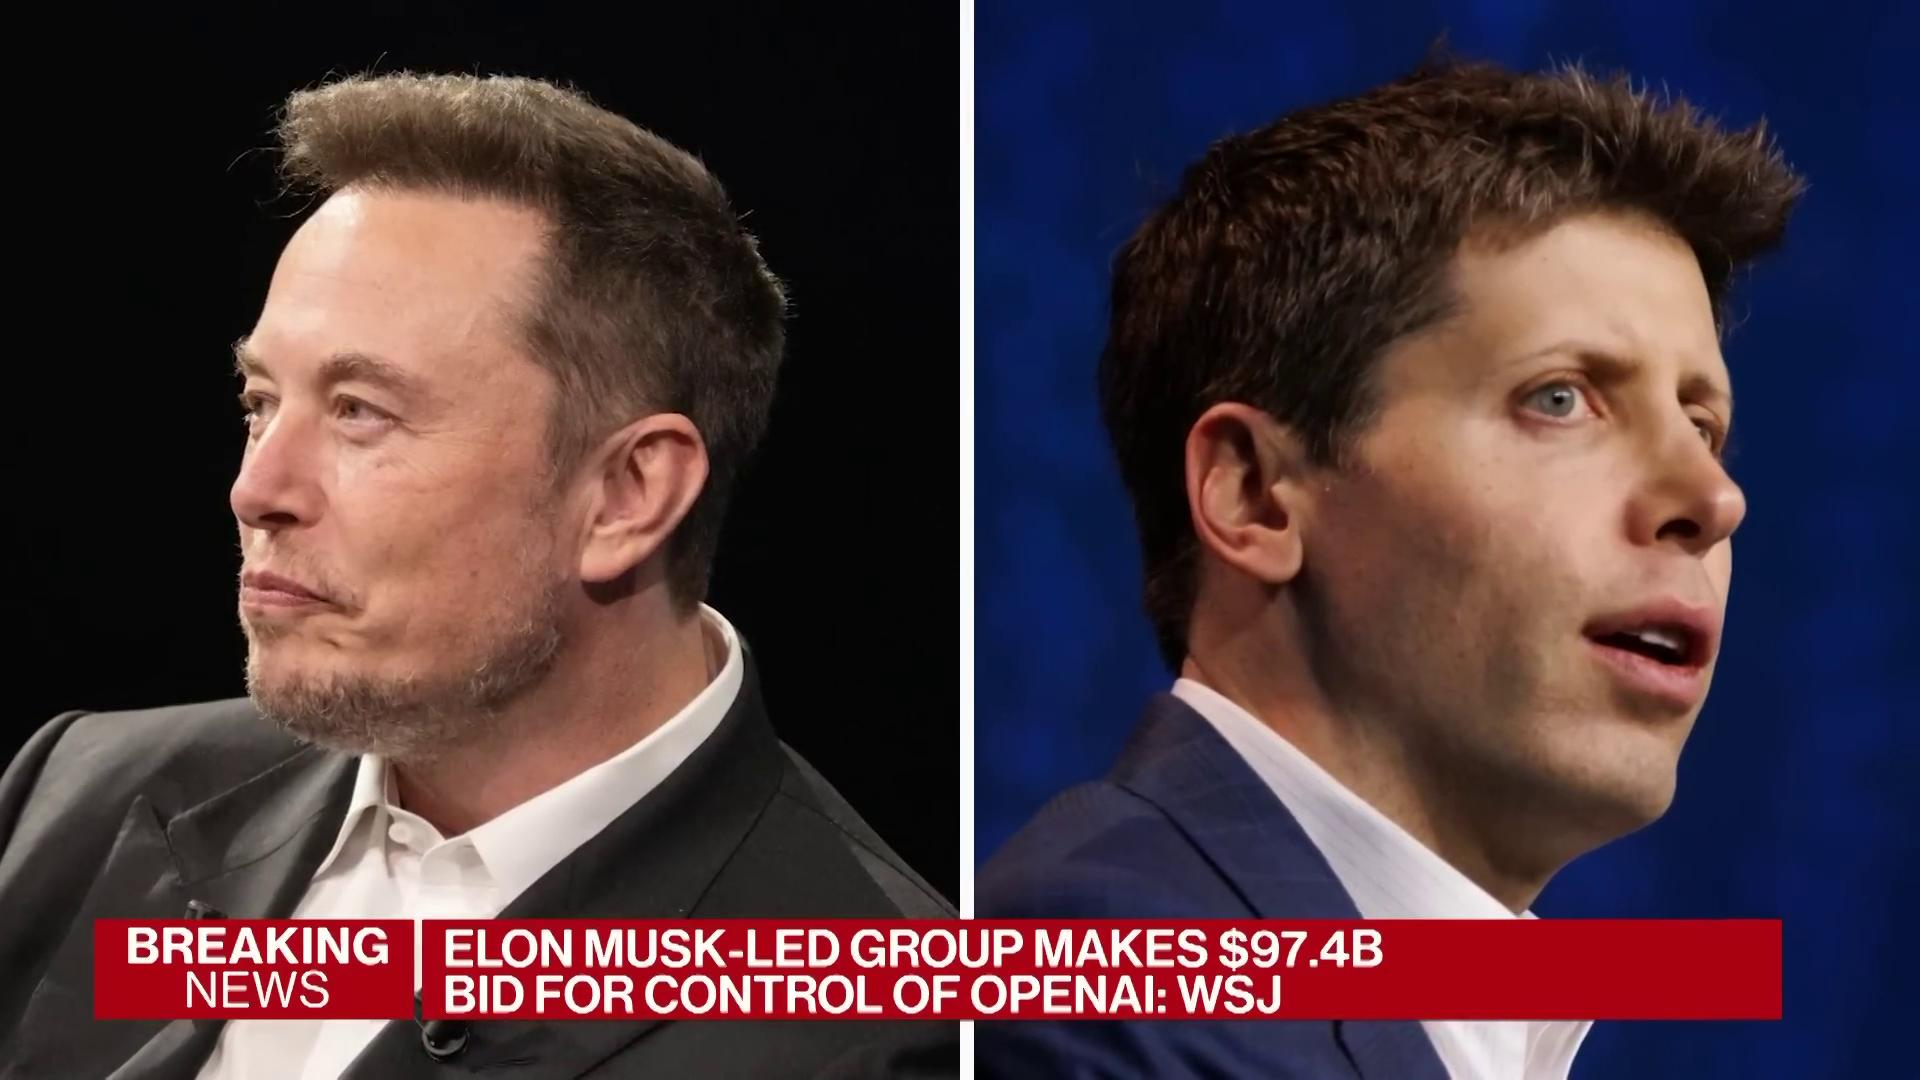

Progress: 33.2% | Frame: 16/45


Field,Content
Network,Bloomberg
Chyron,BREAKING NEWS INVESTORS INCLUDING ΧΑΙ OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"A split-screen view showing two women. The woman on the left, wearing glasses, is speaking. The woman on the right is smiling, with the Golden Gate Bridge visible in the background. A 'BREAKING NEWS' banner is displayed at the bottom of the screen."

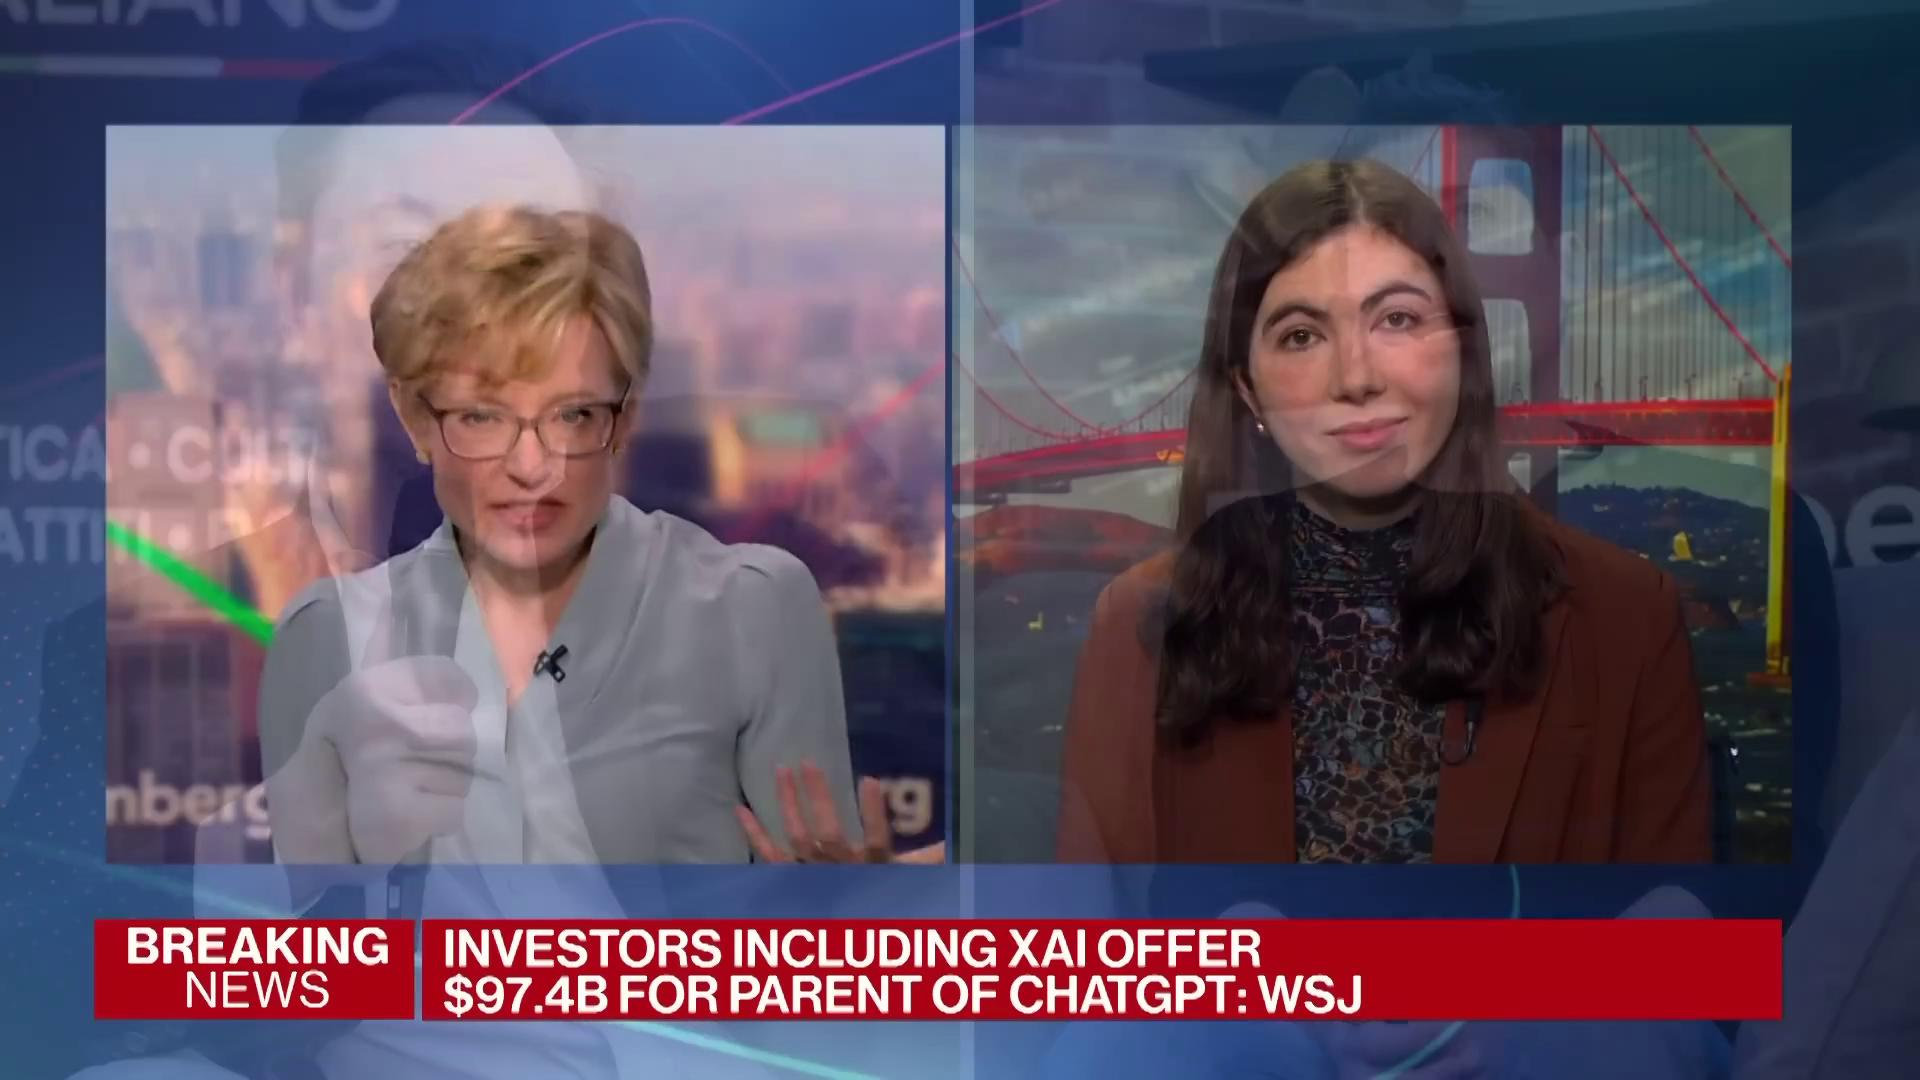

Progress: 35.4% | Frame: 17/45


Field,Content
Network,Bloomberg
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"A split-screen TV news broadcast featuring two women. The woman on the left has short blonde hair and glasses, wearing a light blue top. The woman on the right has long dark hair and is wearing a patterned top with a brown blazer. The background behind the left woman shows blurry city lights and a partial 'Bloomberg' logo. The background behind the right woman features the Golden Gate Bridge with digital overlays."

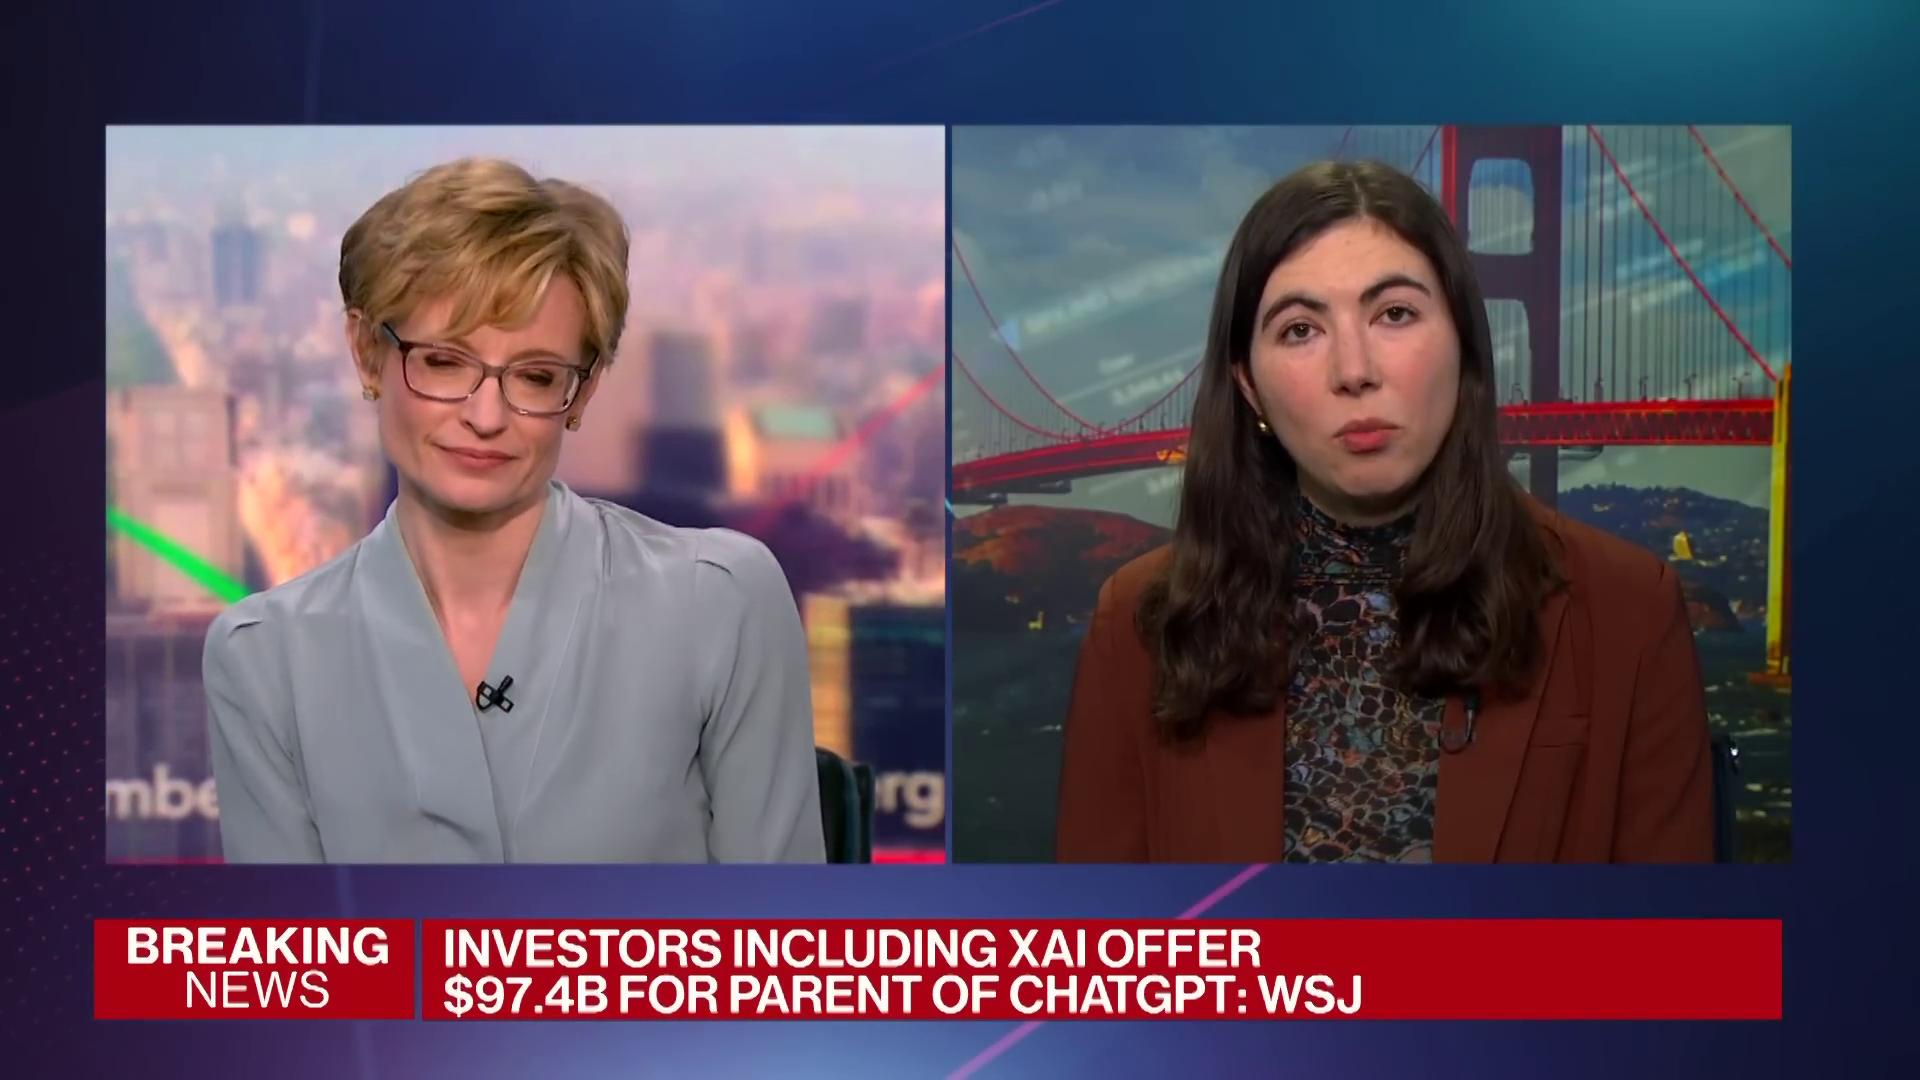

Progress: 37.6% | Frame: 18/45


Field,Content
Network,None
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"A female reporter with long dark hair is speaking, wearing a brown jacket and a patterned top. Behind her is a backdrop featuring the Golden Gate Bridge over water, with faint numerical data overlaid on the bridge image. A red 'BREAKING NEWS' banner is at the bottom of the screen."

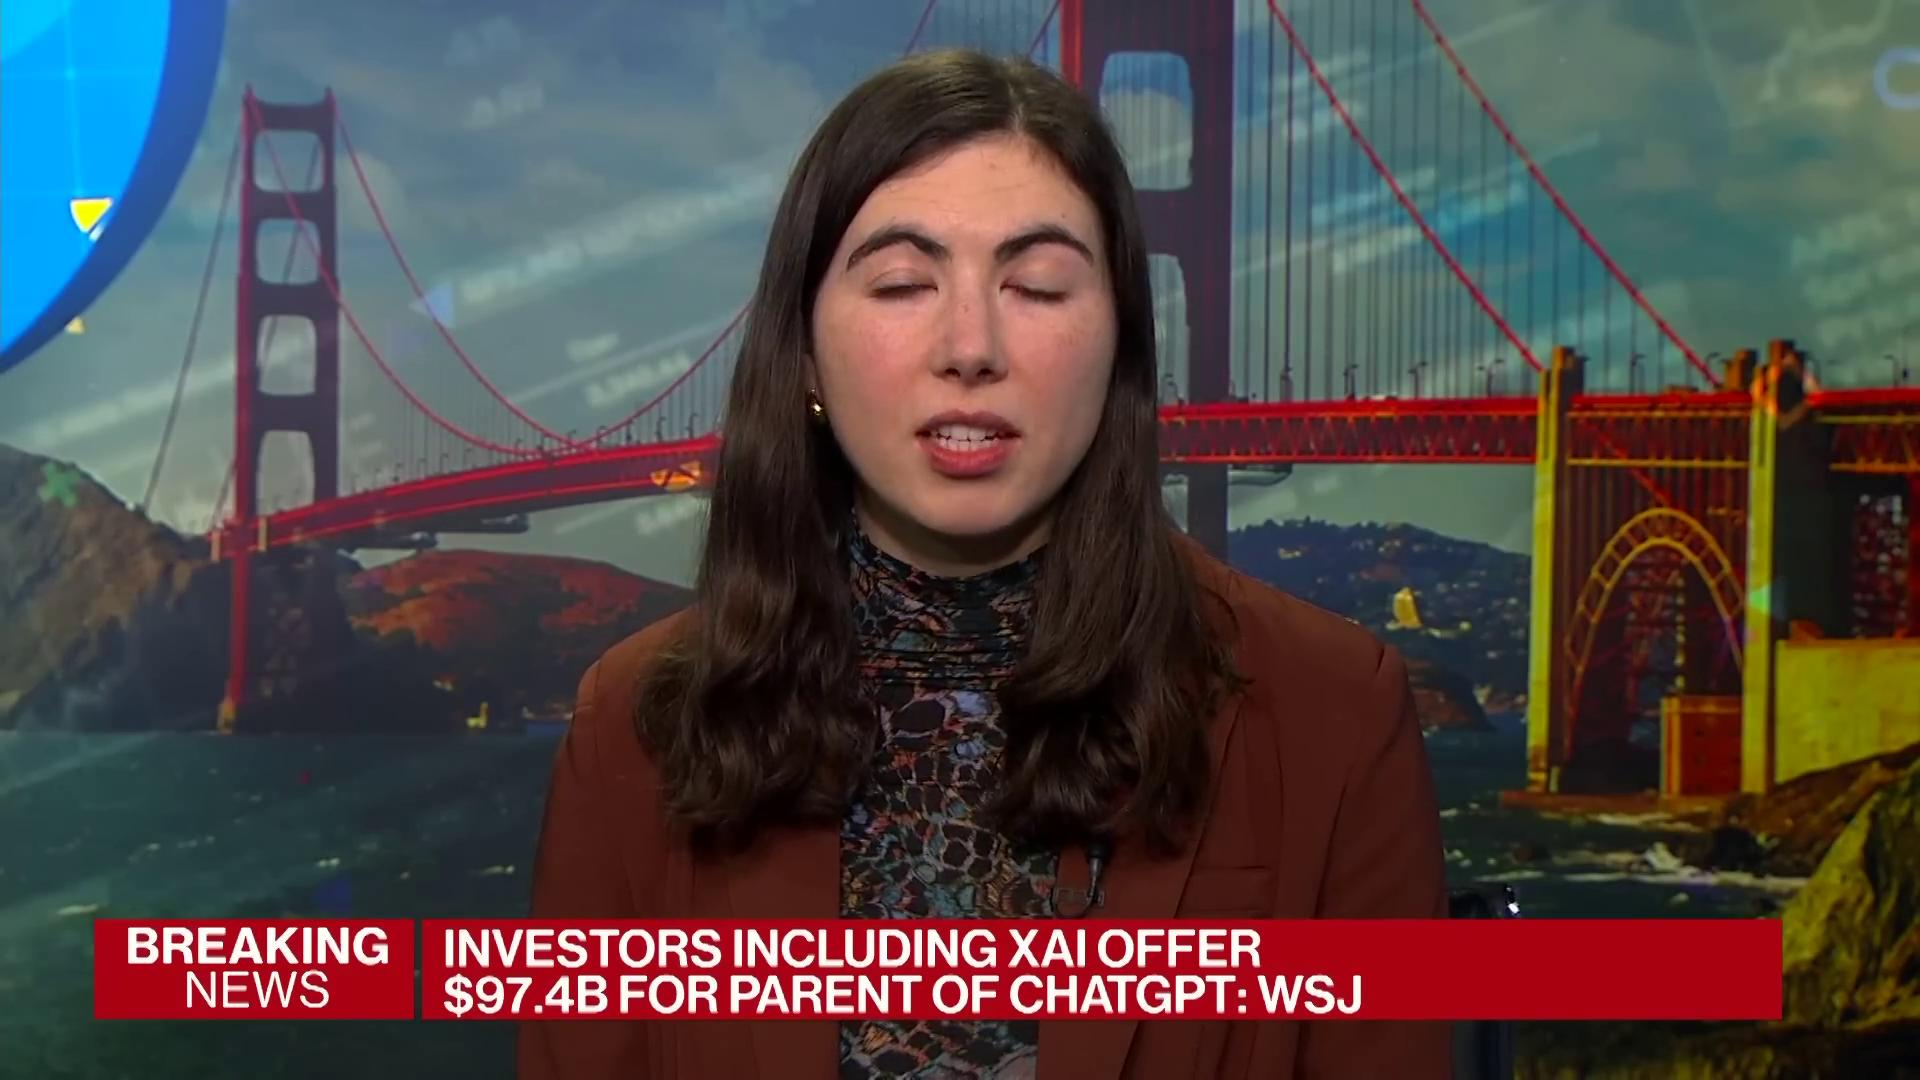

Progress: 39.8% | Frame: 19/45


Field,Content
Network,None
Chyron,BREAKING NEWS | INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"A female reporter or anchor is speaking in front of a digital backdrop featuring a blurred image of the Golden Gate Bridge, overlaid with abstract financial data and charts. There's a partial blue and yellow logo visible in the top left corner."

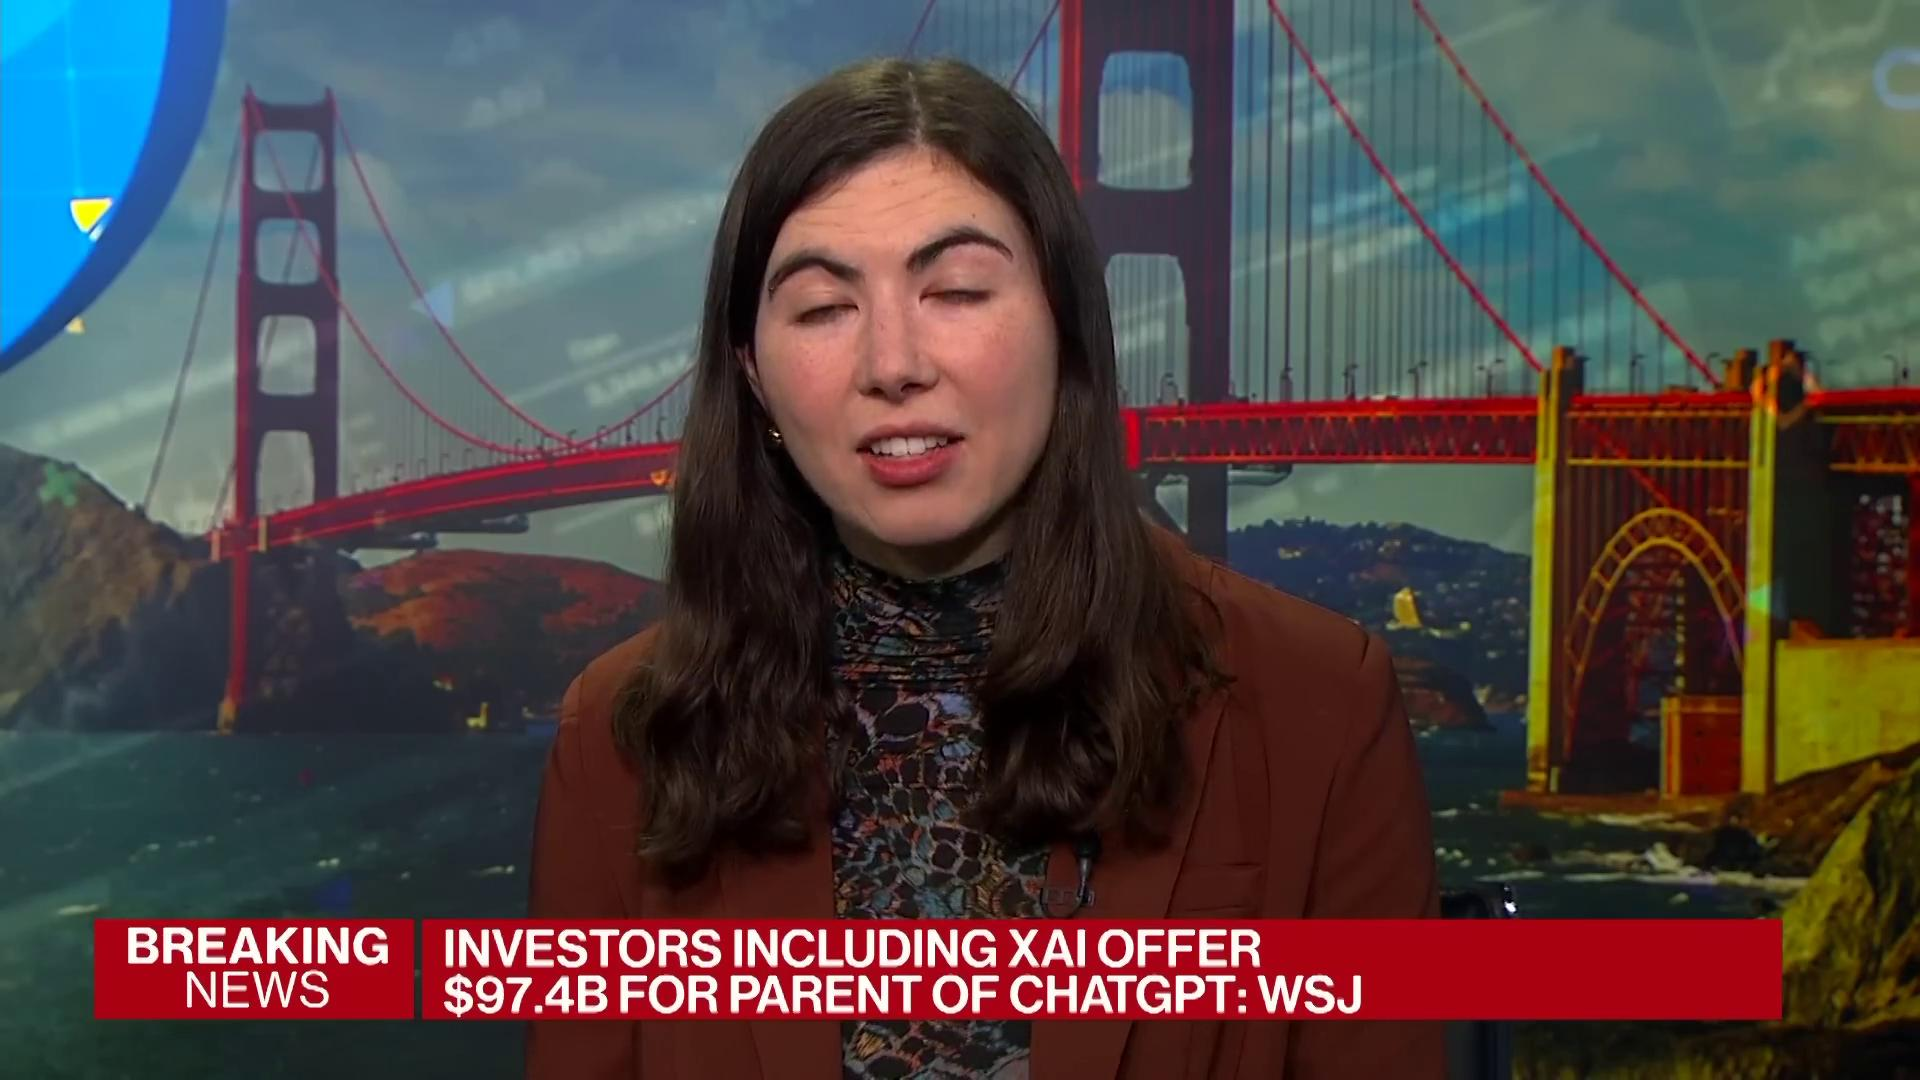

Progress: 42.0% | Frame: 20/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A female reporter, Sarah Frier, is shown from the chest up, speaking to the camera with a wide smile. She has long brown hair and is wearing a patterned top under a brown jacket. Behind her is a digital background depicting the Golden Gate Bridge, with some financial charts faintly visible. A ""LIVE"" graphic is in the top left corner, and a lower third graphic identifies the reporter as ""Sarah Frier"" from ""Bloomberg News"". A red breaking news ticker is at the bottom of the screen."

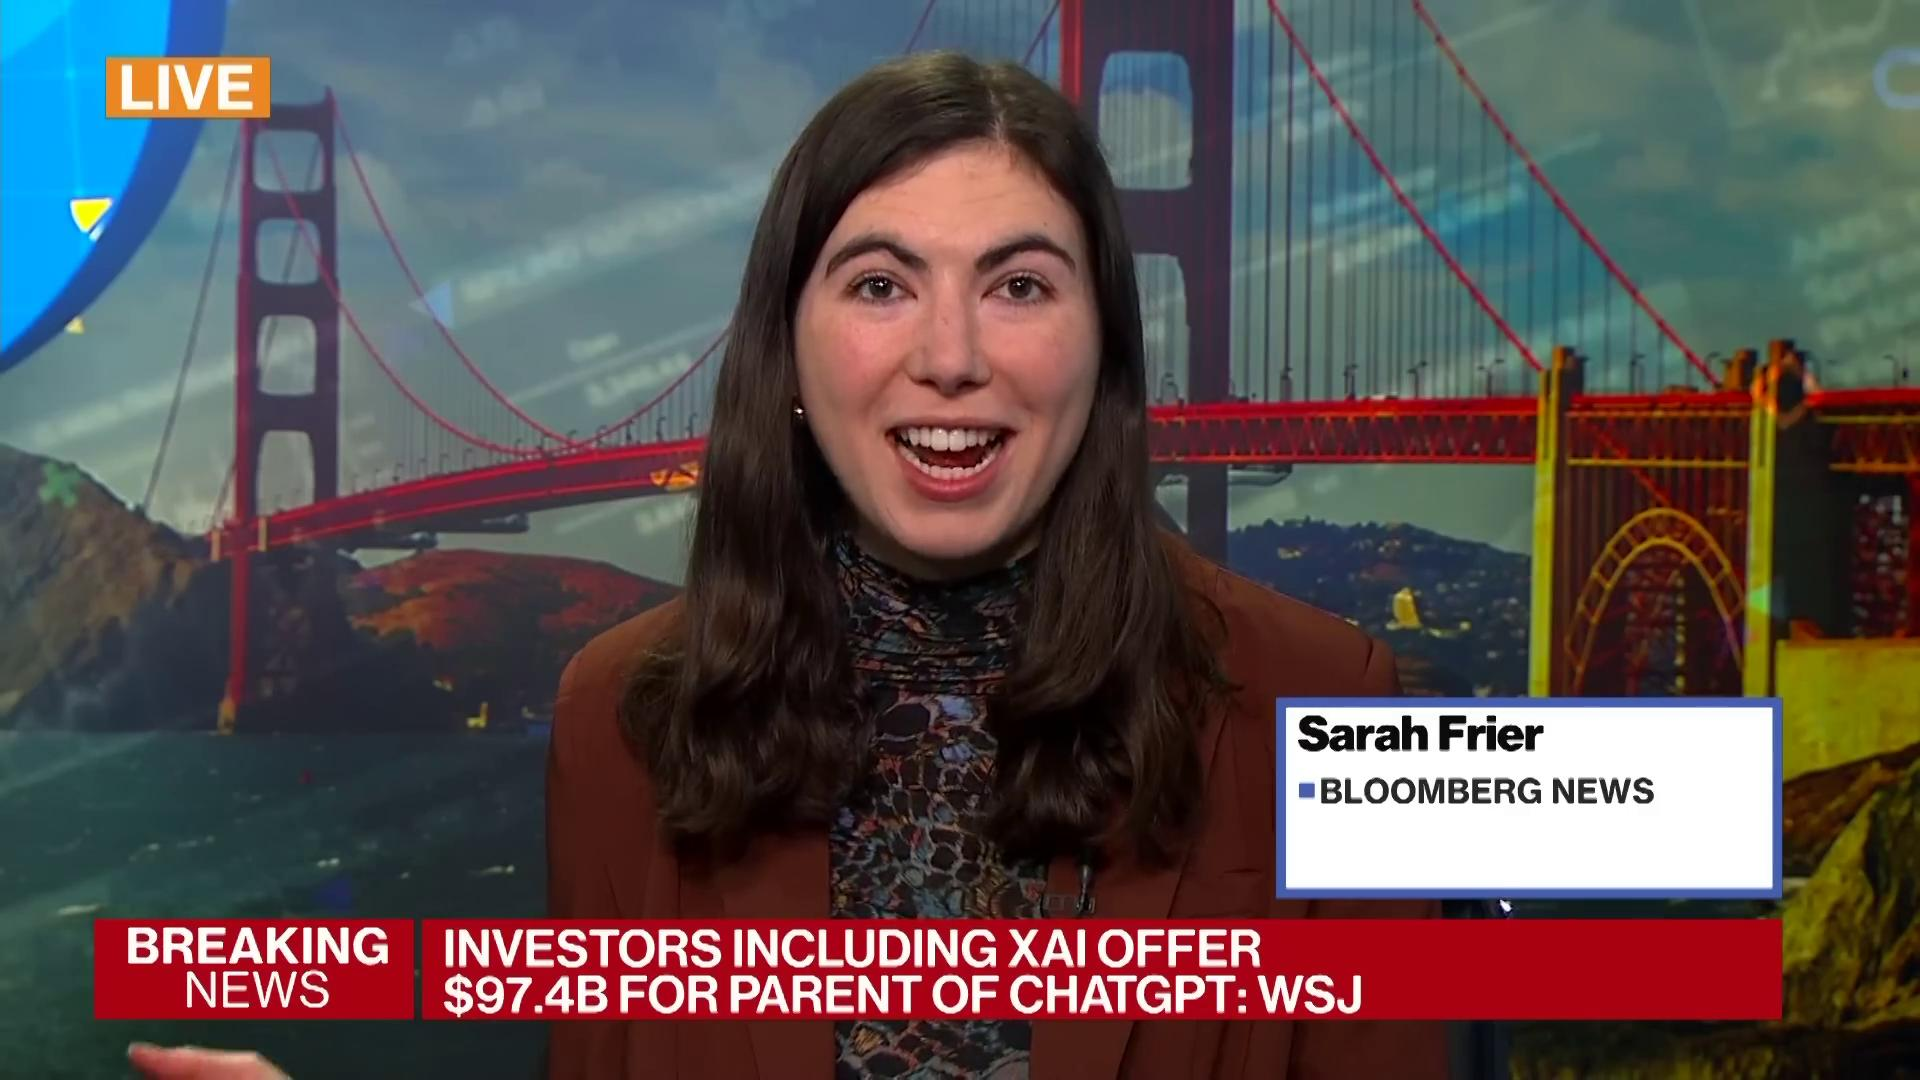

Progress: 44.2% | Frame: 21/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A woman with long dark hair, wearing a brown jacket and a patterned top, is speaking directly to the camera. Behind her is a graphic showing the Golden Gate Bridge, with some digital data overlays. A ""LIVE"" indicator is visible in the top left corner."

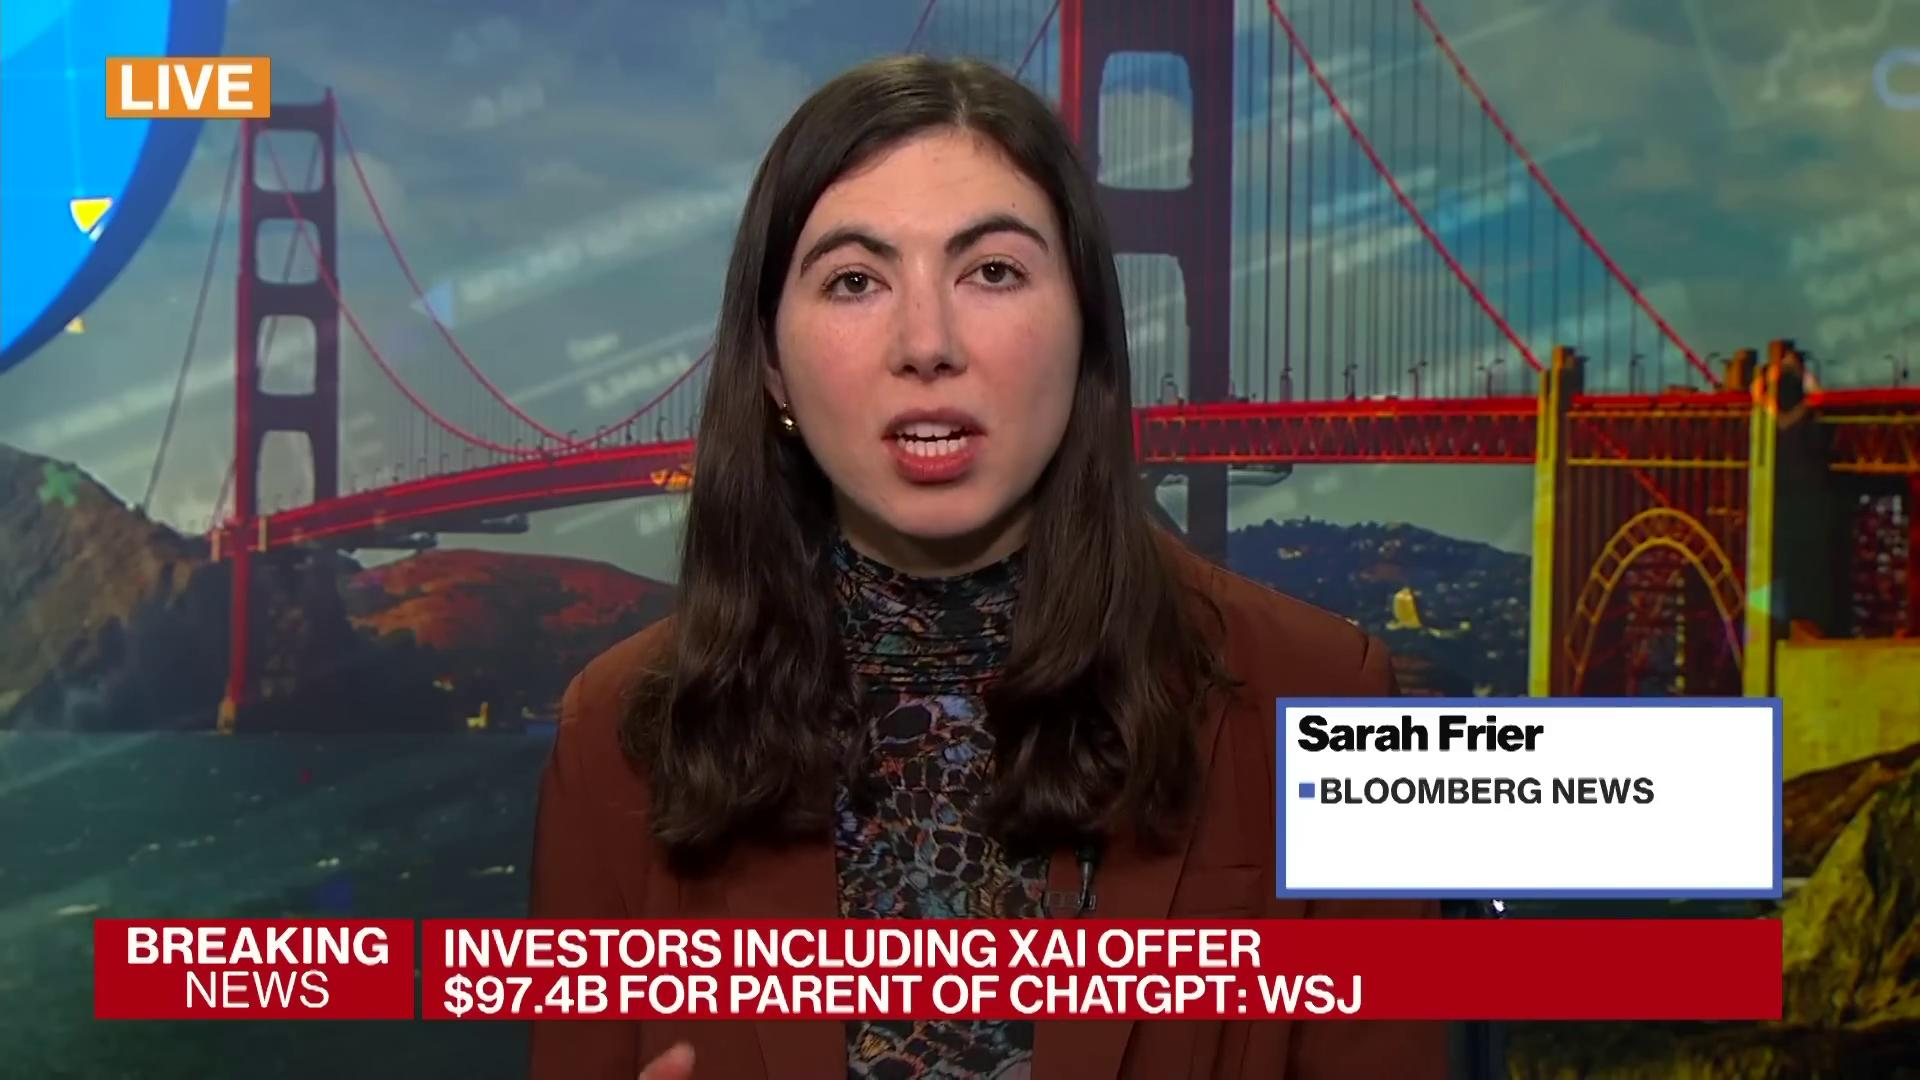

Progress: 46.4% | Frame: 22/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A female reporter is on screen, delivering news. Behind her is a graphic of the Golden Gate Bridge, overlaid with what appears to be stock market data or financial charts. A ""LIVE"" indicator is in the top left corner."

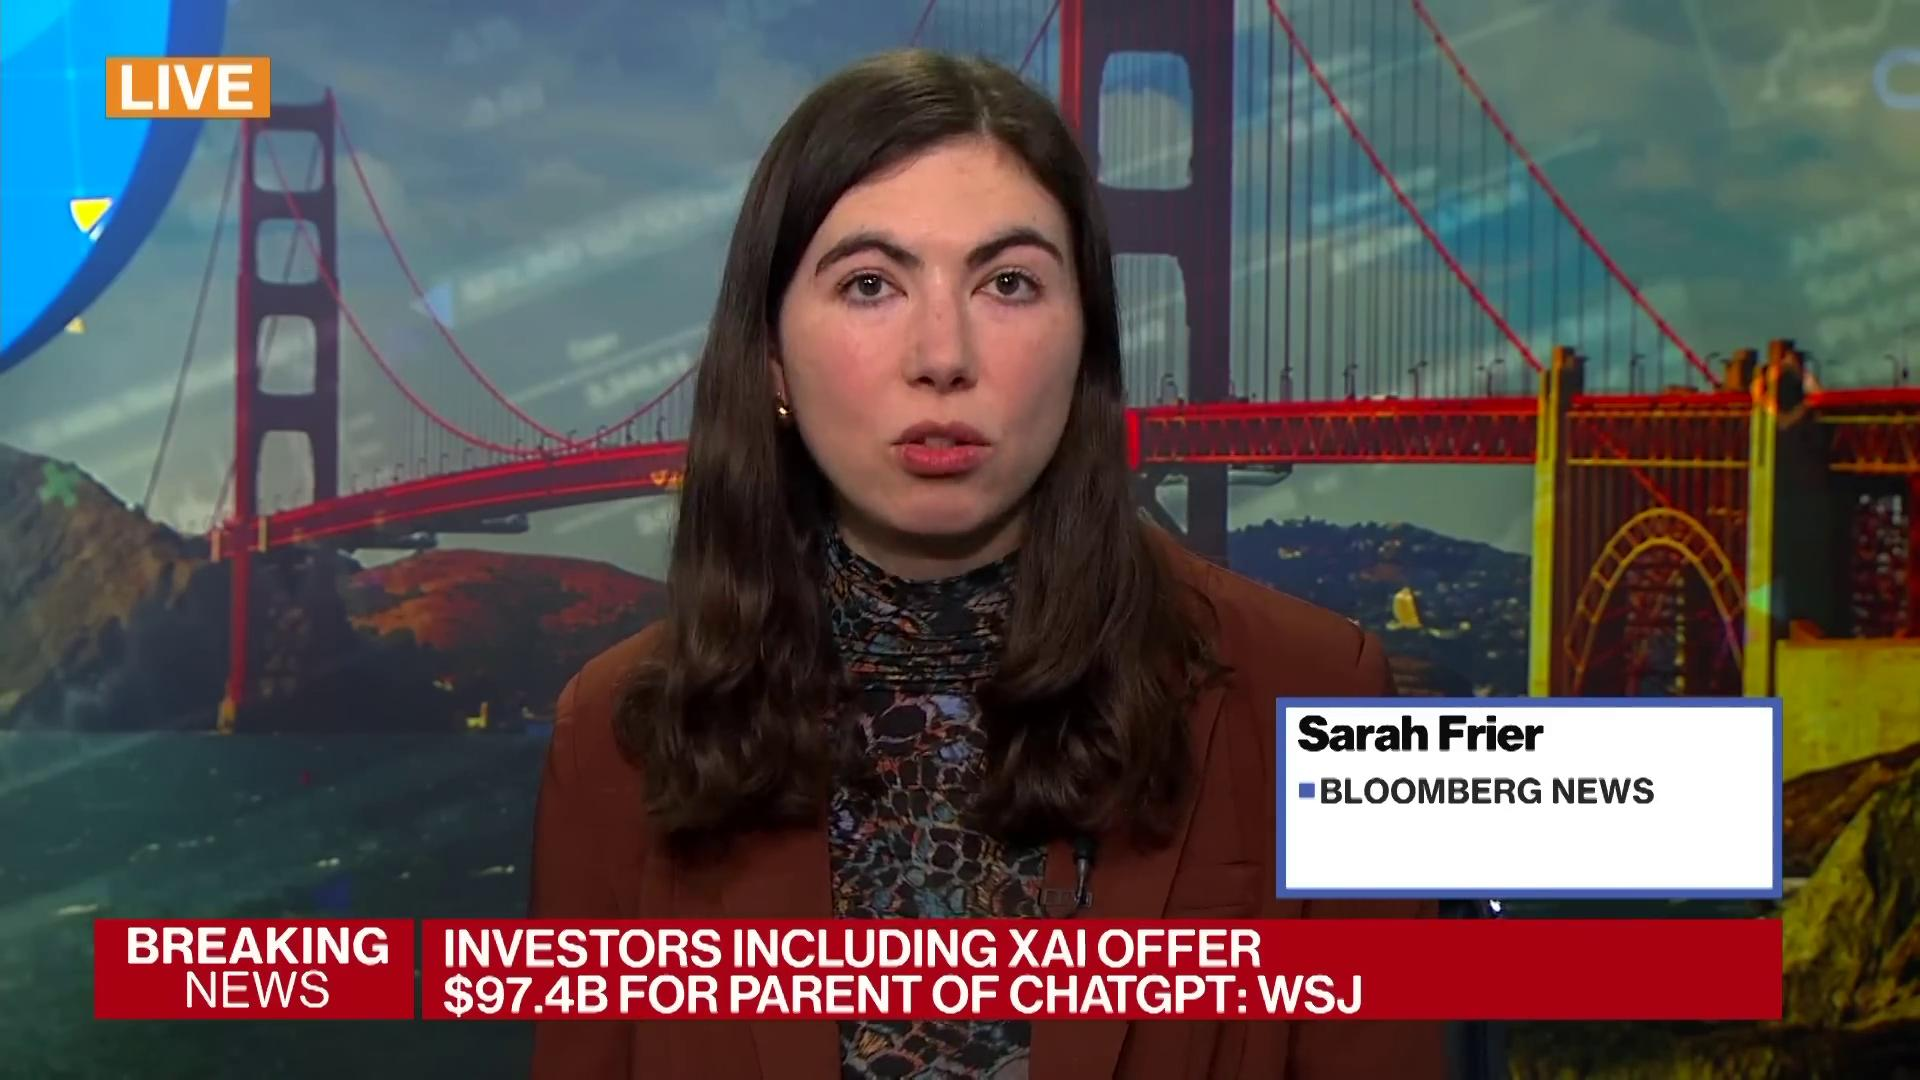

Progress: 48.6% | Frame: 23/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A female reporter, Sarah Frier, is speaking in a studio. Behind her is a graphic of the Golden Gate Bridge, suggesting a San Francisco or tech-related news context. She is wearing a brown jacket over a patterned top. A 'LIVE' indicator is visible in the top left corner."

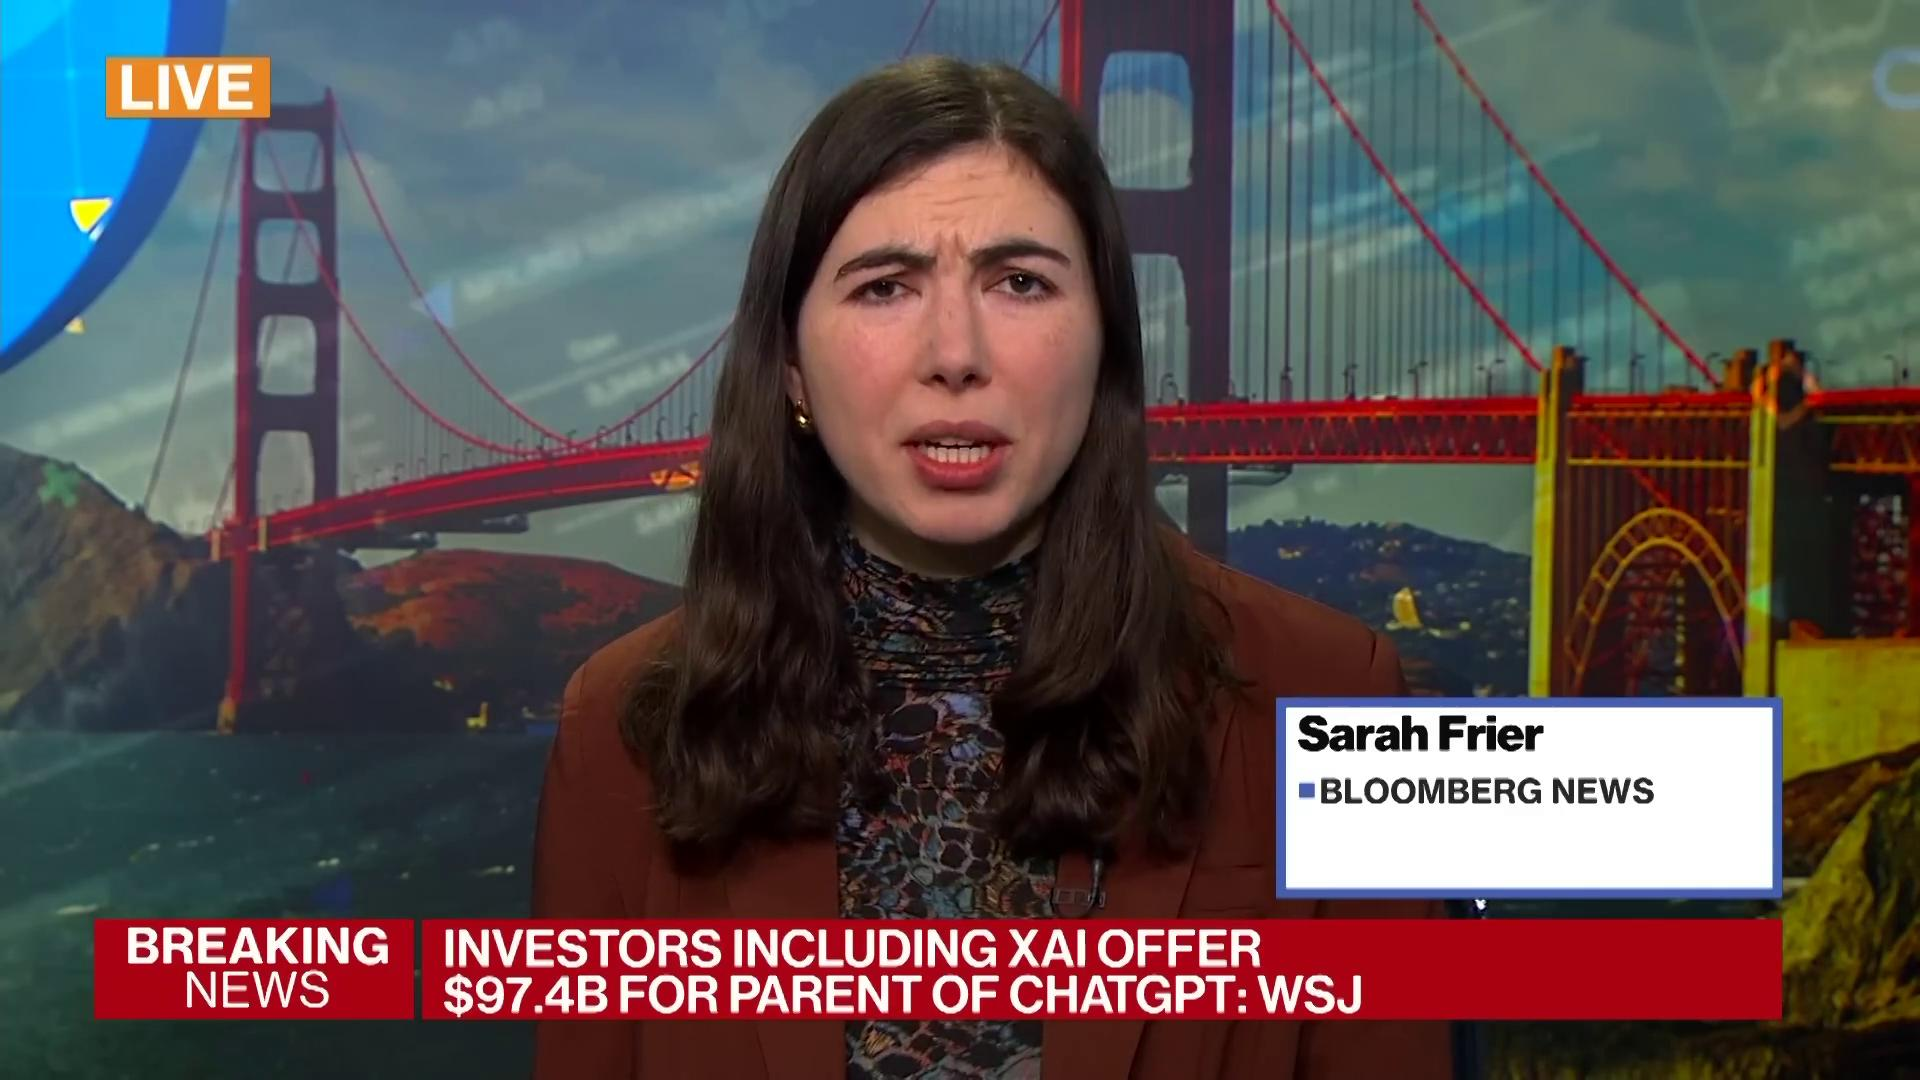

Progress: 50.8% | Frame: 24/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A woman, identified as Sarah Frier, is reporting live with a backdrop featuring the Golden Gate Bridge and some financial data graphics. She is wearing a brown jacket over a patterned top."

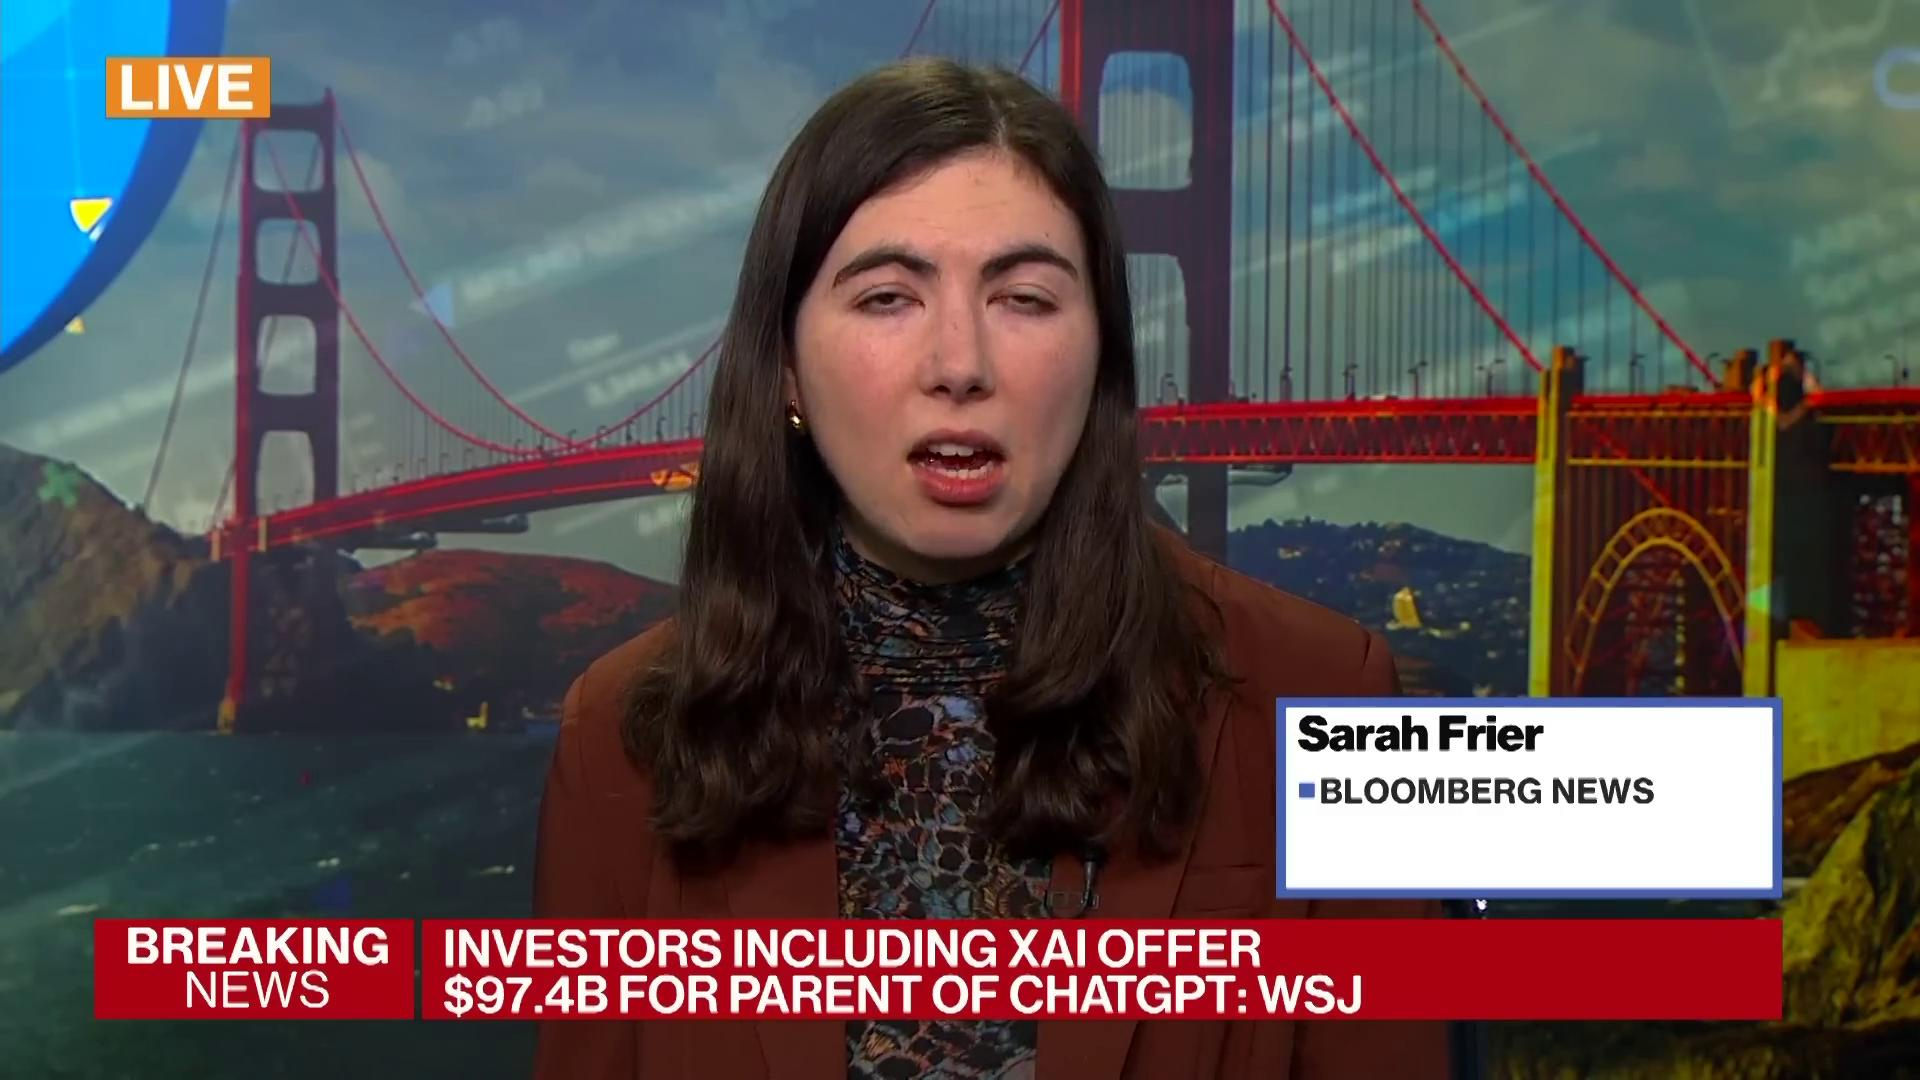

Progress: 53.1% | Frame: 25/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A woman with dark hair is speaking, facing the camera. She is wearing a brown jacket over a patterned top. Behind her is a graphic of the Golden Gate Bridge with some transparent data overlays. In the top left corner, there's a 'LIVE' indicator. A lower third graphic displays ""BREAKING NEWS"" and a news headline. Another graphic box on the right side of the screen identifies the speaker."

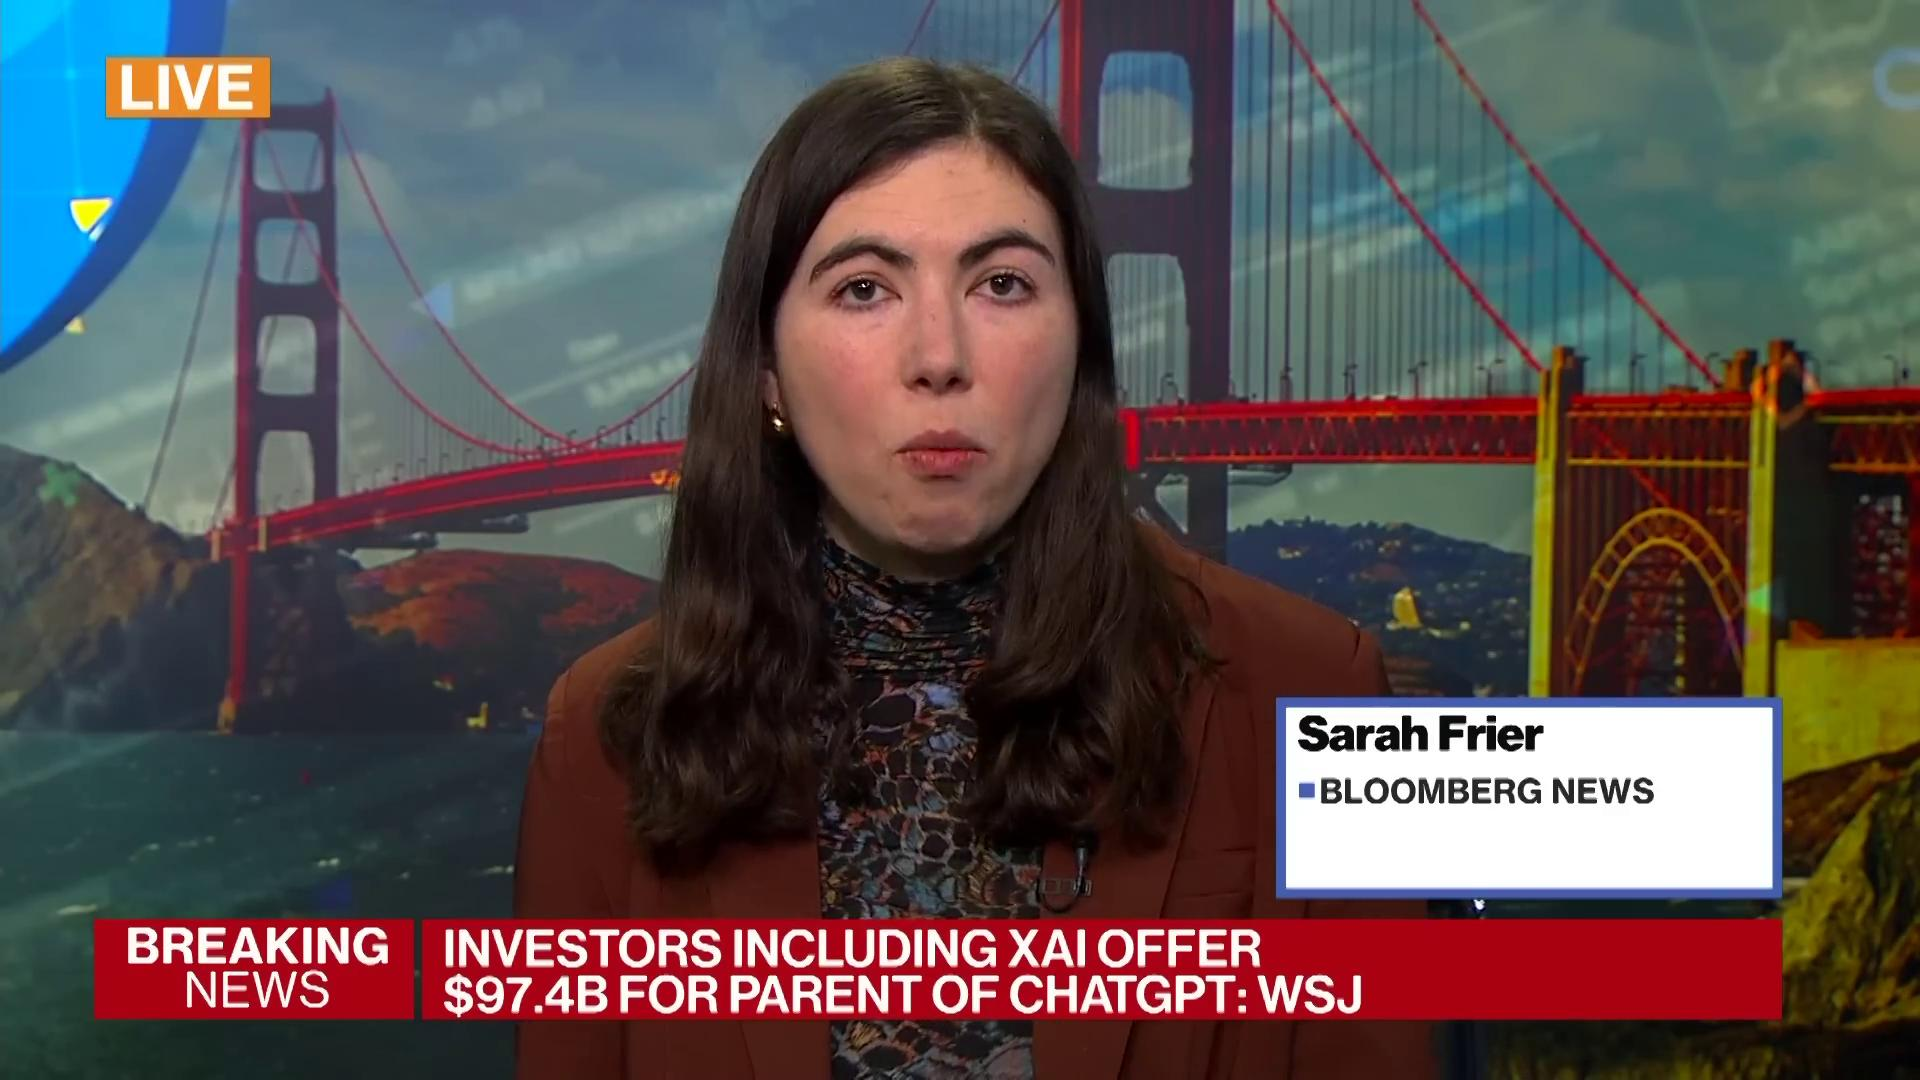

Progress: 55.3% | Frame: 26/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A woman with long dark hair, identified as Sarah Frier, is speaking in a news broadcast. She is wearing a brown blazer over a patterned top. Behind her is a graphic of the Golden Gate Bridge, with some digital data overlay. A 'LIVE' indicator is in the top left corner."

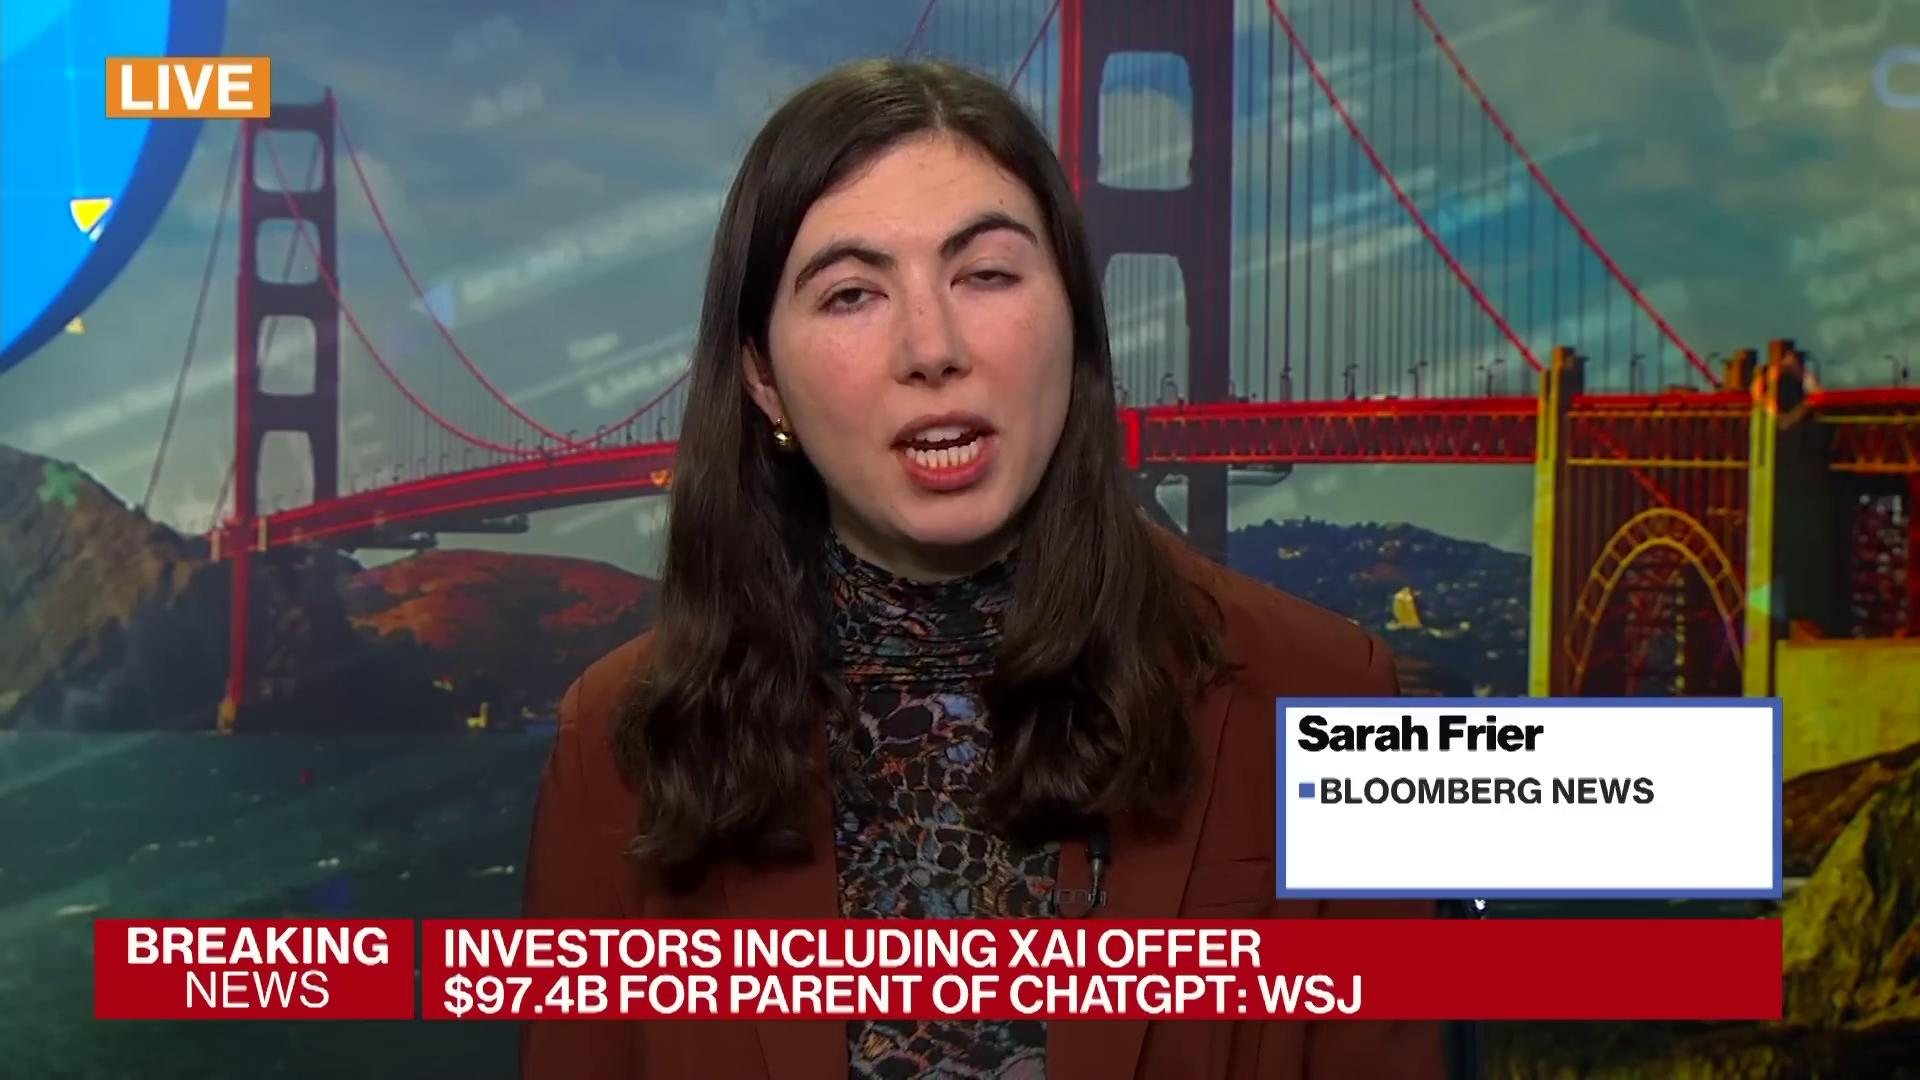

Progress: 57.5% | Frame: 27/45


Field,Content
Network,None
Chyron,BREAKING NEWS INVESTORS INCLUDING ΧΑΙ OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"A female reporter is speaking, with a background featuring a blurry image of the Golden Gate Bridge and text related to ""Introducing ChatGPT search."""

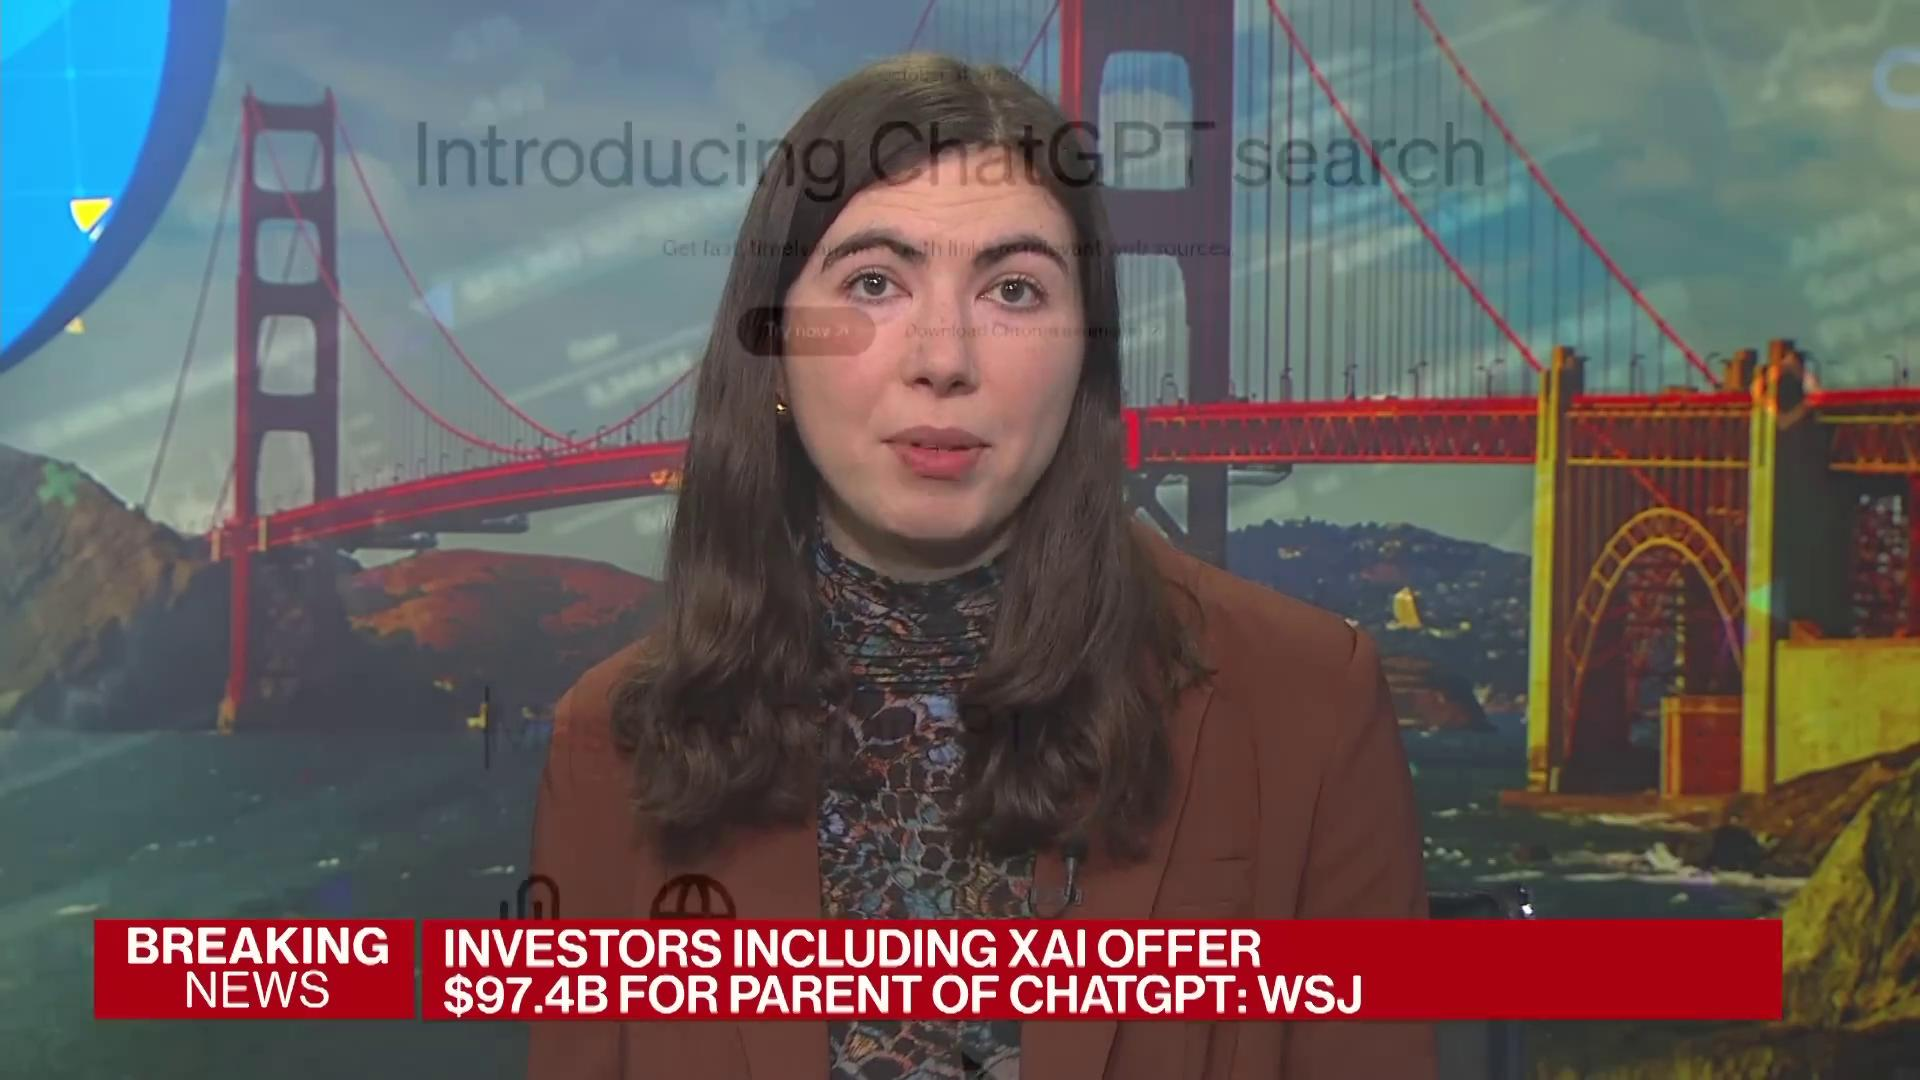

Progress: 59.7% | Frame: 28/45


Field,Content
Network,None
Chyron,BREAKING NEWS | INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"A screen displaying an announcement for 'Introducing ChatGPT search' with a prompt 'help me plan a road trip' in a search bar, overlaid with a breaking news chyron at the bottom."

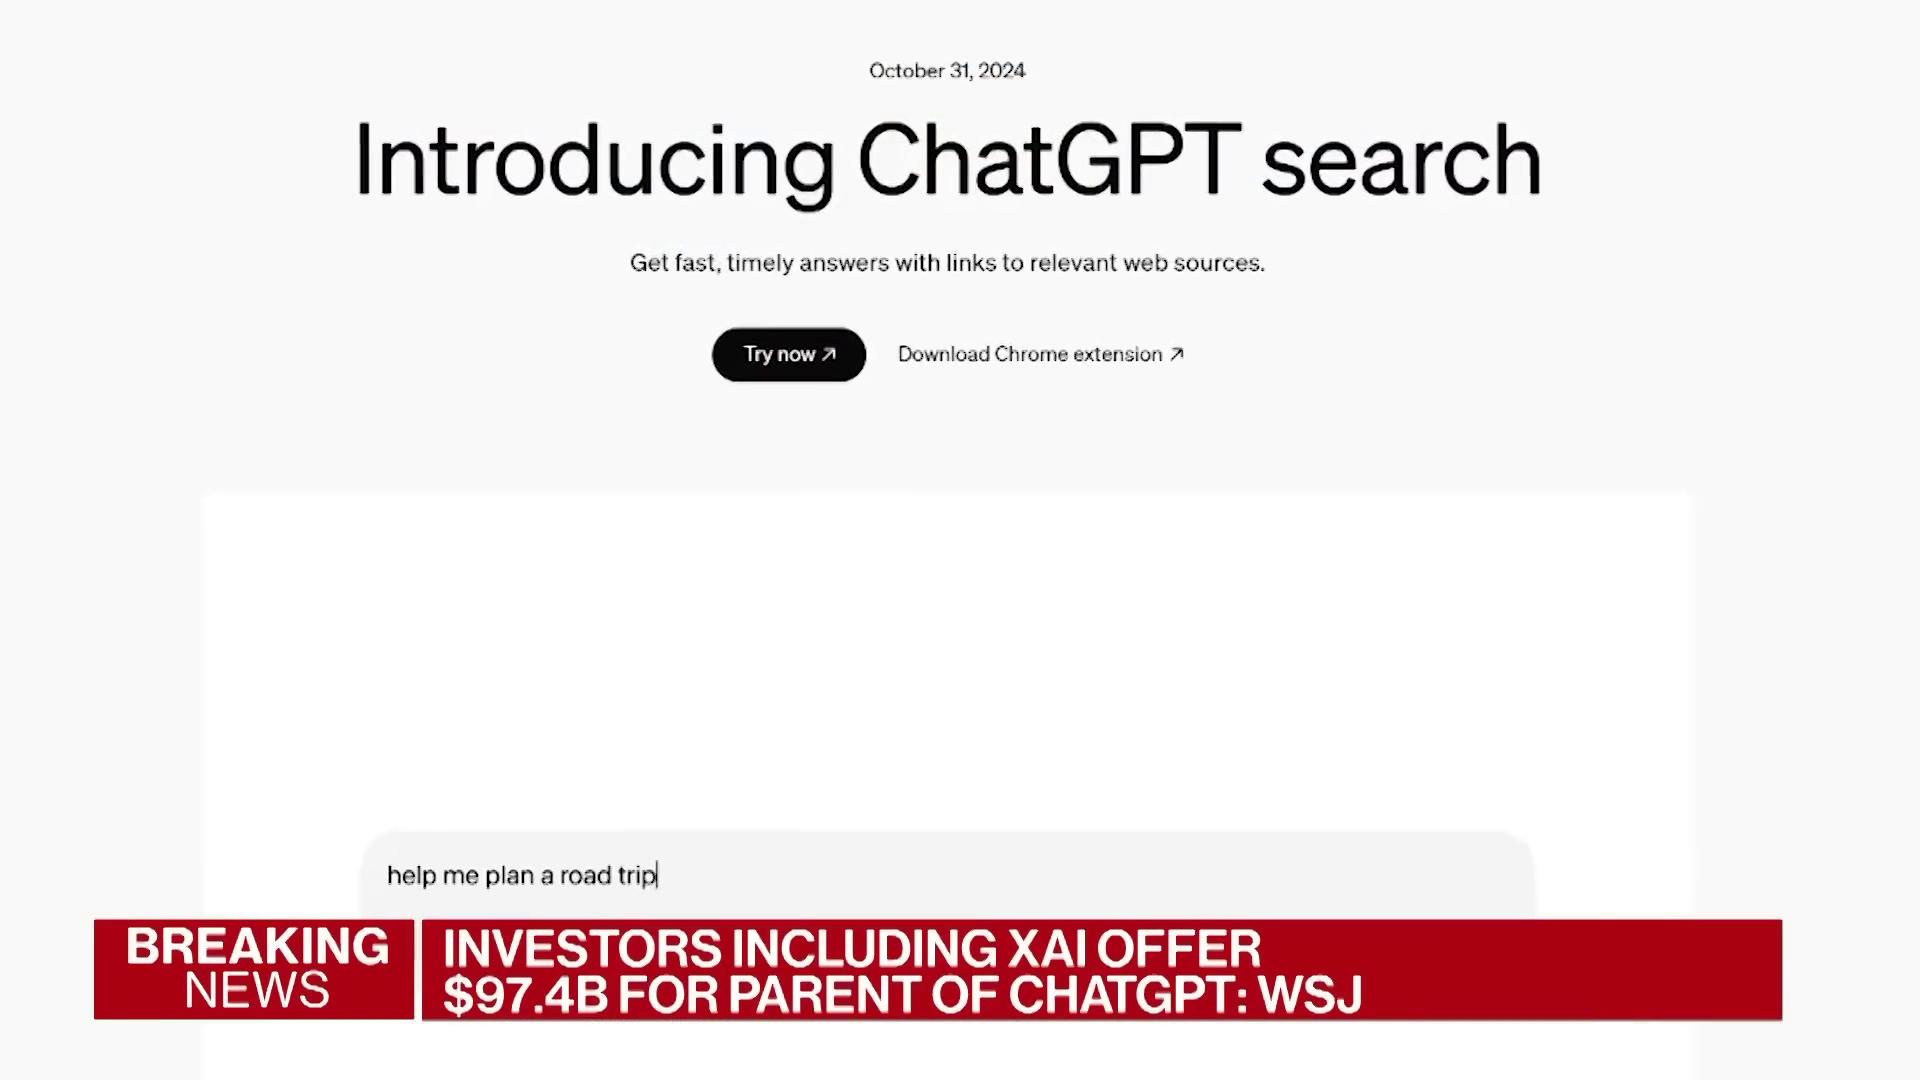

Progress: 61.9% | Frame: 29/45


Field,Content
Network,WSJ
Chyron,BREAKING NEWS | INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,None

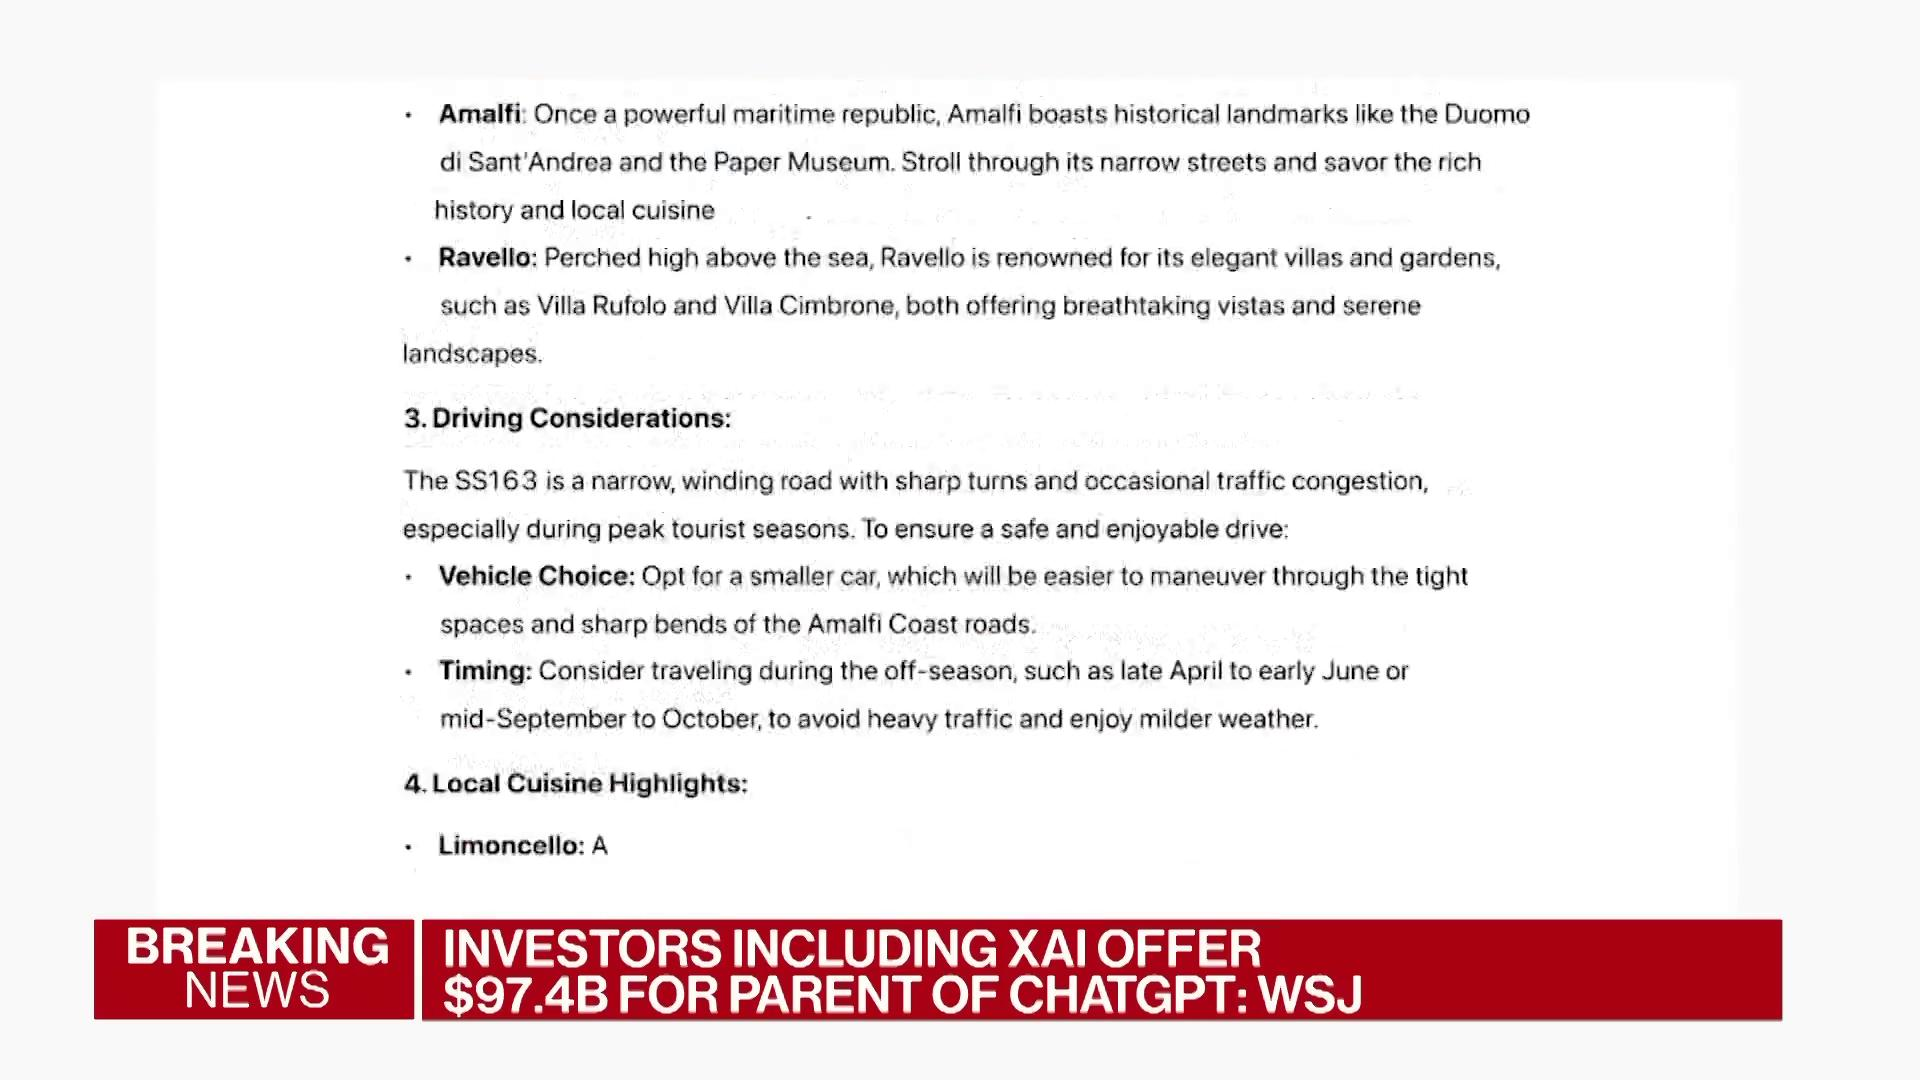

Progress: 64.1% | Frame: 30/45


Field,Content
Network,WSJ
Chyron,BREAKING NEWS | INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"The scene displays a webpage with travel-related content, including hotel recommendations for Positano and an itinerary for the Amalfi Coast. At the bottom of the screen, there is a red breaking news banner."

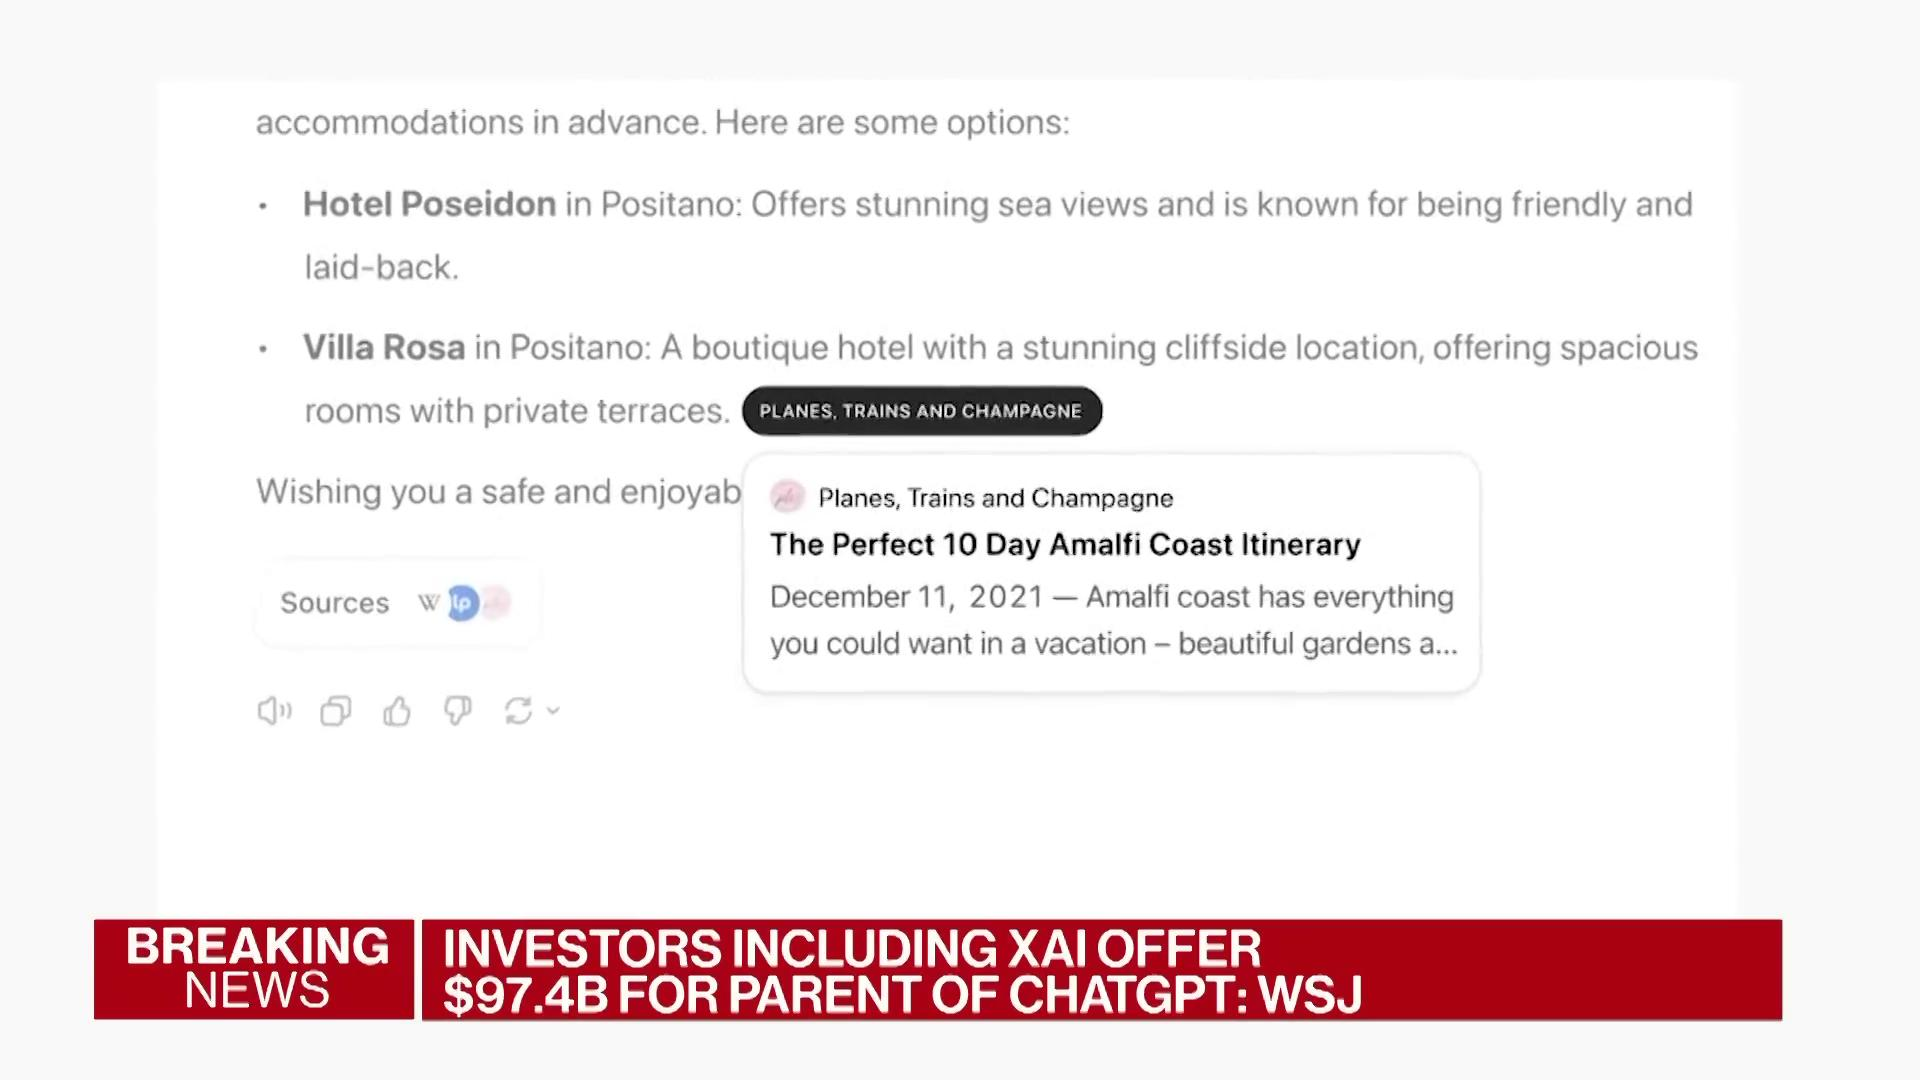

Progress: 66.3% | Frame: 31/45


Field,Content
Network,WSJ
Chyron,BREAKING NEWS | INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"The screen displays an article about restaurants in Positano, specifically 'La Tagliata' and 'Il Ritrovo', with accompanying images of the restaurant views and settings. Below this, a news chyron is visible."

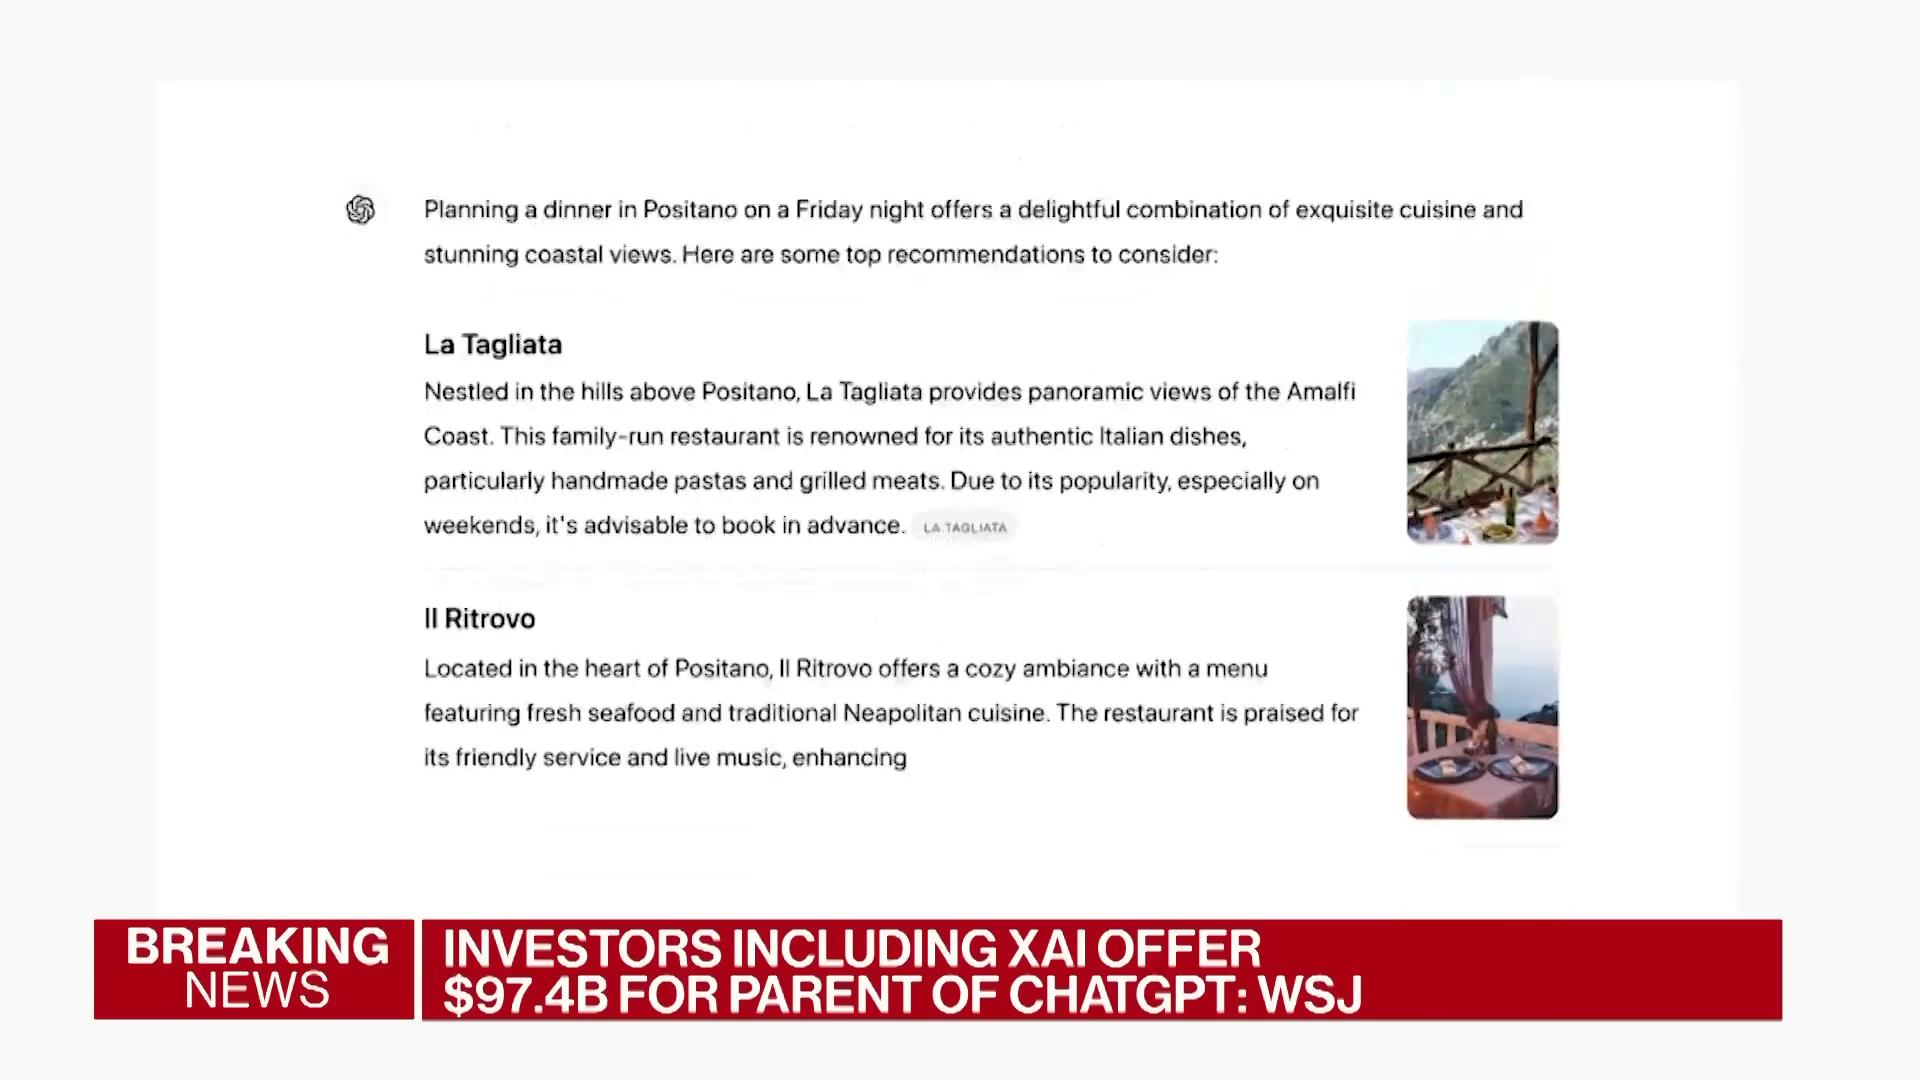

Progress: 68.5% | Frame: 32/45


Field,Content
Network,None
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"The image displays a screenshot of a 'ChatGPT search' interface, dated October 31, 2024, showing text 'Introducing ChatGPT search' and an input field 'Message ChatGPT'. Below this main content, there is a red breaking news banner (chyron) at the bottom of the screen."

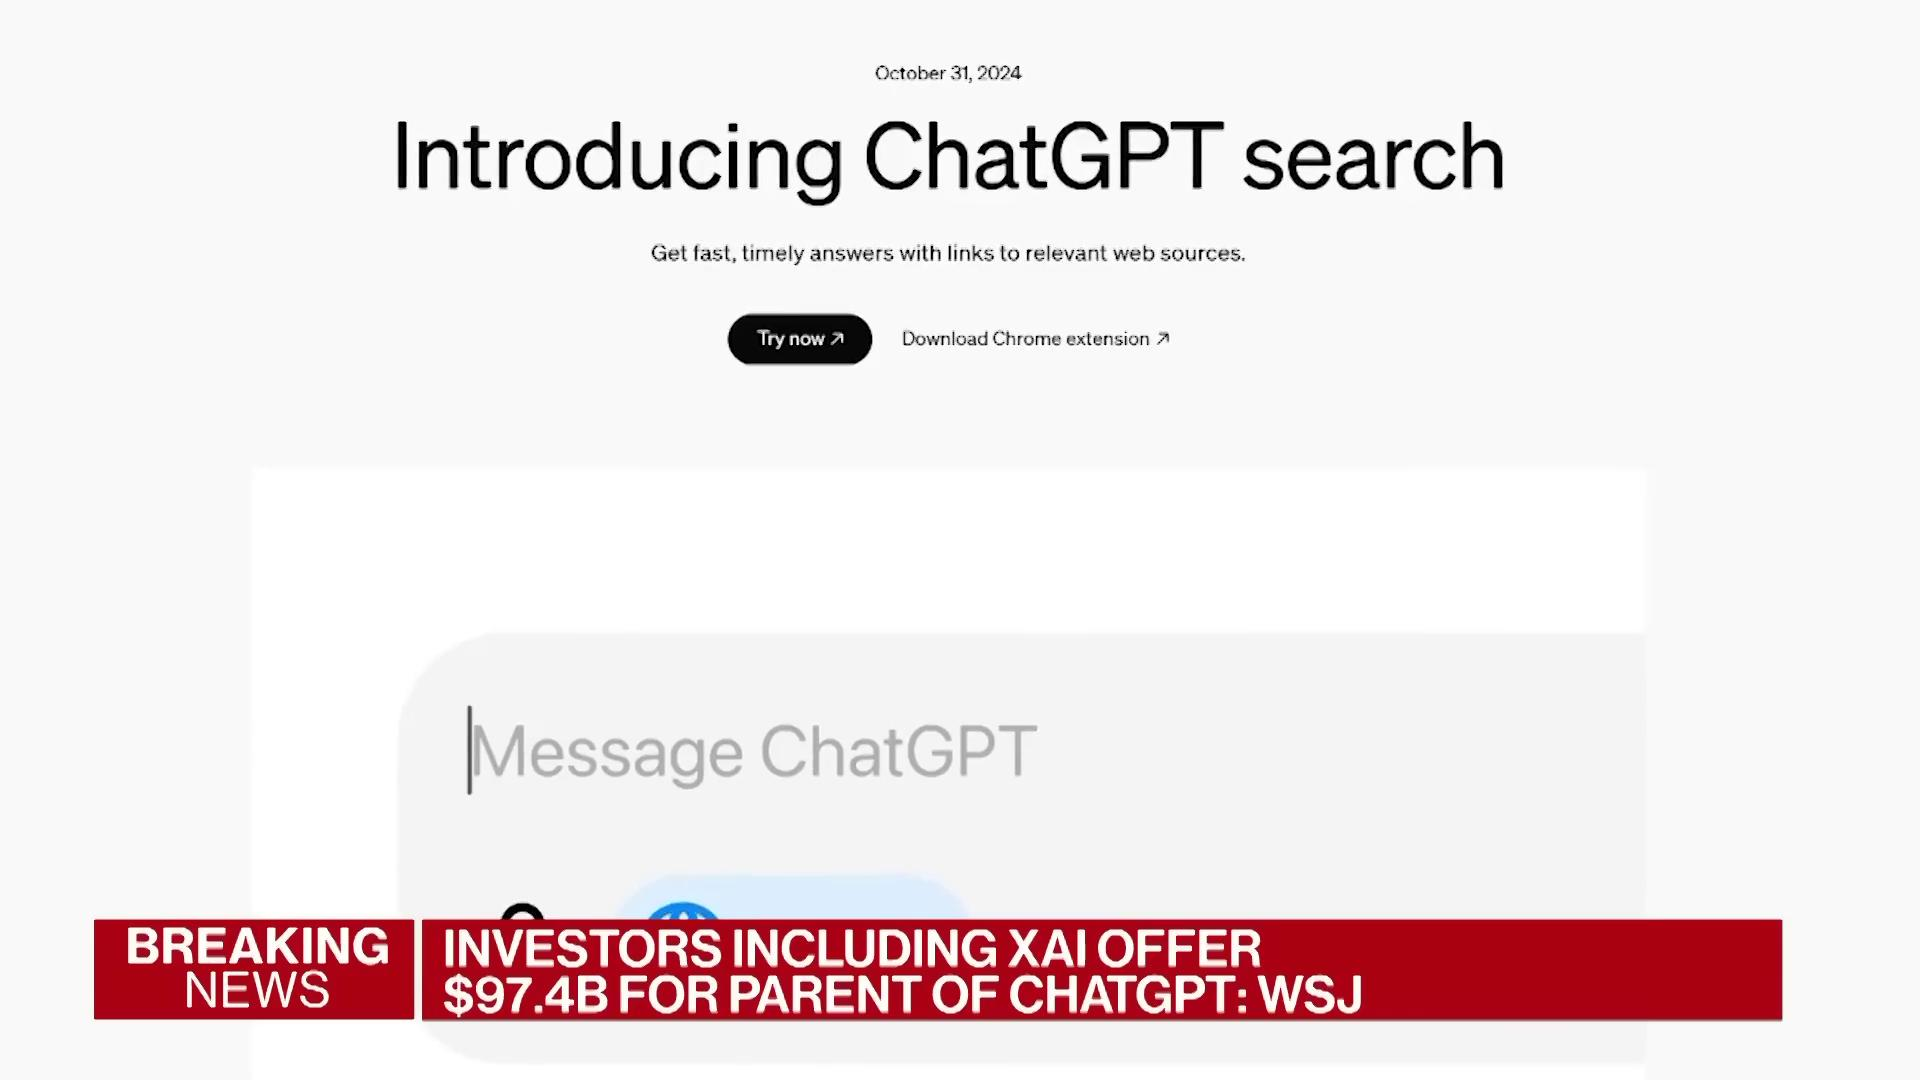

Progress: 70.7% | Frame: 33/45


Field,Content
Network,WSJ
Chyron,BREAKING NEWS | INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"A screenshot of a webpage introducing 'ChatGPT search', showing an example query for 'Guide to Planning a Trip to Amalfi Coast' from ItaliaRail. Below the webpage content, a red news chyron is displayed."

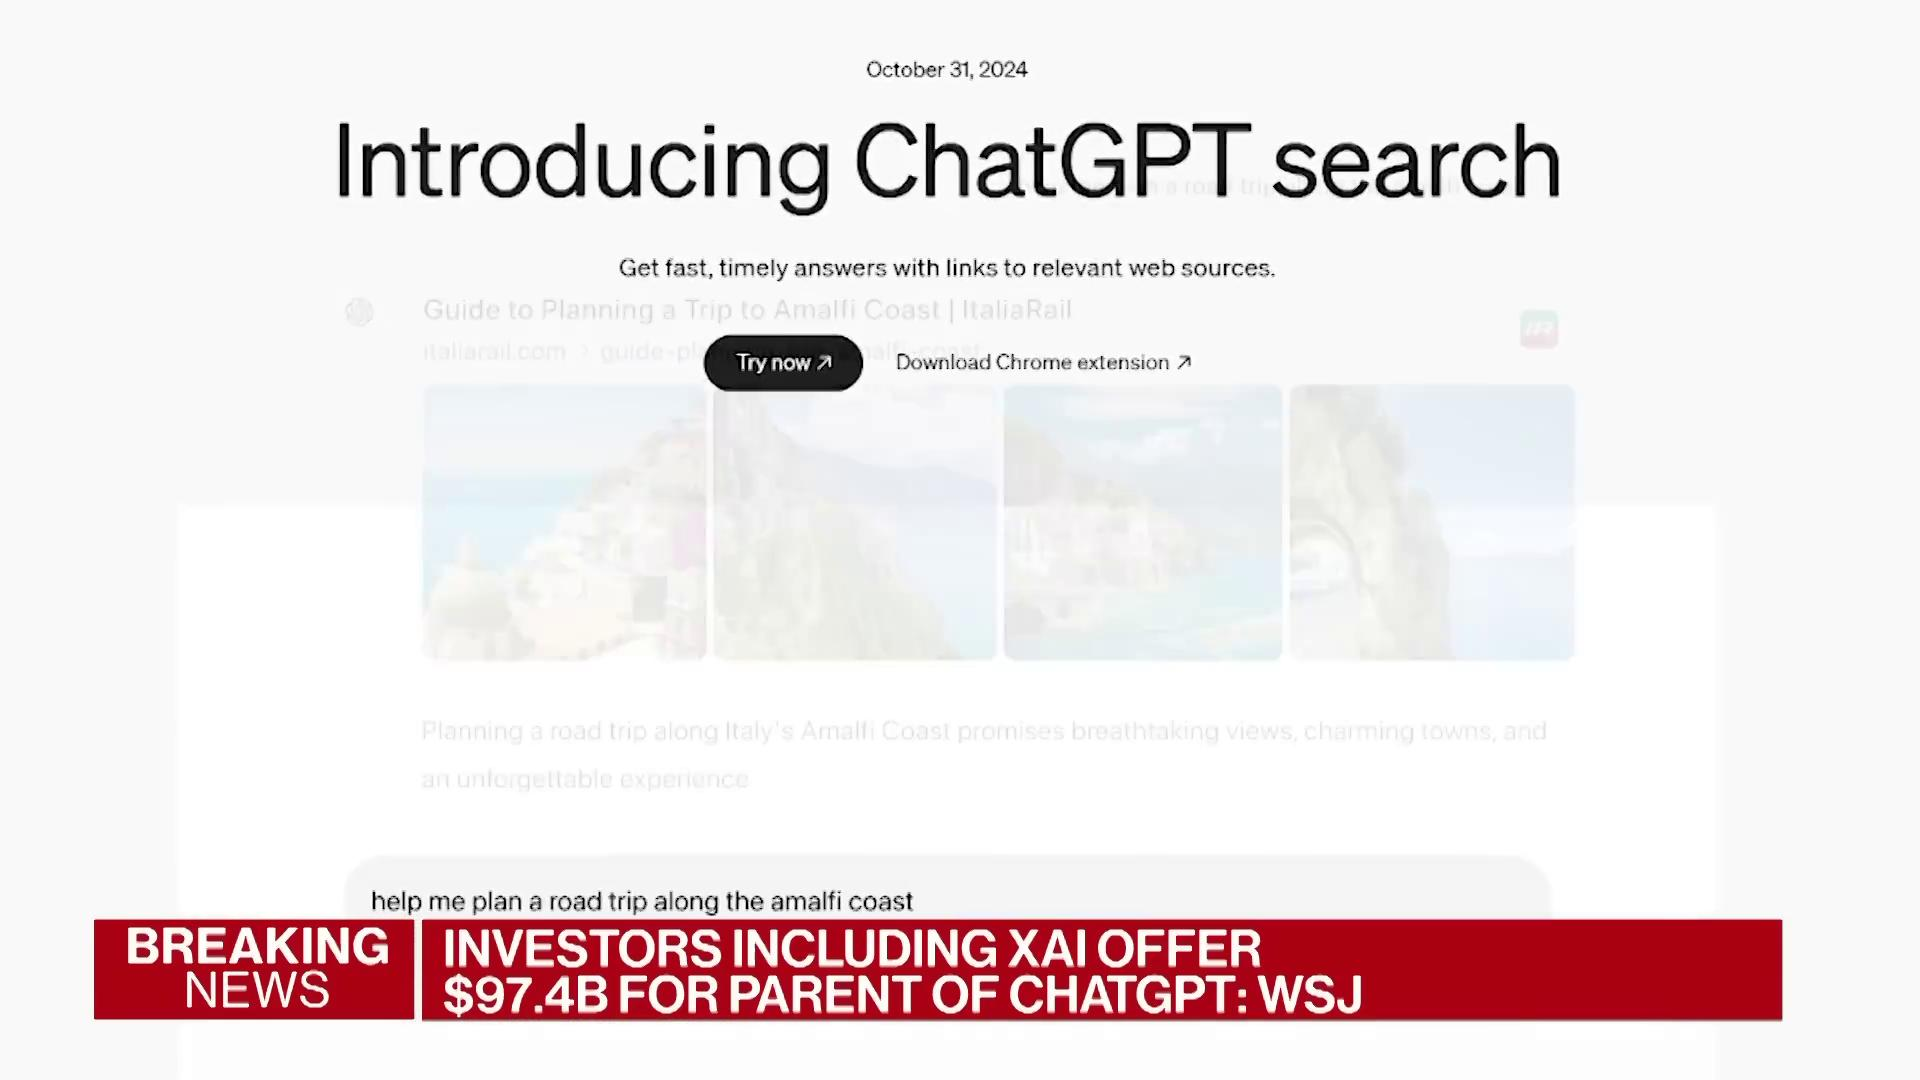

Progress: 72.9% | Frame: 34/45


Field,Content
Network,Bloomberg
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"Two women, possibly news anchors or reporters, are featured in a split-screen broadcast. The woman on the left has dark hair and is wearing a white and dark green top. The woman on the right has dark, wavy hair and is wearing a brown blazer over a patterned top. The background behind the woman on the left appears to be a blurred city skyline, with ""Bloomberg"" visible. The background behind the woman on the right features a blurred image of what appears to be the Golden Gate Bridge and a city. A news ticker/chyron is at the bottom of the screen."

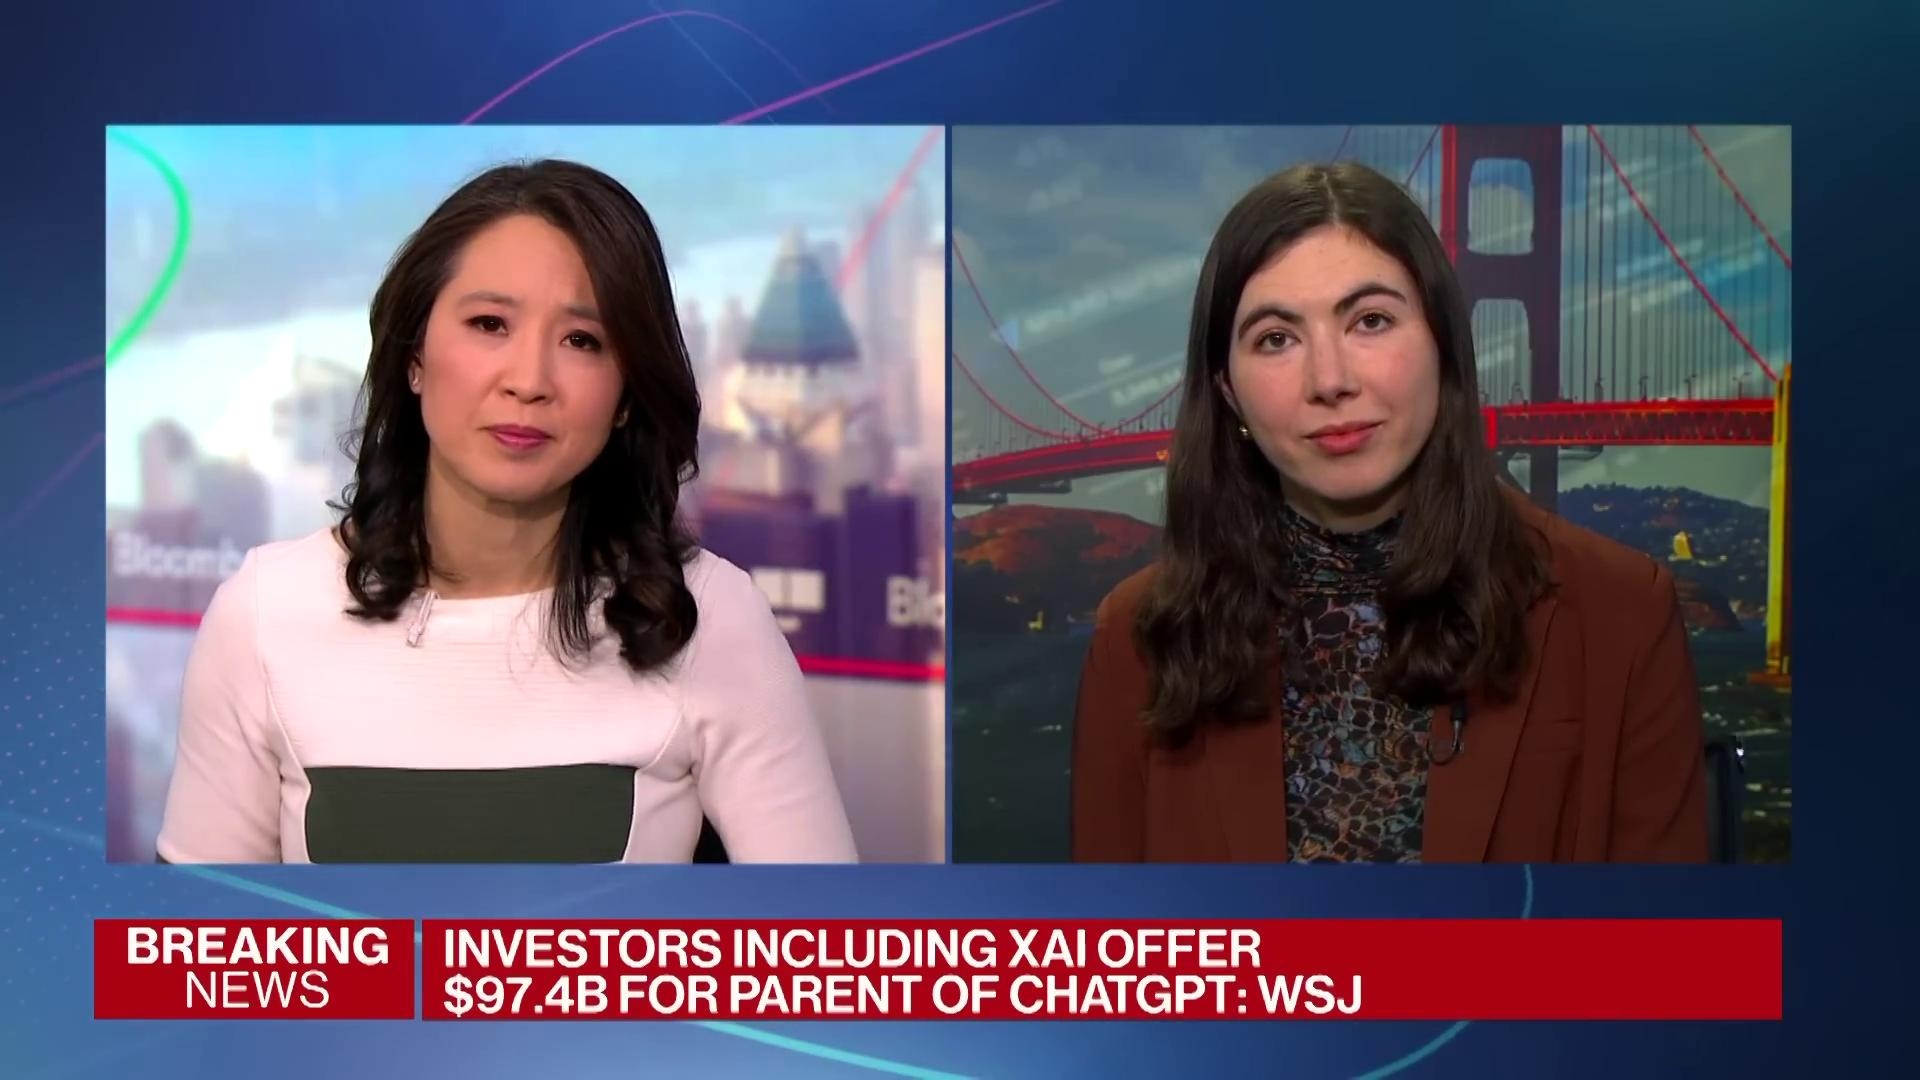

Progress: 75.2% | Frame: 35/45


Field,Content
Network,None
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"A woman with long dark hair, wearing a patterned top and a brown jacket, speaks directly to the camera. Behind her is a backdrop featuring the Golden Gate Bridge in San Francisco, with faint financial data overlays. The scene is lit for a news broadcast."

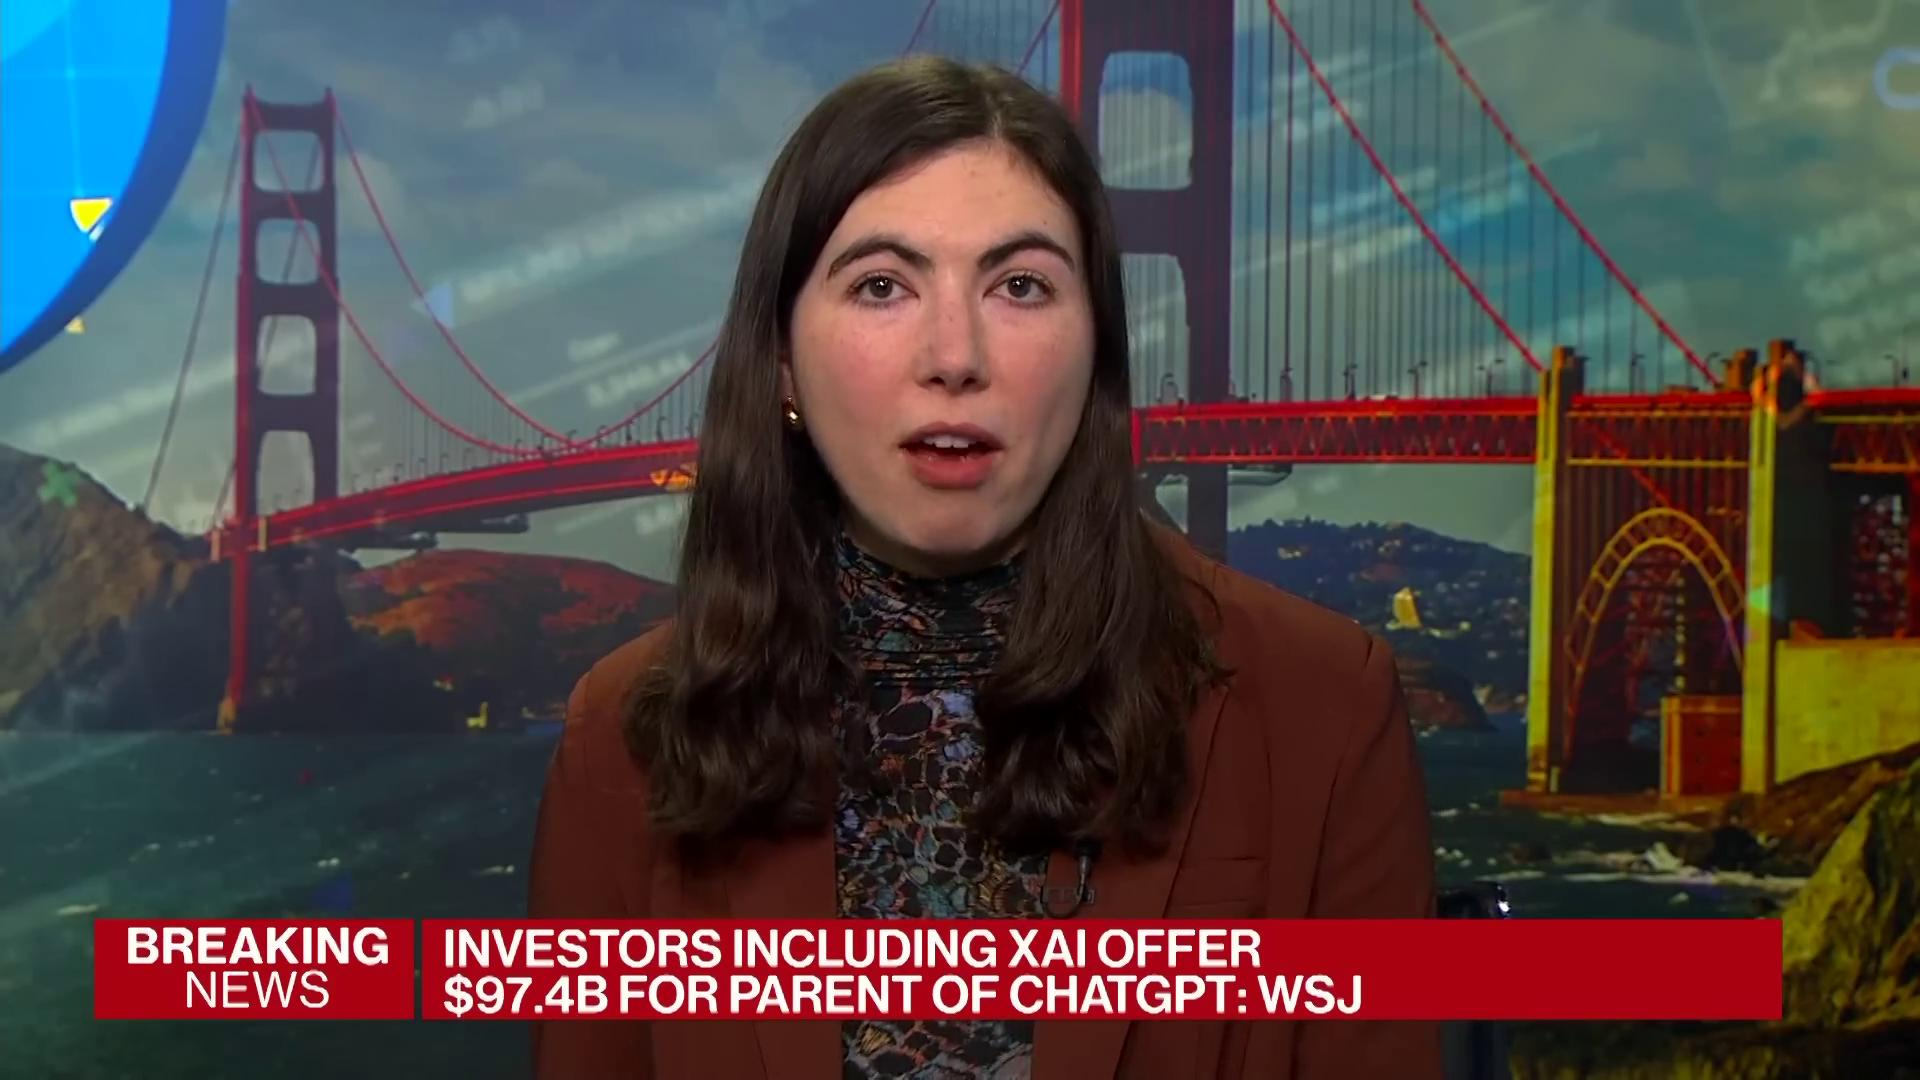

Progress: 77.4% | Frame: 36/45


Field,Content
Network,None
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,None
Description,"A young woman with long dark hair, wearing a brown jacket and a patterned top, speaks directly to the camera. She is in front of a digital backdrop featuring the Golden Gate Bridge, with additional abstract graphics or data overlaid. The setting suggests a news broadcast."

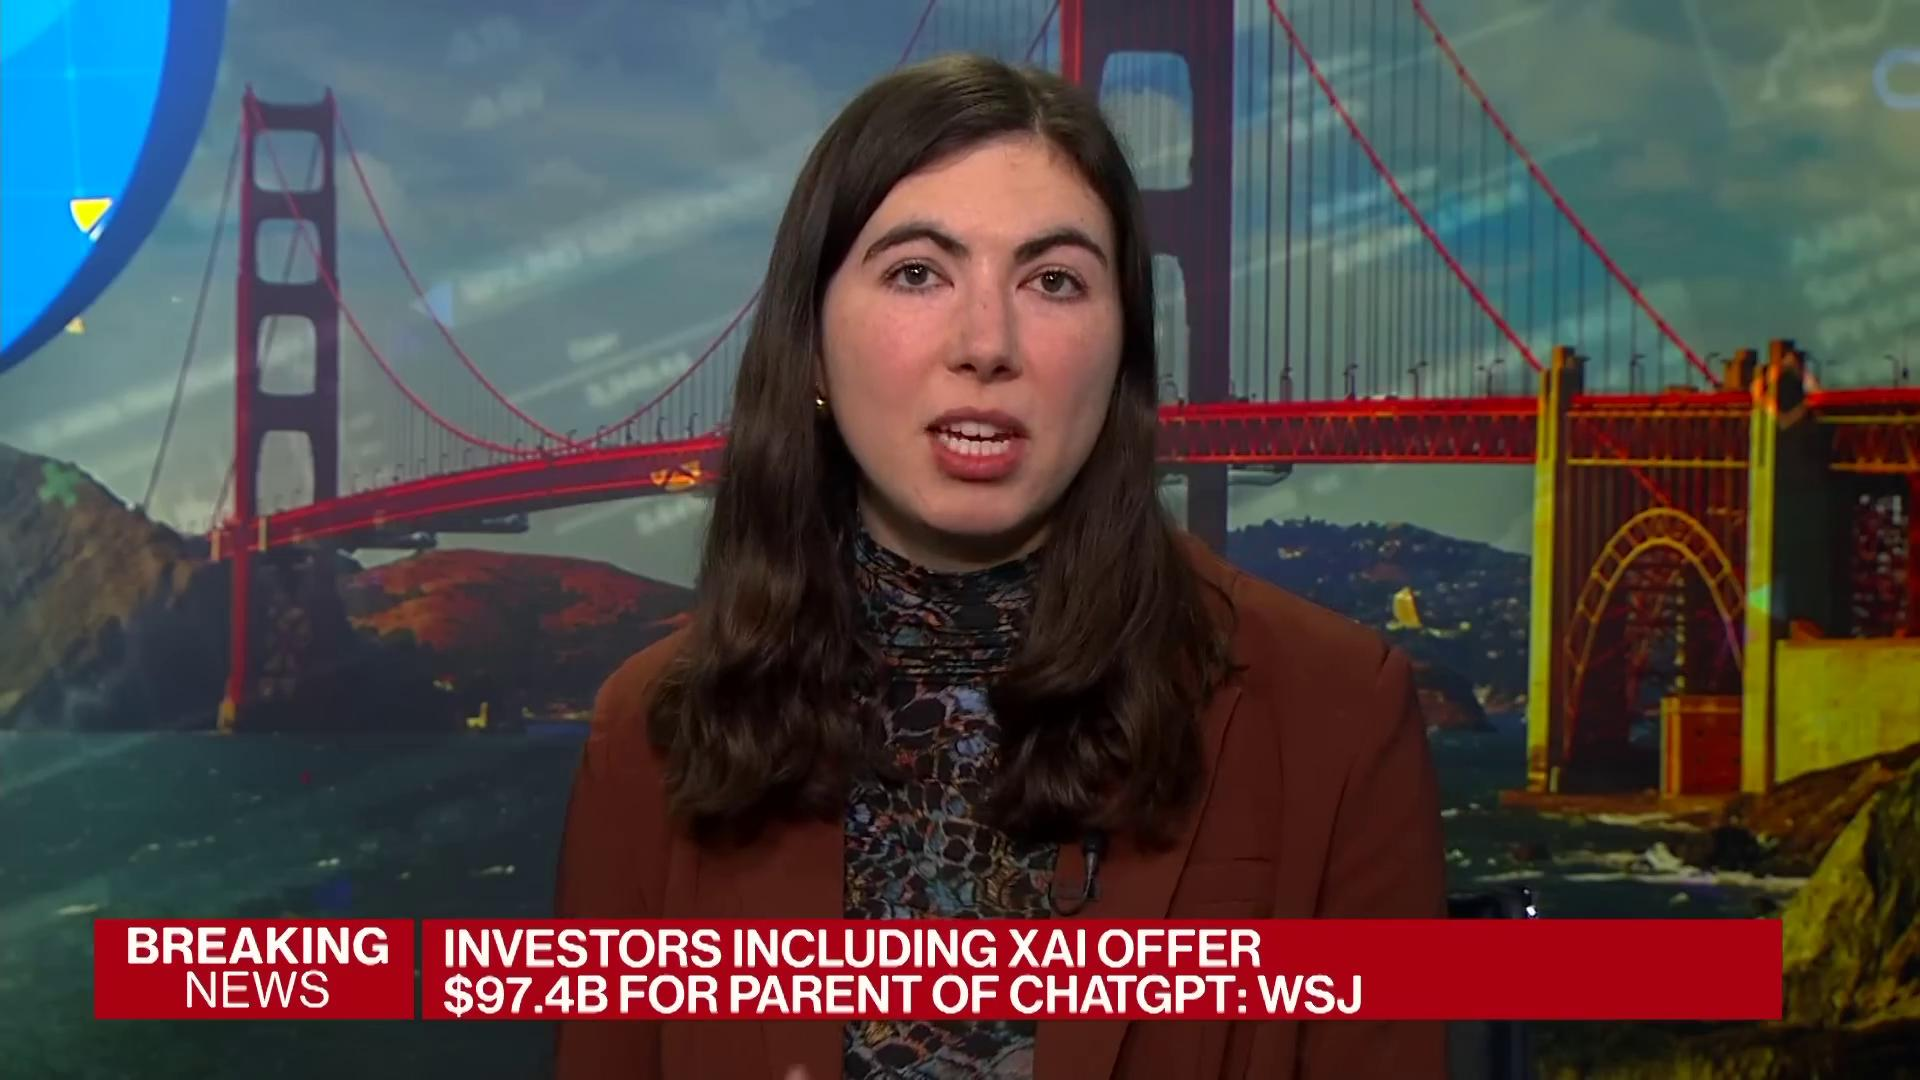

Progress: 79.6% | Frame: 37/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A female reporter is speaking live on a news broadcast. She has long dark hair and is wearing a patterned top under a brown jacket. Behind her is a stylized, somewhat translucent graphic of the Golden Gate Bridge, with what appears to be financial data or charts overlaid. A 'LIVE' indicator is visible in the top left corner. A lower third graphic identifies the reporter and network, and a 'BREAKING NEWS' chyron is displayed at the bottom of the screen."

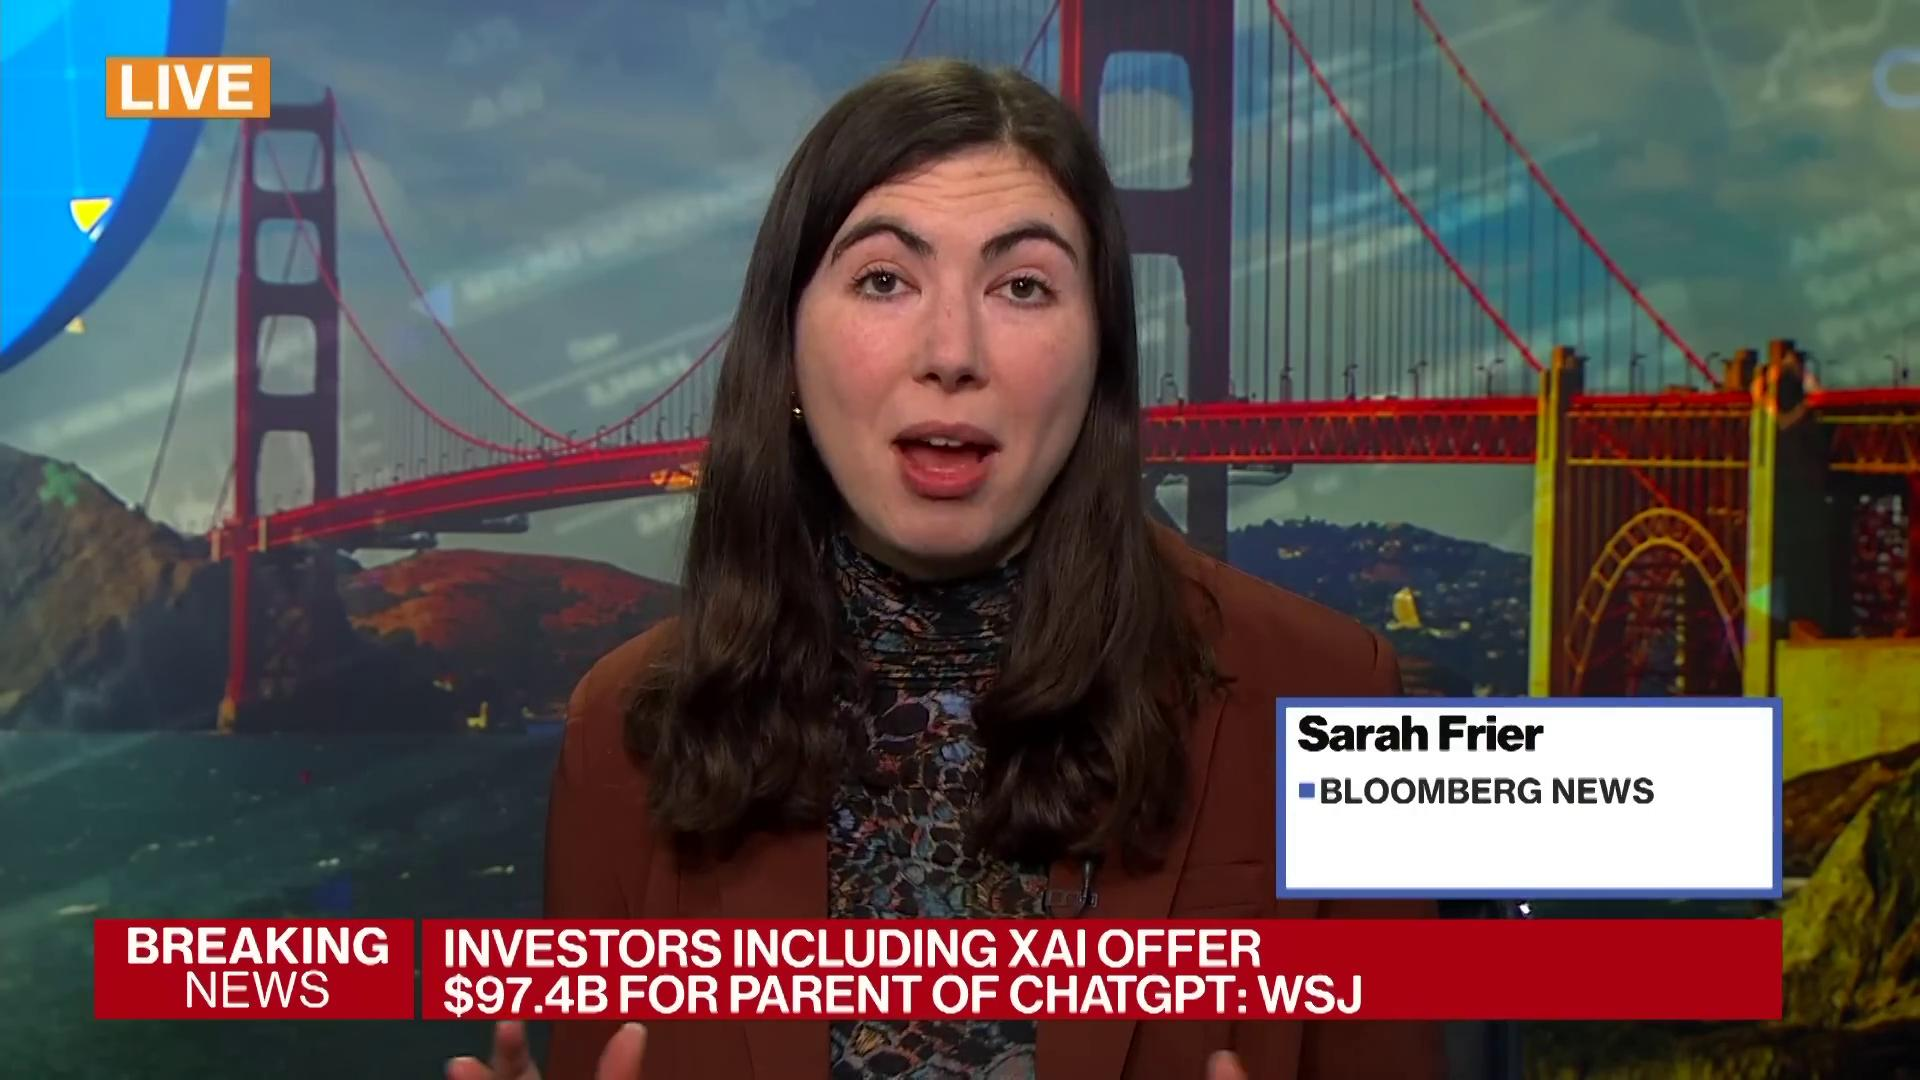

Progress: 81.8% | Frame: 38/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A woman with long dark hair is speaking, looking directly at the camera. She is wearing a brown blazer over a patterned top. Behind her is a graphic or video background featuring the Golden Gate Bridge, with some digital overlays or data visible. A ""LIVE"" indicator is in the top left corner. The bottom of the screen features a red chyron with breaking news."

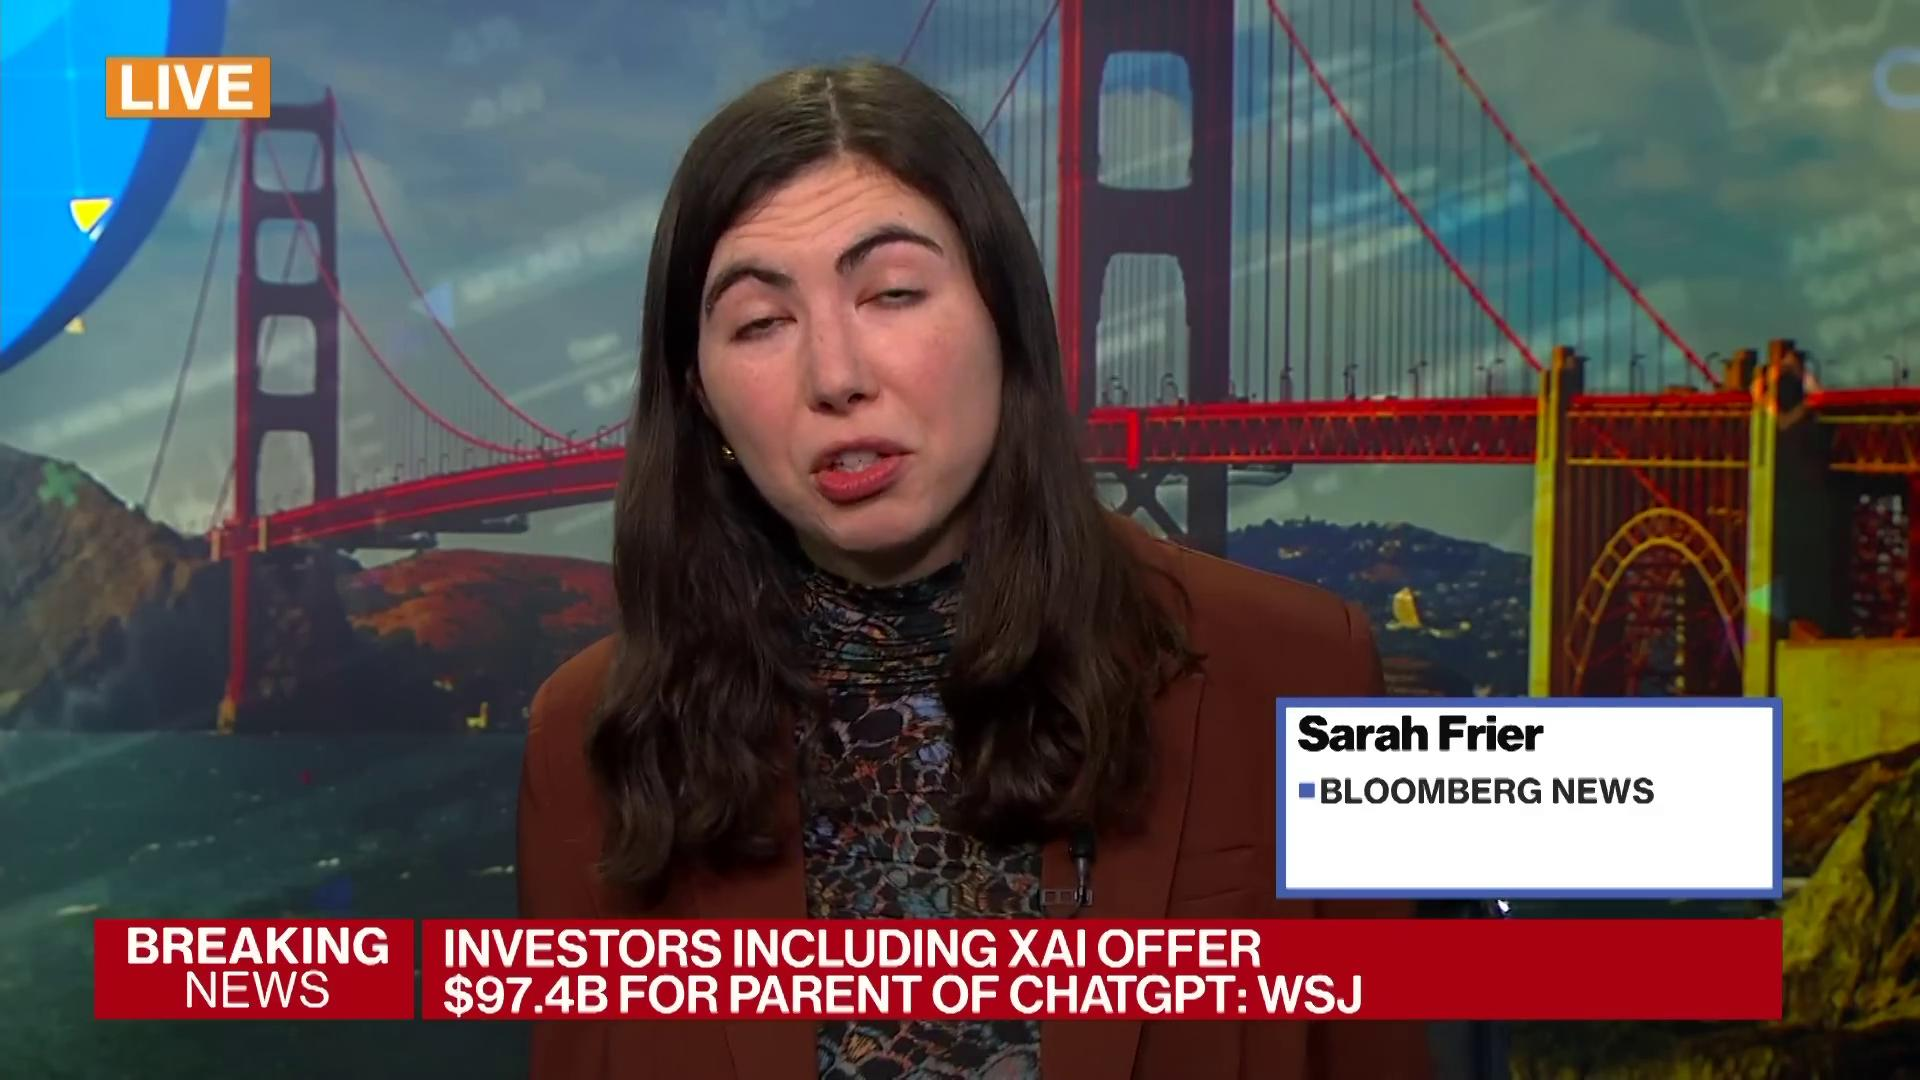

Progress: 84.0% | Frame: 39/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING ΧΑΙ OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A female reporter, Sarah Frier, is shown live on a news broadcast with a stylized background featuring the Golden Gate Bridge and some financial data overlays. She is wearing a patterned top and a brown blazer. A 'LIVE' indicator is visible in the top left corner."

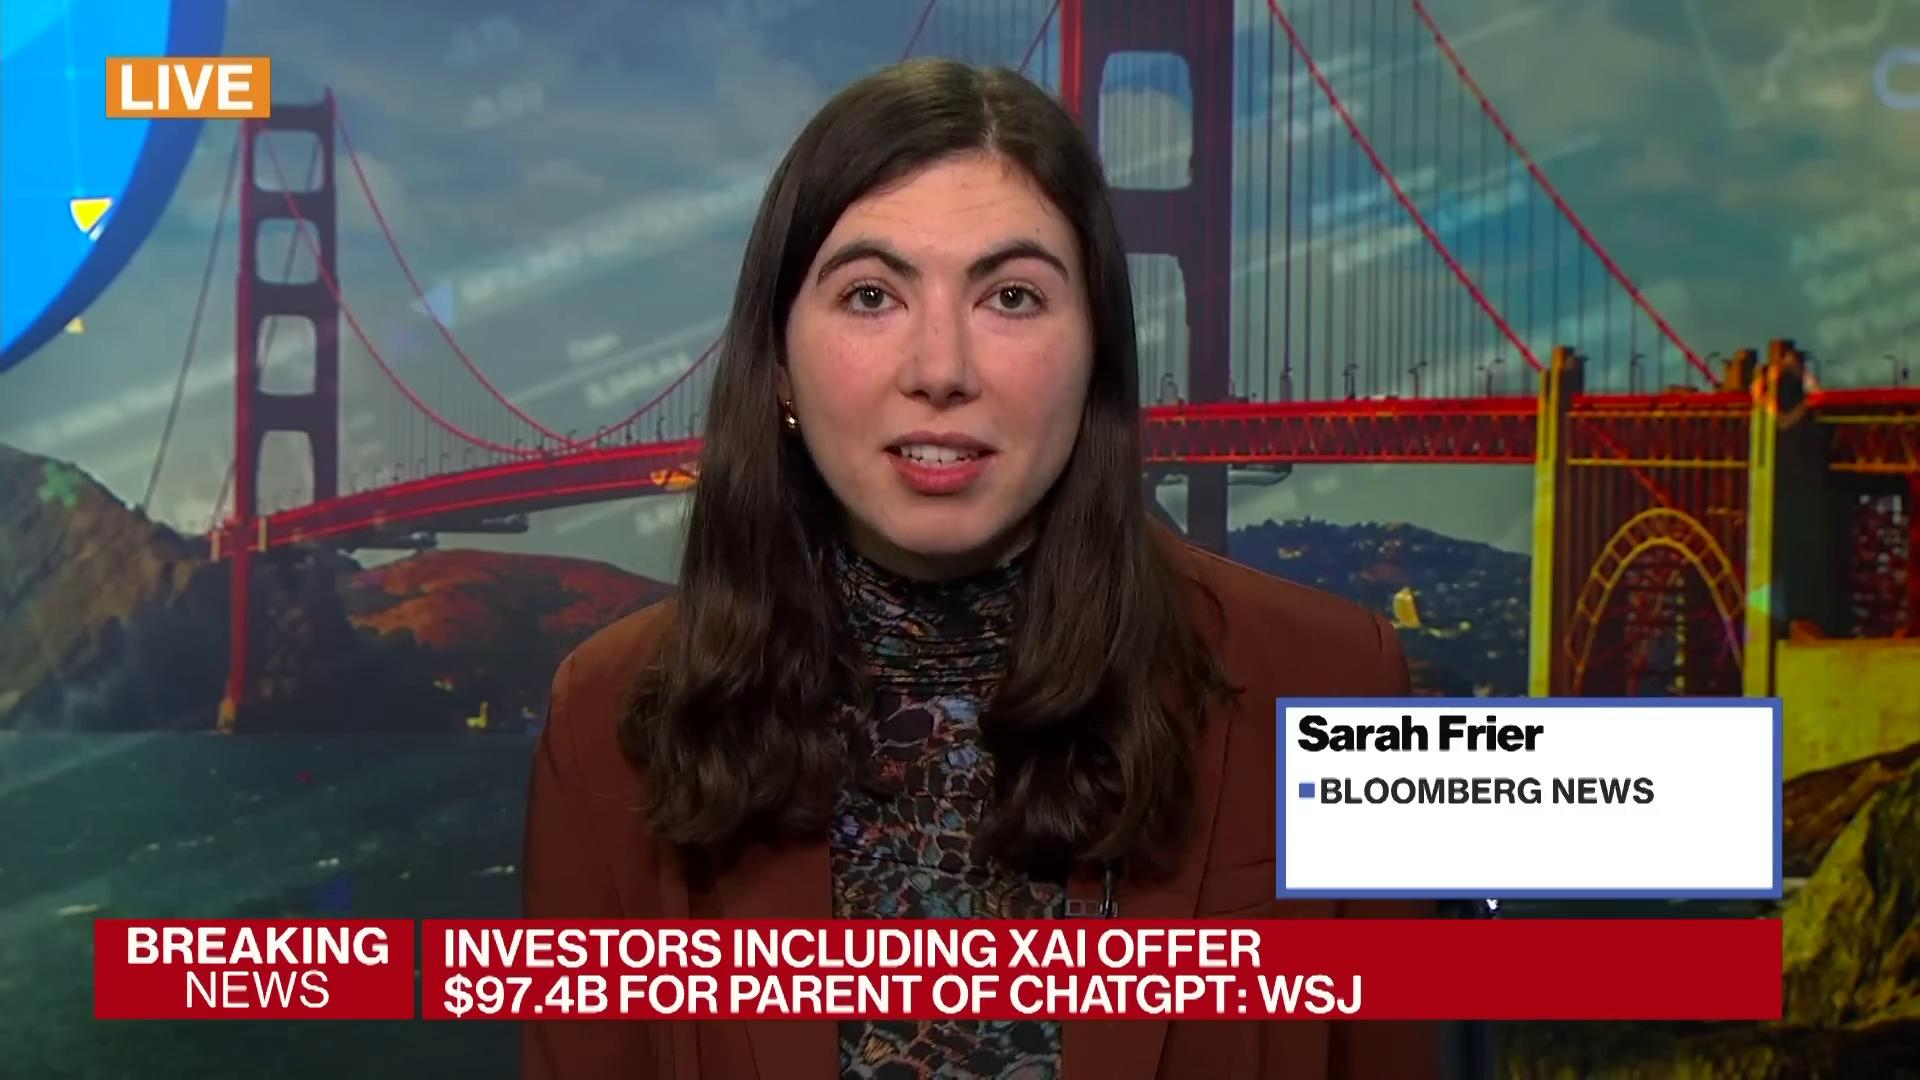

Progress: 86.2% | Frame: 40/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS: INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A female reporter, Sarah Frier, is on-screen, possibly giving a live report. She has long dark hair and is wearing a patterned top under a brown blazer. Behind her is a graphic of the Golden Gate Bridge, with some semi-transparent stock chart data overlaid. A 'LIVE' indicator is in the top left corner."

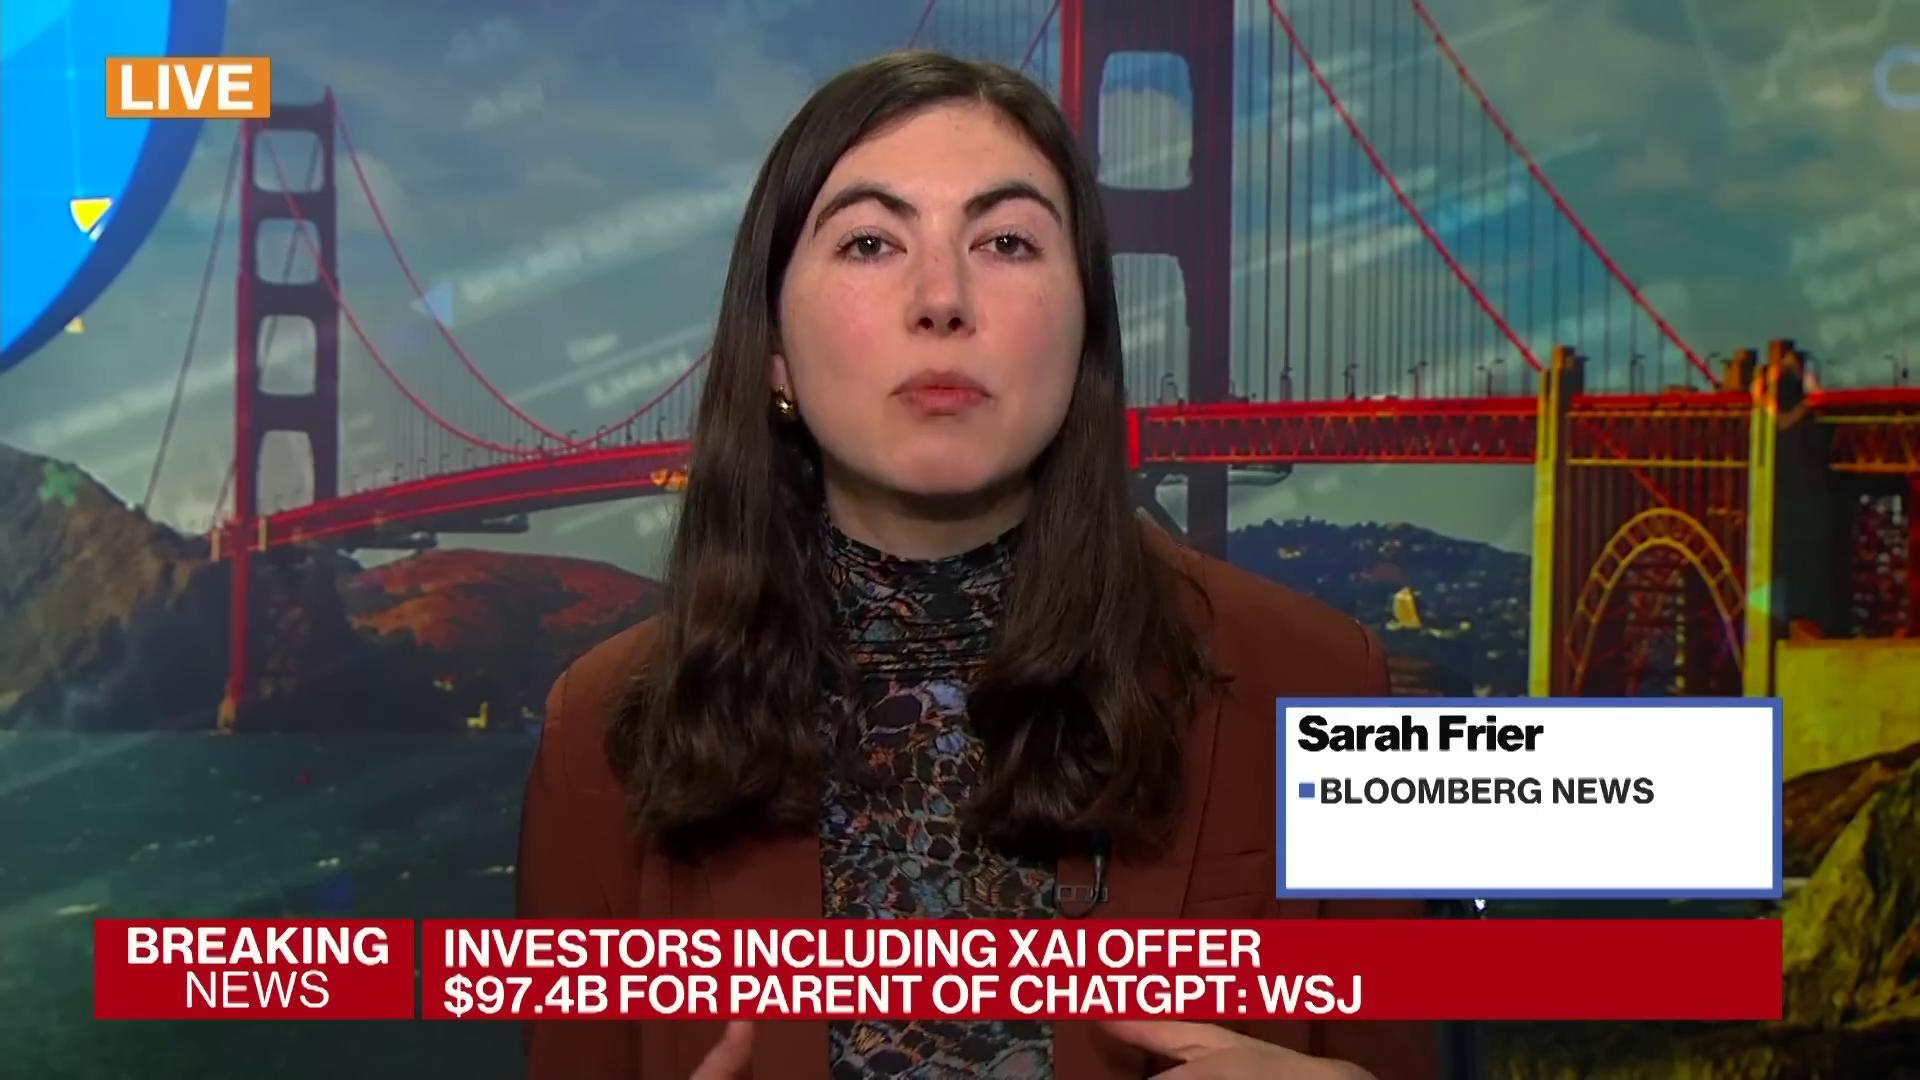

Progress: 88.4% | Frame: 41/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A woman, identified as Sarah Frier, is reporting live. She has dark hair and is wearing a patterned top under a brown jacket. The background features a digital display of the Golden Gate Bridge, with some blurred financial data or graphics visible on the screen. A 'LIVE' indicator is present in the top left corner."

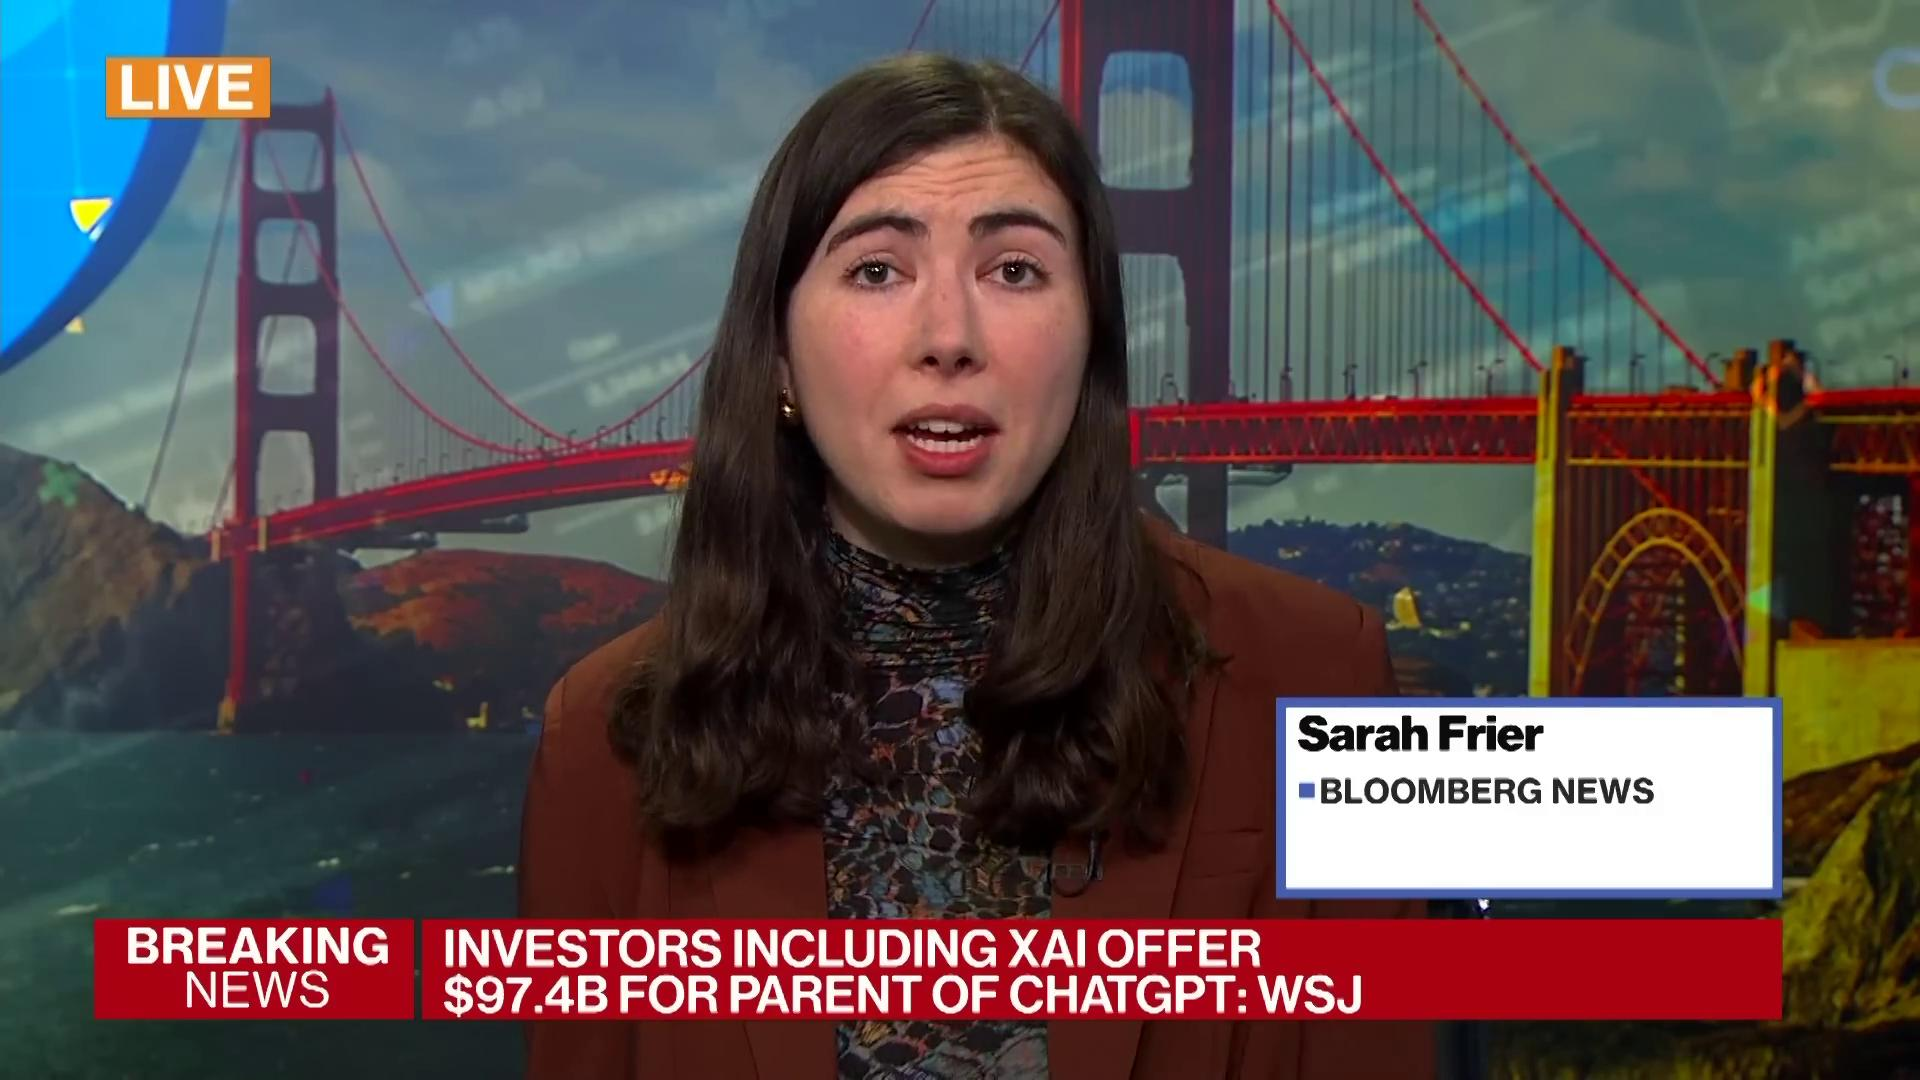

Progress: 90.6% | Frame: 42/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS INVESTORS INCLUDING XAI OFFER $97.4B FOR PARENT OF CHATGPT: WSJ
Reporters,Sarah Frier
Description,"A female reporter, Sarah Frier, is speaking on a TV news broadcast. She is positioned in front of a background graphic that features the Golden Gate Bridge. A 'LIVE' indicator is visible in the top left corner of the screen."

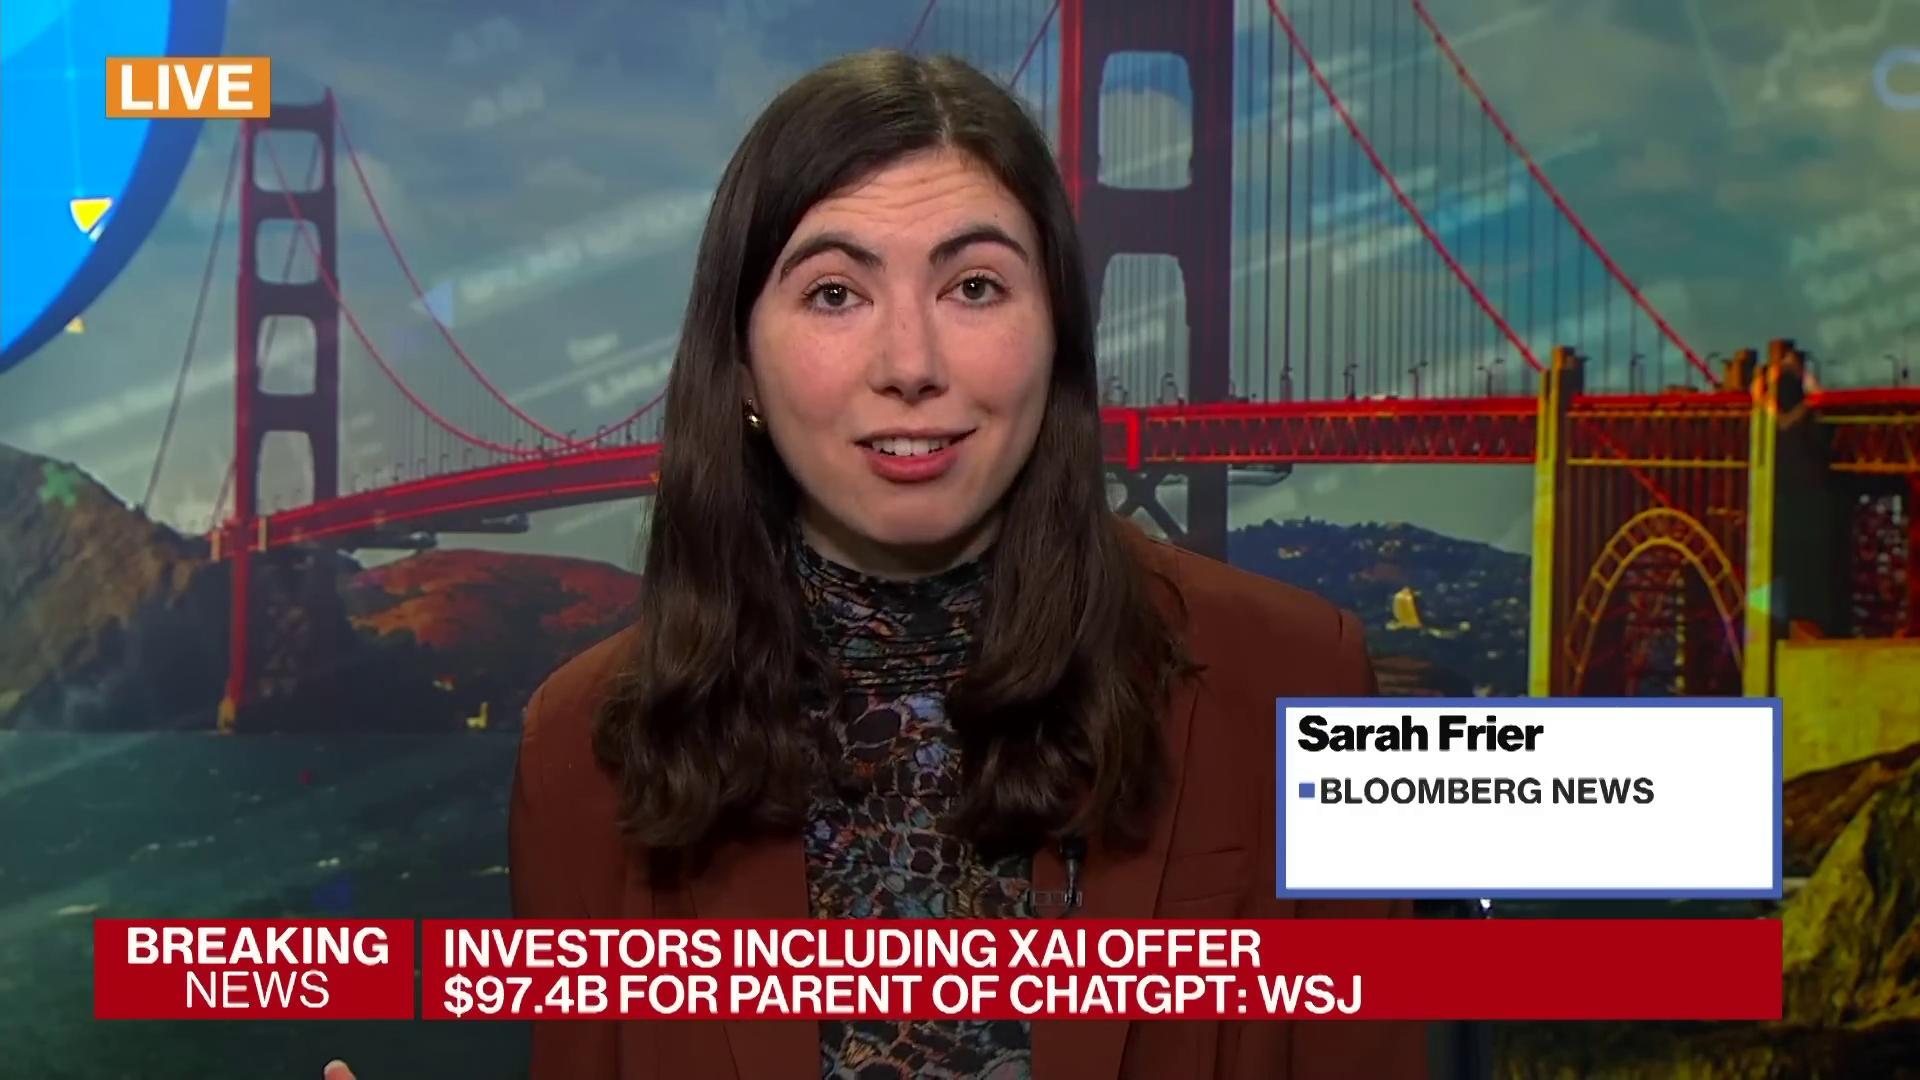

Progress: 92.8% | Frame: 43/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,Sarah Frier
Description,A live news broadcast featuring reporter Sarah Frier speaking in front of a background depicting the Golden Gate Bridge with financial data overlays.

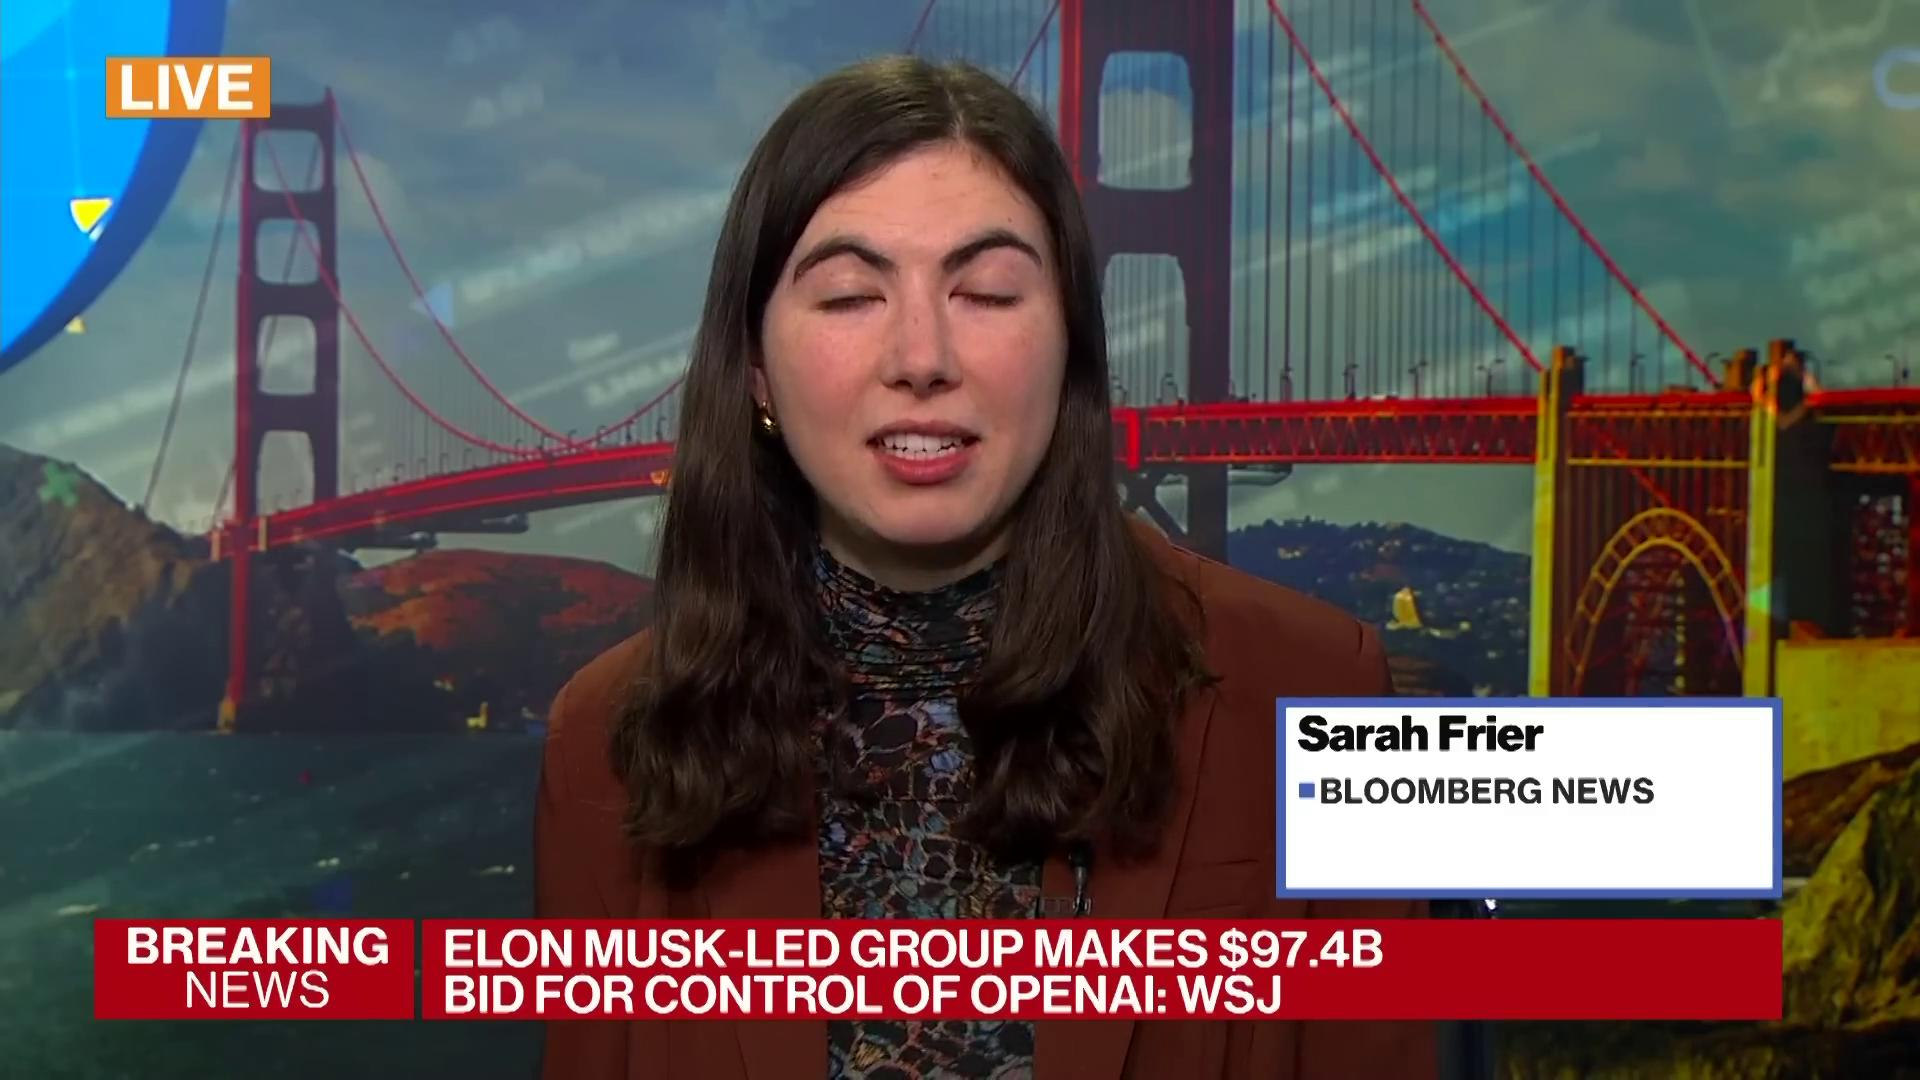

Progress: 95.1% | Frame: 44/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,Sarah Frier
Description,"A TV news segment showing a female reporter, Sarah Frier, speaking. She is in front of a digital backdrop featuring the Golden Gate Bridge and some overlayed stock market data. A 'LIVE' indicator is in the top left corner."

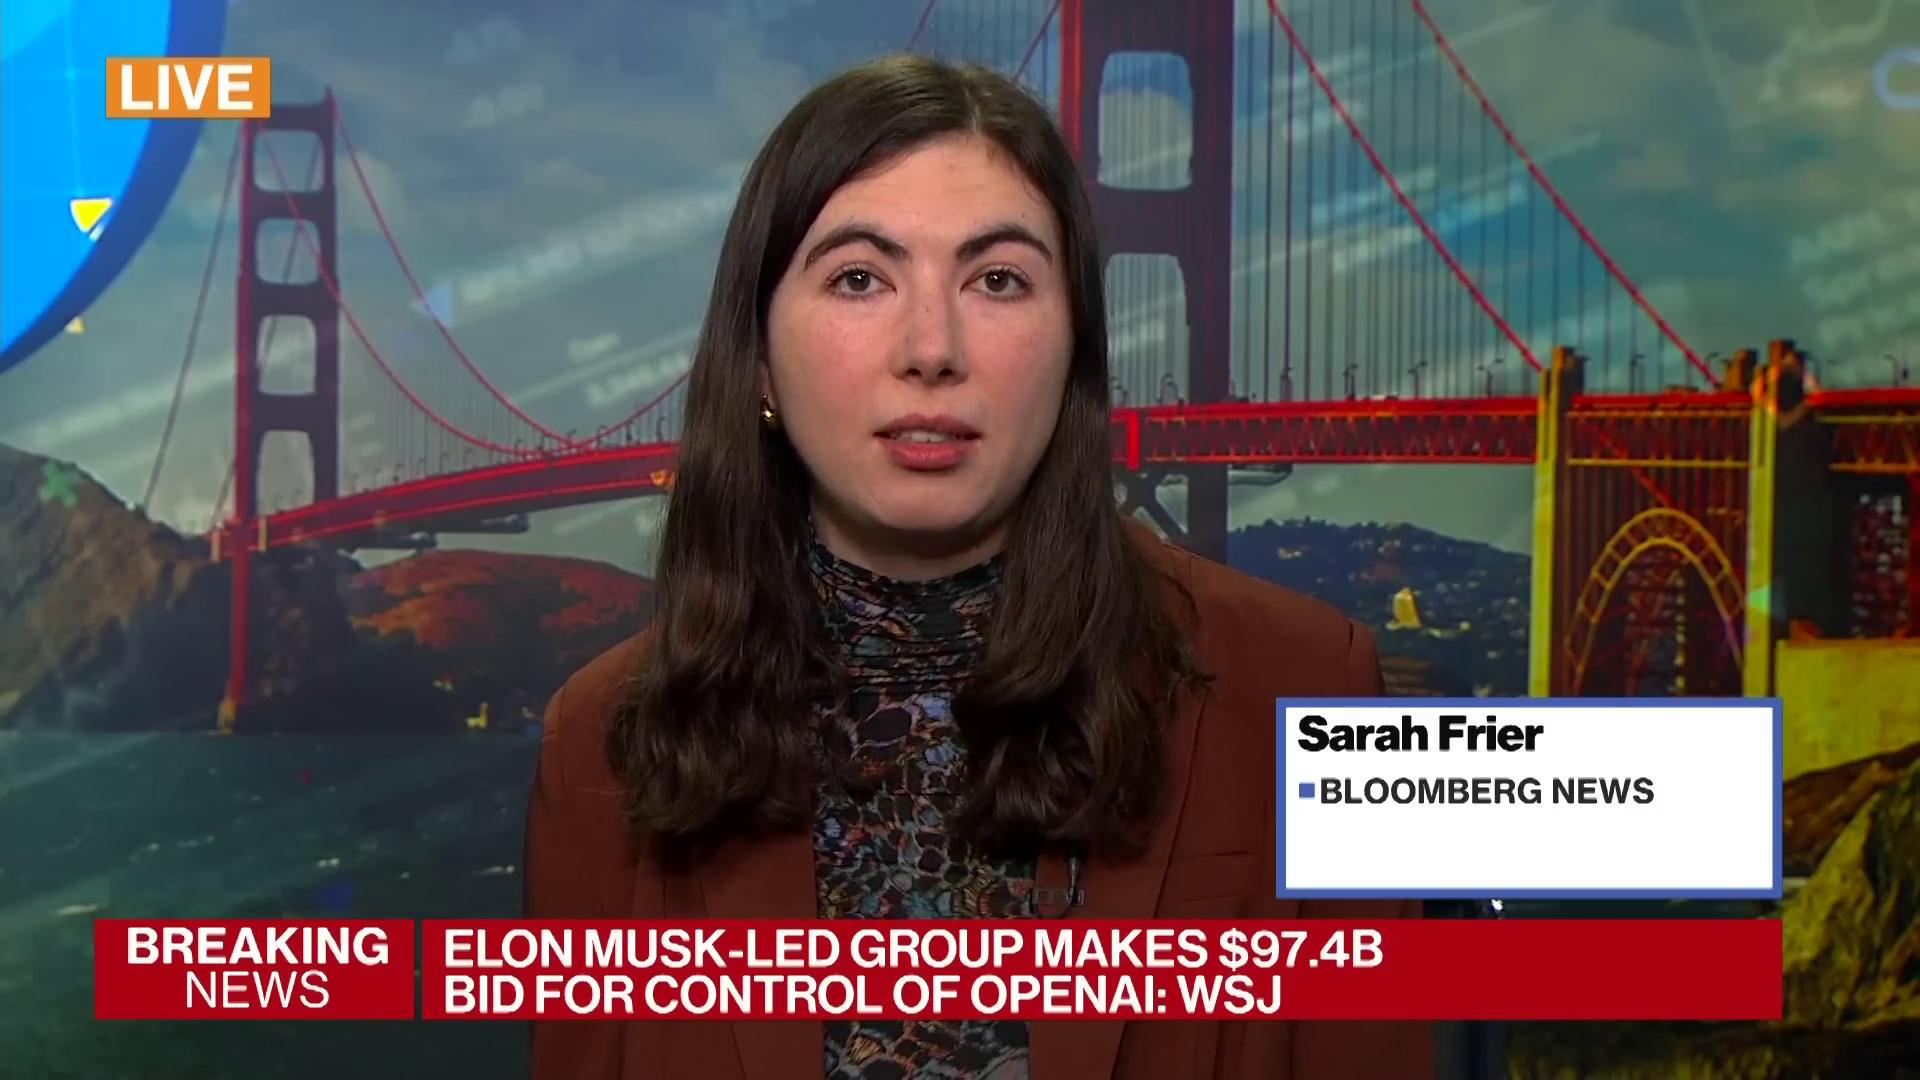

Progress: 97.3% | Frame: 45/45


Field,Content
Network,BLOOMBERG NEWS
Chyron,BREAKING NEWS ELON MUSK-LED GROUP MAKES $97.4B BID FOR CONTROL OF OPENAI: WSJ
Reporters,Sarah Frier
Description,"A TV news broadcast features reporter Sarah Frier from Bloomberg News, speaking in front of a digital backdrop depicting the Golden Gate Bridge and financial data. A 'LIVE' graphic is visible in the top left corner, and a 'BREAKING NEWS' chyron scrolls at the bottom of the screen."

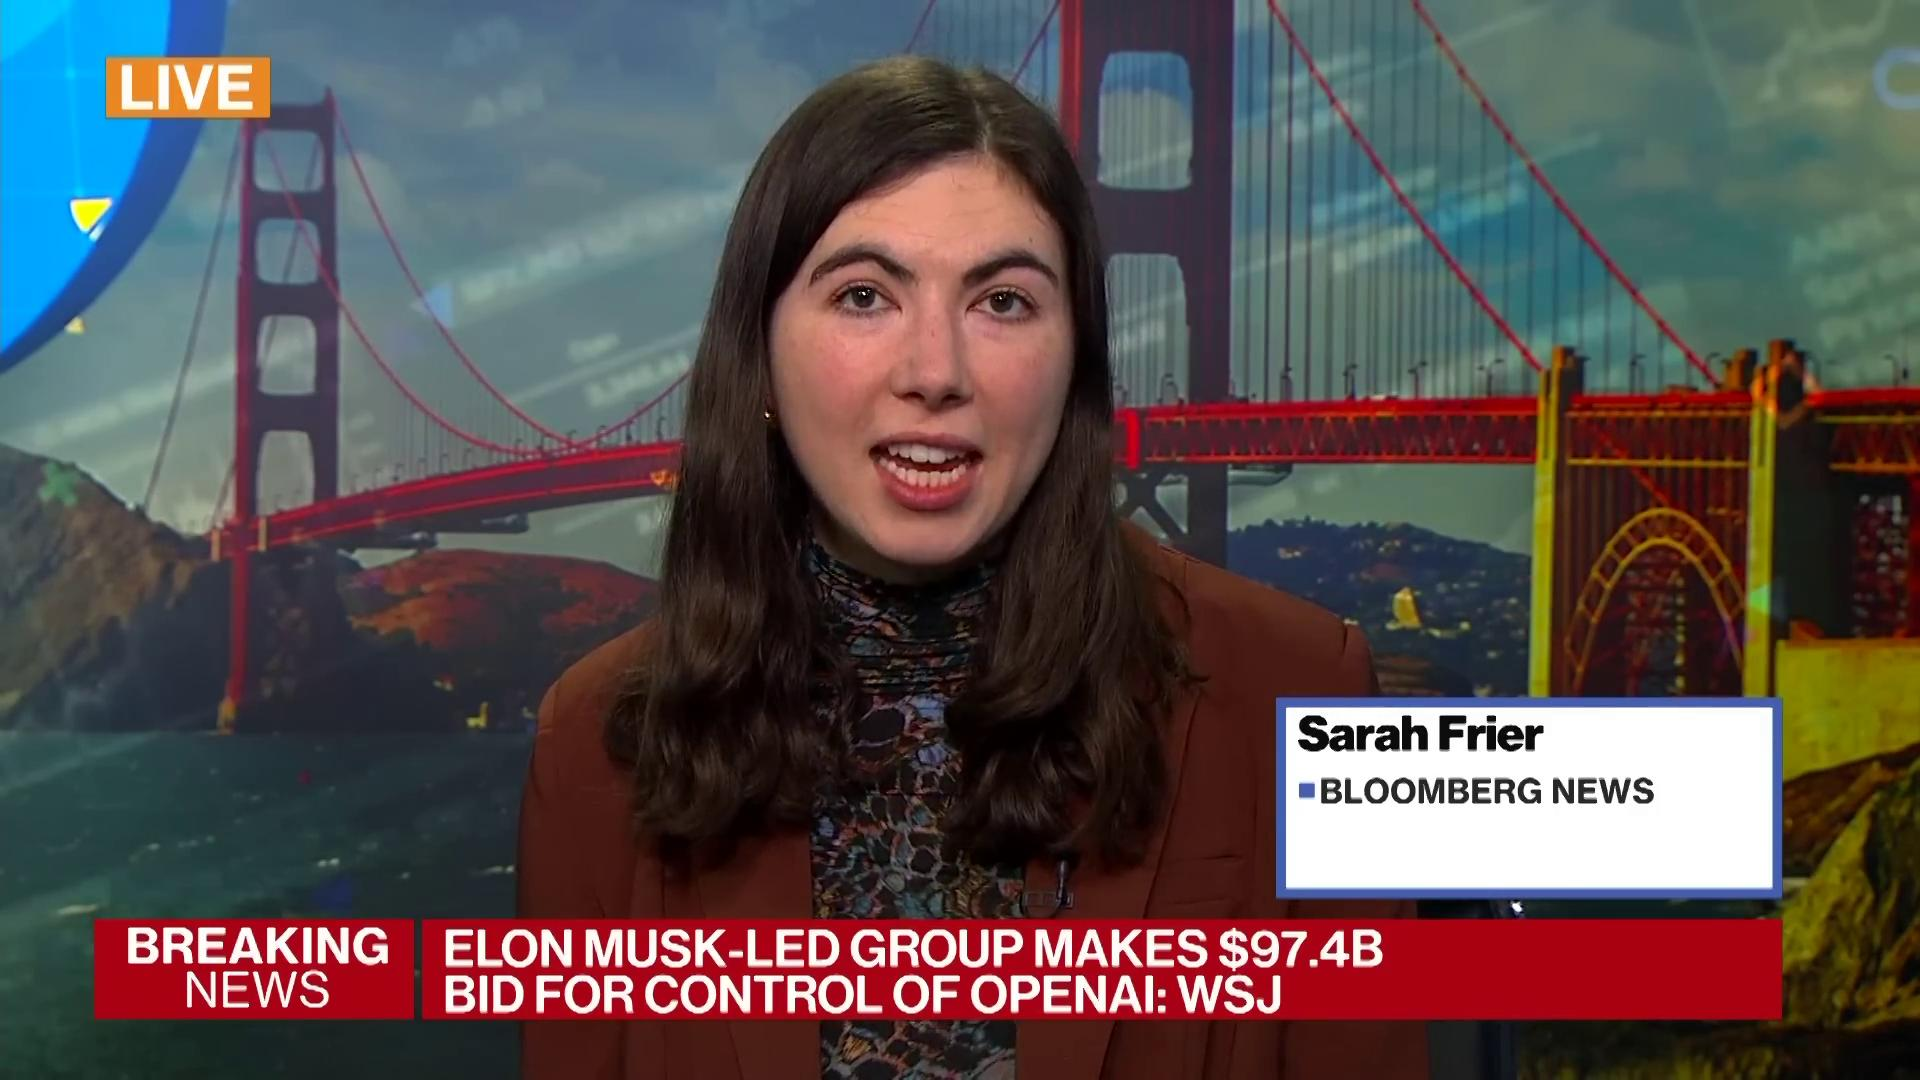

Progress: 99.5% | Frame: 46/45


In [11]:
for idx, (timestamp, frame) in enumerate(frame_generator(video_path)):
    response = vlm_client.image.generate(
        domain="media.tv-news",
        images=[frame]
    )

    if idx > 0:
        display_analysis(timestamp, frame, response.response)

## Additional Resources
- [VLM Run Documentation](https://docs.vlm.run)
- [API Reference](https://docs.vlm.run/)
- [More Examples](https://github.com/vlm-run/vlmrun-cookbook)